# Feature Insight & Transformation Analysis

For each feature: raw distribution → class separation → transformation candidates → best-transformed distribution → separability verdict.

## 0. Imports & Setup

In [41]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.preprocessing import RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

FIGURES_DIR = '../reports/figures/insight'
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
})

## 1. Load Data

In [42]:
# ── Reuse the same load + recompute_risks logic from feature_transformation.ipynb ──
import json
from risk_calculator import RiskCalculator

MERGED_DATA_PATH = '../data/merged/multi_turn_data.csv'
df_raw = pd.read_csv(MERGED_DATA_PATH)
print('Raw shape:', df_raw.shape)

def recompute_risks(df, calc):
    df = df.sort_values(['conv_id', 'turn_id']).reset_index(drop=True)
    interaction_list, pattern_list, progressive_list, prev_prog_list = [], [], [], []
    for _cid, group in df.groupby('conv_id', sort=False):
        prev = 0.0
        for _, row in group.iterrows():
            interaction = calc.compute_interaction_risk(row)
            pattern     = calc.compute_pattern_risk(row)
            prog        = calc.calculate_progressive_risk(row, prev)
            interaction_list.append(interaction)
            pattern_list.append(pattern)
            progressive_list.append(prog)
            prev_prog_list.append(prev)
            prev = prog
    df['interaction_risk'] = interaction_list
    df['pattern_risk']     = pattern_list
    df['progressive_risk'] = progressive_list
    df['prev_progressive'] = prev_prog_list
    return df

Params = {
    'alpha': np.float64(0.5555555555555556),
    'beta':  np.float64(0.22222222222222227),
    'gamma': np.float64(0.22222222222222227),
    'inter_alpha':   np.float64(0.22222222222222227),
    'inter_beta':    np.float64(0.5555555555555556),
    'inter_gamma':   np.float64(0.22222222222222227),
    'pattern_alpha': np.float64(0.16666666666666669),
    'pattern_beta':  np.float64(0.6666666666666667),
    'pattern_gamma': np.float64(0.16666666666666669),
}
calc = RiskCalculator(**Params)
df   = recompute_risks(df_raw, calc)

feature_cols = [
    'toxicity_score', 'threat_score',
    'topic_drift_score', 'cumulative_drift', 'drift_acceleration',
    'post_refusal',
    'interaction_risk', 'pattern_risk', 'progressive_risk', 'prev_progressive',
]

# Keep only labeled rows for separability analysis
df_labeled = df[df['label'] != -1].reset_index(drop=True)
print(f'Labeled turns: {len(df_labeled)}  |  malicious: {(df_labeled["label"]==1).sum()}  |  benign: {(df_labeled["label"]==0).sum()}')



Raw shape: (3251, 9)
Labeled turns: 3251  |  malicious: 897  |  benign: 2354


## 2. Quick Overview — All Features at a Glance

In [43]:
def add_smoothing_features(df):
    for col in ["toxicity_score", "threat_score", "interaction_risk", "pattern_risk"]:

        df[f"{col}_ema3"] = (
            df.groupby("conv_id")[col]
            .transform(lambda x: x.ewm(span=3, adjust=False).mean())
        )

        df[f"{col}_rolling3_mean"] = (
            df.groupby("conv_id")[col]
            .transform(lambda x: x.rolling(3, min_periods=1).mean())
        )

        df[f"{col}_rolling3_max"] = (
            df.groupby("conv_id")[col]
            .transform(lambda x: x.rolling(3, min_periods=1).max())
        )

    return df

In [44]:
def add_refusal_context(df):

    g = df.groupby("conv_id")

    df["refusal_seen_so_far"] = g["post_refusal"].cumsum()
    df["after_refusal_flag"] = df["refusal_seen_so_far"] > 0

    return df

In [45]:
def add_escalation_features(df):

    df["toxicity_diff"] = df.groupby("conv_id")["toxicity_score"].diff().fillna(0)
    df["threat_diff"] = df.groupby("conv_id")["threat_score"].diff().fillna(0)

    df["toxicity_accel"] = df.groupby("conv_id")["toxicity_diff"].diff().fillna(0)

    df["risk_slope_3"] = (
        df.groupby("conv_id")["interaction_risk"]
        .transform(lambda x: x.diff().rolling(3, min_periods=1).mean())
        .fillna(0)
    )

    return df

In [46]:
def add_context_features(df):

    g = df.groupby("conv_id")

    df["max_toxicity_so_far"] = g["toxicity_score"].cummax()
    df["max_threat_so_far"] = g["threat_score"].cummax()

    df["mean_risk_so_far"] = (
        g["interaction_risk"]
        .expanding()
        .mean()
        .reset_index(level=0, drop=True)
    )

    return df

In [47]:
def add_shape_features(df):

    g = df.groupby("conv_id")

    df["early_high_risk"] = (
        g["interaction_risk"]
        .transform(lambda x: x.head(3).max())
    )

    df["late_risk_increase"] = (
        g["interaction_risk"]
        .transform(lambda x: x.tail(3).mean())
    )

    df["risk_growth_ratio"] = (
        df["late_risk_increase"] /
        (df["early_high_risk"] + 1e-6)
    )

    return df

In [48]:
def build_features(df):

    df = df.sort_values(["conv_id", "turn_id"])

    df = add_smoothing_features(df)
    df = add_escalation_features(df)
    df = add_context_features(df)
    df = add_shape_features(df)
    df = add_refusal_context(df)

    return df

In [49]:
df_labeled= build_features(df_labeled)

y = df_labeled['label'].values
X = df_labeled.drop(columns=['conv_id', 'turn_id', 'label'])

In [50]:
X


,toxicity_score,threat_score,topic_drift_score,cumulative_drift,drift_acceleration,post_refusal,interaction_risk,pattern_risk,progressive_risk,prev_progressive,...,toxicity_accel,risk_slope_3,max_toxicity_so_far,max_threat_so_far,mean_risk_so_far,early_high_risk,late_risk_increase,risk_growth_ratio,refusal_seen_so_far,after_refusal_flag
0,0.024668,0.001102,0.0000,0.0000,0.0000,1.0,0.236172,0.000000,0.0525,0.0000,...,0.000000,0.000000,0.024668,0.001102,0.236172,0.242913,0.239542,0.986119,1.0,True
1,0.036629,0.001537,0.2665,0.2665,0.0000,1.0,0.242913,0.222083,0.1325,0.0525,...,0.011961,0.006742,0.036629,0.001537,0.239542,0.242913,0.239542,0.986119,2.0,True
2,0.031880,0.000943,0.0000,0.0000,0.0000,1.0,0.240143,0.000000,0.0534,0.0000,...,0.000000,0.000000,0.031880,0.000943,0.240143,0.254450,0.247296,0.971883,1.0,True
3,0.057176,0.002084,0.2815,0.2815,0.0000,1.0,0.254450,0.234583,0.1383,0.0534,...,0.025296,0.014307,0.057176,0.002084,0.247296,0.254450,0.247296,0.971883,2.0,True
4,0.002470,0.000771,0.0000,0.0000,0.0000,0.0,0.001544,0.000000,0.0003,0.0000,...,0.000000,0.000000,0.002470,0.000771,0.001544,0.001544,0.001544,0.999353,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,0.009304,0.005603,0.9163,0.8539,0.2674,0.0,0.006414,0.766550,0.3236,0.2733,...,0.014659,-0.072055,0.009304,0.005603,0.169304,0.225713,0.151103,0.669446,3.0,True
3247,0.003581,0.000793,0.7268,0.8407,-0.1895,1.0,0.224388,0.650017,0.3741,0.3236,...,-0.014767,-0.000442,0.009304,0.005603,0.180321,0.225713,0.151103,0.669446,4.0,True
3248,0.016572,0.000612,0.0000,0.0000,0.0000,0.0,0.009343,0.000000,0.0021,0.0000,...,0.000000,0.000000,0.016572,0.000612,0.009343,0.009343,0.009343,0.999893,0.0,False
3249,0.007752,0.000702,0.0000,0.0000,0.0000,0.0,0.004462,0.000000,0.0010,0.0000,...,0.000000,0.000000,0.007752,0.000702,0.004462,0.004462,0.004462,0.999776,0.0,False


In [51]:
# Stats table: mean/std/skew/kurtosis/% zeros per class
rows = []
for col in X.columns:
    ben = X.loc[y==0, col]
    mal = X.loc[y==1, col]
    stat, p = mannwhitneyu(ben, mal, alternative='two-sided')
    auc = roc_auc_score(y, X[col])   # raw AUC (no scaling)
    auc = max(auc, 1-auc)            # flip if < 0.5
    rows.append({
        'feature'      : col,
        'mean_benign'  : round(ben.mean(), 4),
        'mean_malicious': round(mal.mean(), 4),
        'std_benign'   : round(ben.std(), 4),
        'std_malicious': round(mal.std(), 4),
        'skewness'     : round(X[col].skew(), 3),
        'zeros_%'      : round((X[col]==0).mean()*100, 1),
        'MWU_p'        : round(p, 5),
        'AUC'          : round(auc, 4),
    })

overview = pd.DataFrame(rows).set_index('feature')
print(overview.to_string())

                                mean_benign  mean_malicious  std_benign  std_malicious  skewness  zeros_%    MWU_p     AUC
feature                                                                                                                   
toxicity_score                       0.0193          0.0483      0.0461         0.0827     8.096      0.0  0.00000  0.7420
threat_score                         0.0031          0.0225      0.0257         0.1126    11.697      0.0  0.00000  0.7224
topic_drift_score                    0.2416          0.2238      0.2272         0.2002     0.587     34.0  0.14758  0.5161
cumulative_drift                     0.3065          0.2899      0.2787         0.2516     0.390     34.0  0.17667  0.5150
drift_acceleration                  -0.0101         -0.0201      0.1207         0.1219    -0.758     60.5  0.03301  0.5213
post_refusal                         0.2600          0.1873      0.4387         0.3904     1.219     76.0  0.00001  0.5363
interaction_risk

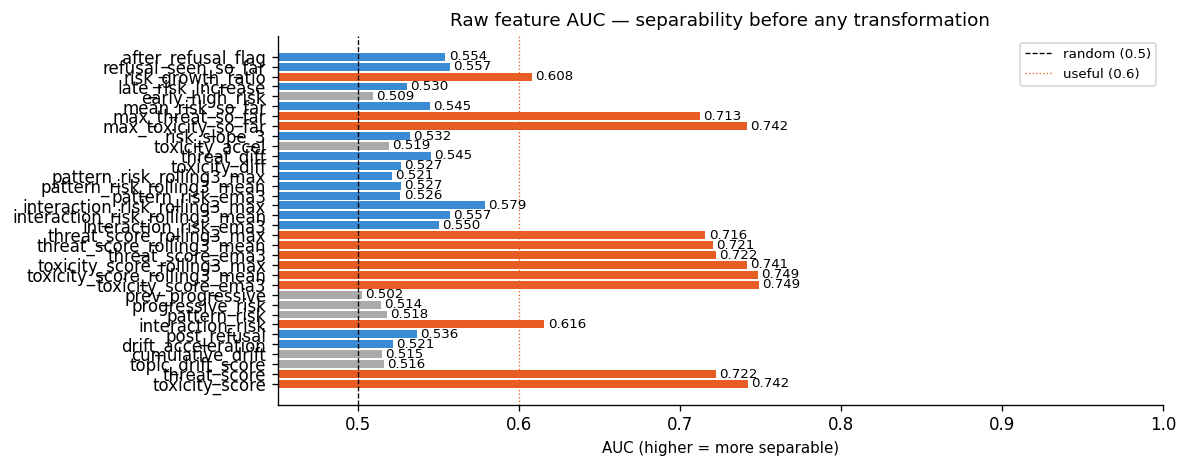


Features sorted by AUC:
feature
toxicity_score_ema3               0.7490
toxicity_score_rolling3_mean      0.7485
toxicity_score                    0.7420
max_toxicity_so_far               0.7415
toxicity_score_rolling3_max       0.7413
threat_score                      0.7224
threat_score_ema3                 0.7223
threat_score_rolling3_mean        0.7206
threat_score_rolling3_max         0.7158
max_threat_so_far                 0.7126
interaction_risk                  0.6157
risk_growth_ratio                 0.6078
interaction_risk_rolling3_max     0.5790
interaction_risk_rolling3_mean    0.5572
refusal_seen_so_far               0.5568
after_refusal_flag                0.5542
interaction_risk_ema3             0.5499
threat_diff                       0.5451
mean_risk_so_far                  0.5448
post_refusal                      0.5363
risk_slope_3                      0.5321
late_risk_increase                0.5303
pattern_risk_rolling3_mean        0.5268
toxicity_diff           

In [52]:
# Bar chart: AUC per feature (quick separability overview)
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#E85D24' if v >= 0.6 else '#3B8BD4' if v >= 0.52 else '#aaa'
          for v in overview['AUC']]
bars = ax.barh(overview.index, overview['AUC'], color=colors)
ax.axvline(0.5, color='black', lw=0.8, ls='--', label='random (0.5)')
ax.axvline(0.6, color='#E85D24', lw=0.8, ls=':', label='useful (0.6)')
for bar, v in zip(bars, overview['AUC']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)
ax.set_xlim(0.45, 1.0)
ax.set_xlabel('AUC (higher = more separable)')
ax.set_title('Raw feature AUC — separability before any transformation')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/00_feature_auc_overview.png', bbox_inches='tight')
plt.show()
print('\nFeatures sorted by AUC:')
print(overview['AUC'].sort_values(ascending=False).to_string())

## 3. Per-Feature Deep Dive

For each feature: scatter by label · histogram by class · box plot · KDE overlay · skewness diagnosis · transformation candidates · best transform verdict.

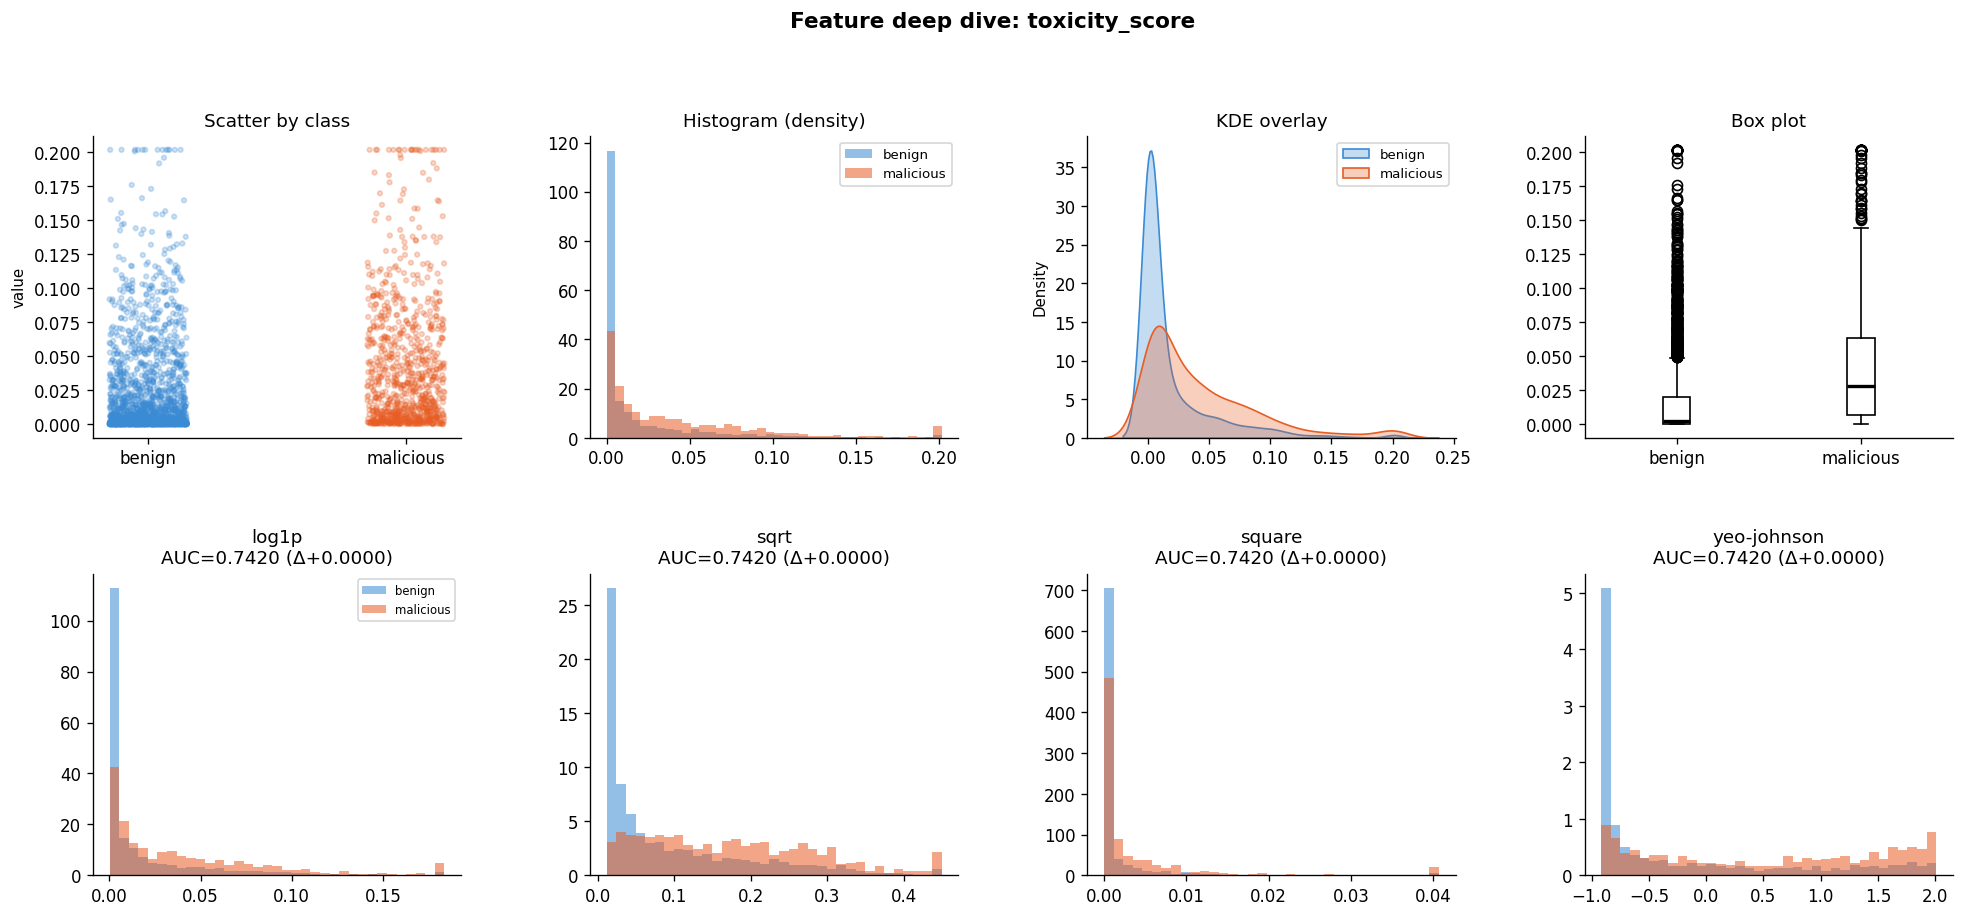

FEATURE: toxicity_score
  Raw AUC         : 0.7420
  Skewness        : 8.096  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3857 / 0.00000
  Mean benign     : 0.0193   malicious: 0.0483
  Best transform  : log1p  →  AUC=0.7420  KS=0.3857
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7420  Δ=+0.0000  KS=0.3857
    sqrt            AUC=0.7420  Δ=+0.0000  KS=0.3857
    square          AUC=0.7420  Δ=+0.0000  KS=0.3857
    yeo-johnson     AUC=0.7420  Δ=+0.0000  KS=0.3857
    quantile        AUC=0.7420  Δ=+0.0000  KS=0.3857
    rank            AUC=0.7420  Δ=+0.0000  KS=0.3857
    binarize        AUC=0.5000  Δ=-0.2420  KS=0.0000


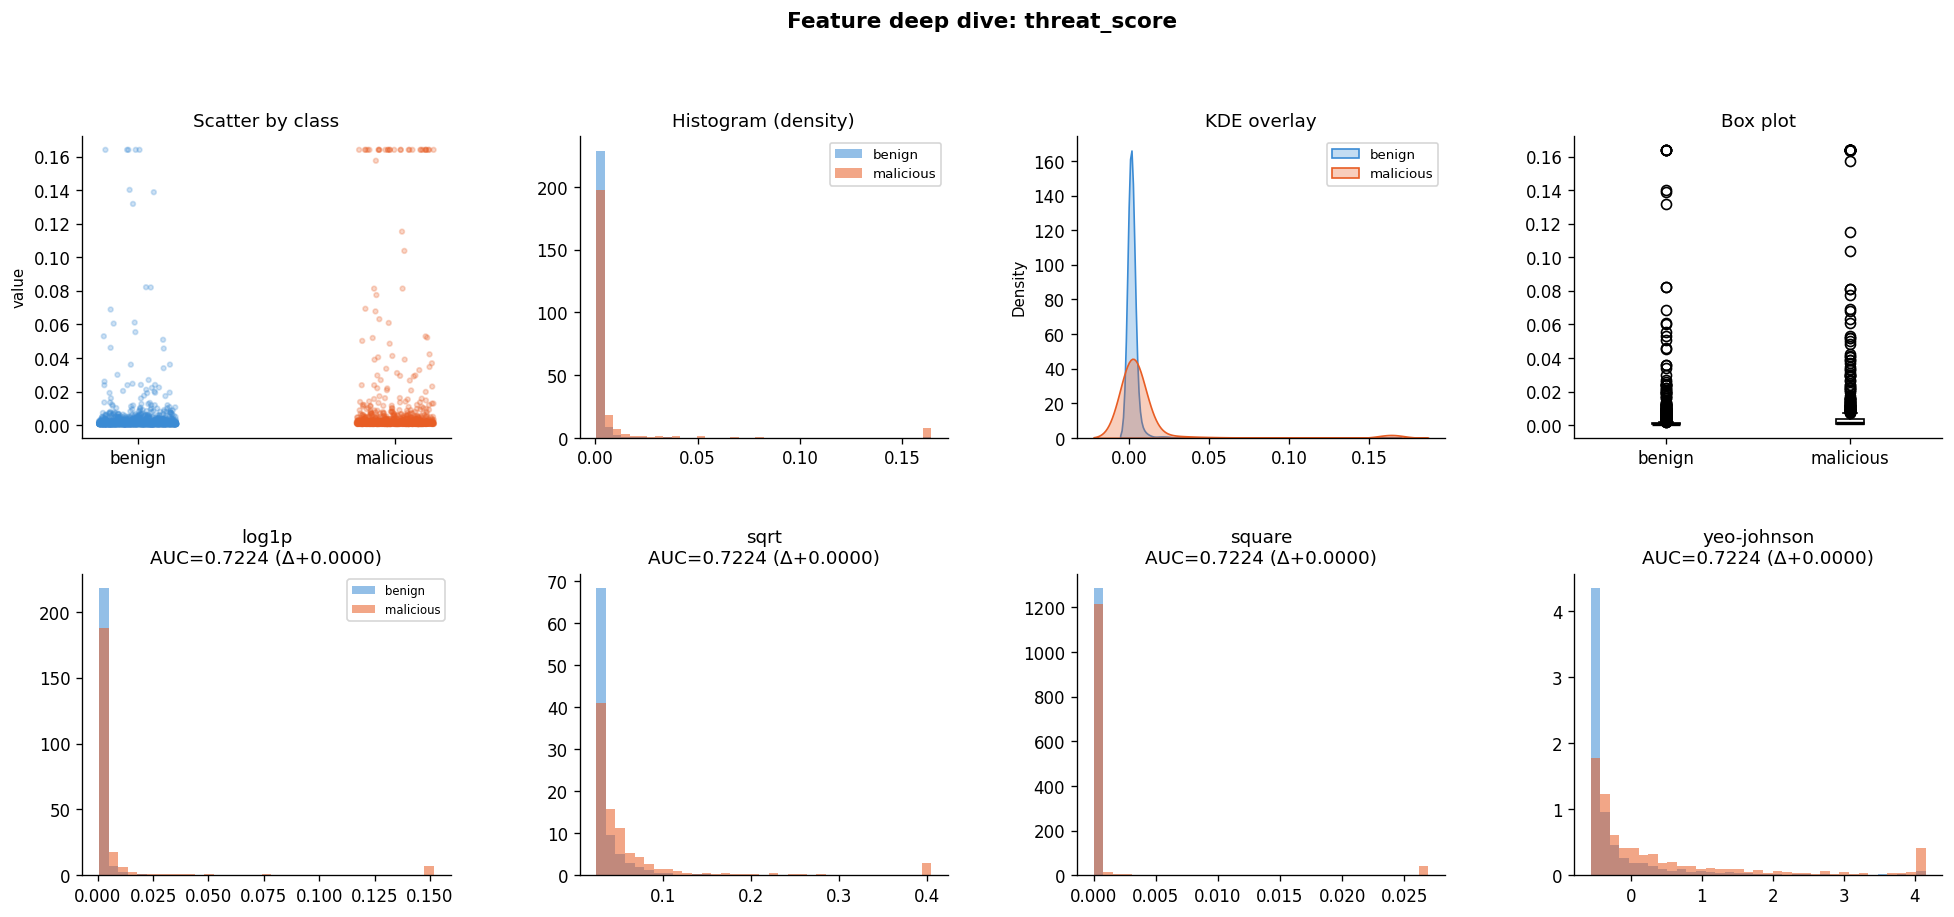

FEATURE: threat_score
  Raw AUC         : 0.7224
  Skewness        : 11.697  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3519 / 0.00000
  Mean benign     : 0.0031   malicious: 0.0225
  Best transform  : log1p  →  AUC=0.7224  KS=0.3519
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7224  Δ=+0.0000  KS=0.3519
    sqrt            AUC=0.7224  Δ=+0.0000  KS=0.3519
    square          AUC=0.7224  Δ=+0.0000  KS=0.3519
    yeo-johnson     AUC=0.7224  Δ=+0.0000  KS=0.3519
    quantile        AUC=0.7224  Δ=+0.0000  KS=0.3519
    rank            AUC=0.7224  Δ=+0.0000  KS=0.3519
    binarize        AUC=0.5000  Δ=-0.2224  KS=0.0000


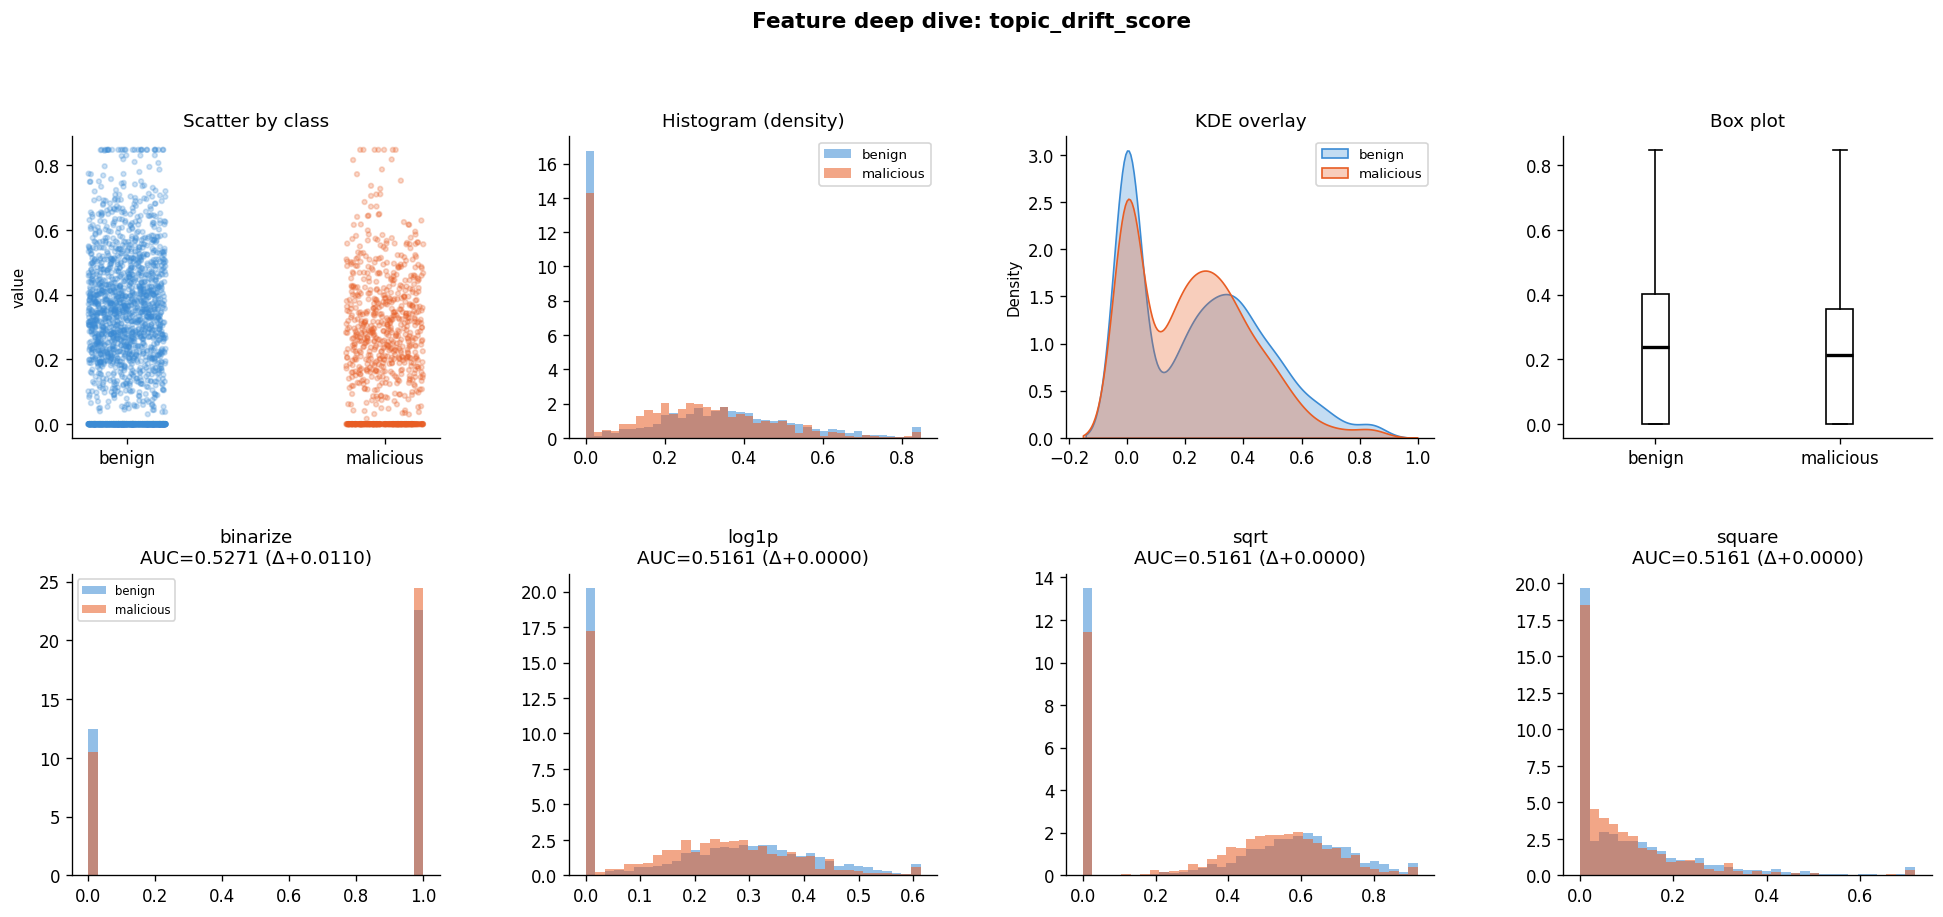

FEATURE: topic_drift_score
  Raw AUC         : 0.5161
  Skewness        : 0.587  (moderate)
  Zeros           : 34.0%
  KS stat / p     : 0.0793 / 0.00052
  Mean benign     : 0.2416   malicious: 0.2238
  Best transform  : binarize  →  AUC=0.5271  KS=0.0541
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5271  Δ=+0.0110  KS=0.0541
    log1p           AUC=0.5161  Δ=+0.0000  KS=0.0793
    sqrt            AUC=0.5161  Δ=+0.0000  KS=0.0793
    square          AUC=0.5161  Δ=+0.0000  KS=0.0793
    yeo-johnson     AUC=0.5161  Δ=+0.0000  KS=0.0793
    quantile        AUC=0.5161  Δ=+0.0000  KS=0.0793
    rank            AUC=0.5161  Δ=+0.0000  KS=0.0793


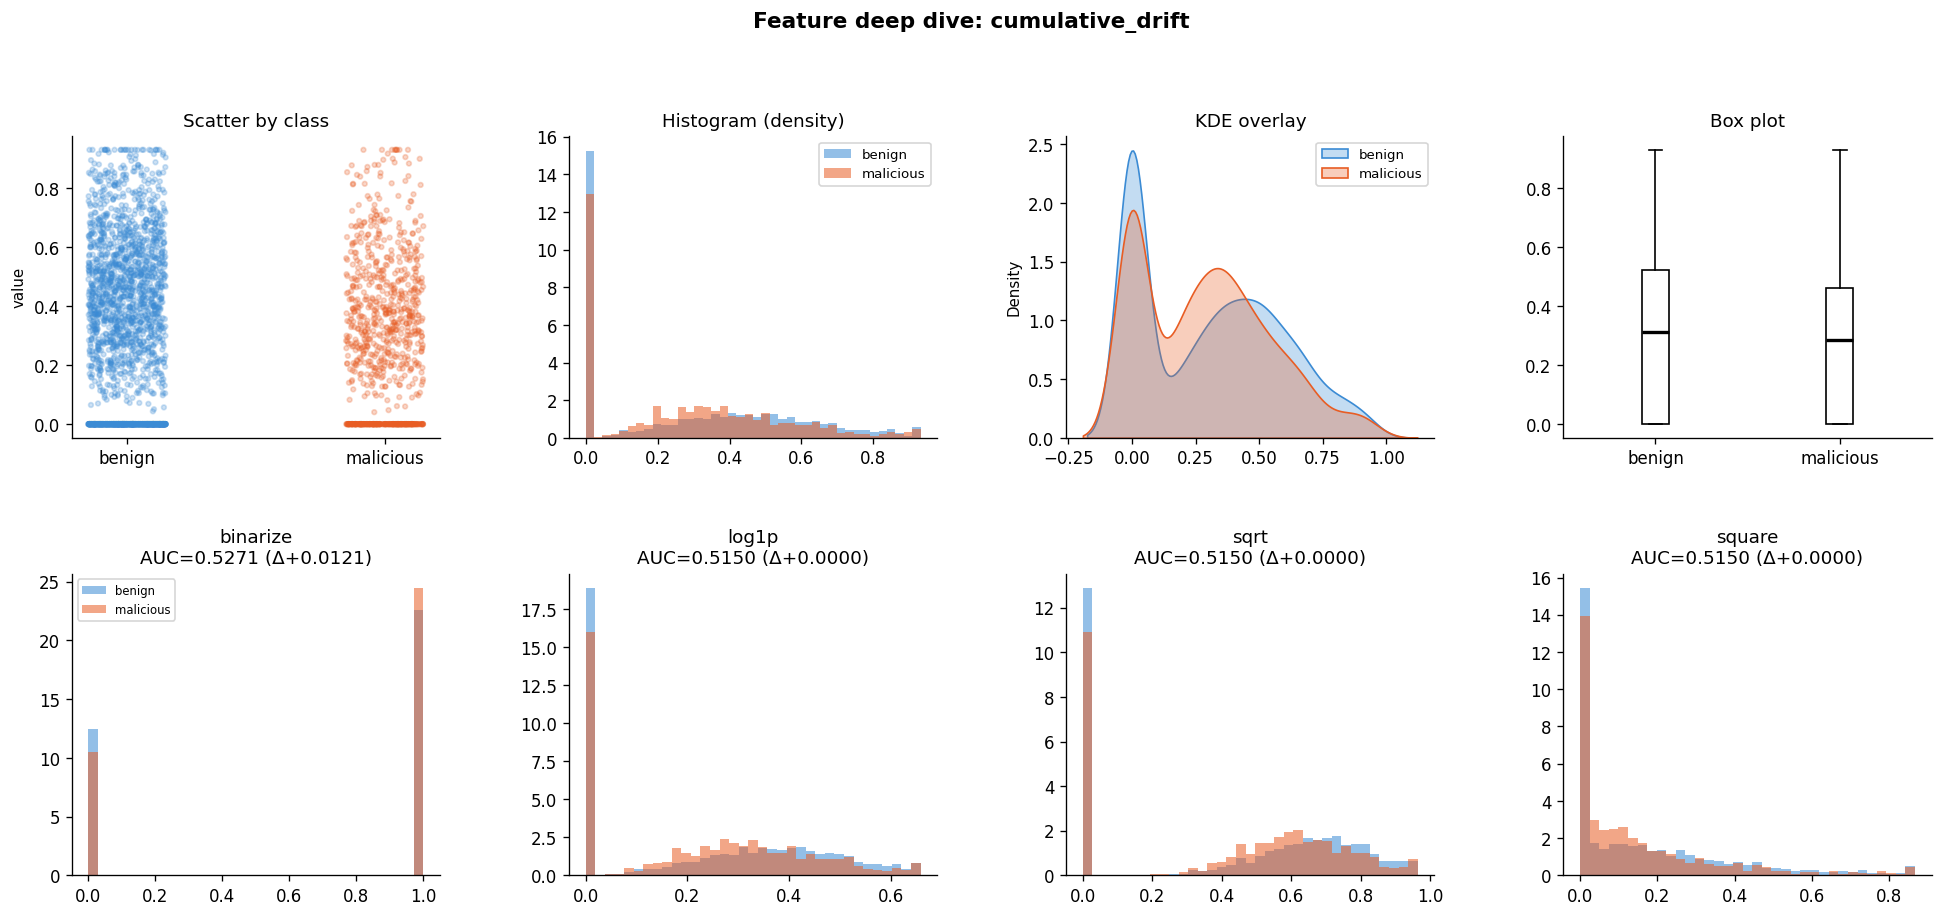

FEATURE: cumulative_drift
  Raw AUC         : 0.5150
  Skewness        : 0.39  (low)
  Zeros           : 34.0%
  KS stat / p     : 0.0823 / 0.00028
  Mean benign     : 0.3065   malicious: 0.2899
  Best transform  : binarize  →  AUC=0.5271  KS=0.0541
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5271  Δ=+0.0121  KS=0.0541
    log1p           AUC=0.5150  Δ=+0.0000  KS=0.0823
    sqrt            AUC=0.5150  Δ=+0.0000  KS=0.0823
    square          AUC=0.5150  Δ=+0.0000  KS=0.0823
    yeo-johnson     AUC=0.5150  Δ=+0.0000  KS=0.0823
    quantile        AUC=0.5150  Δ=+0.0000  KS=0.0823
    rank            AUC=0.5150  Δ=+0.0000  KS=0.0823


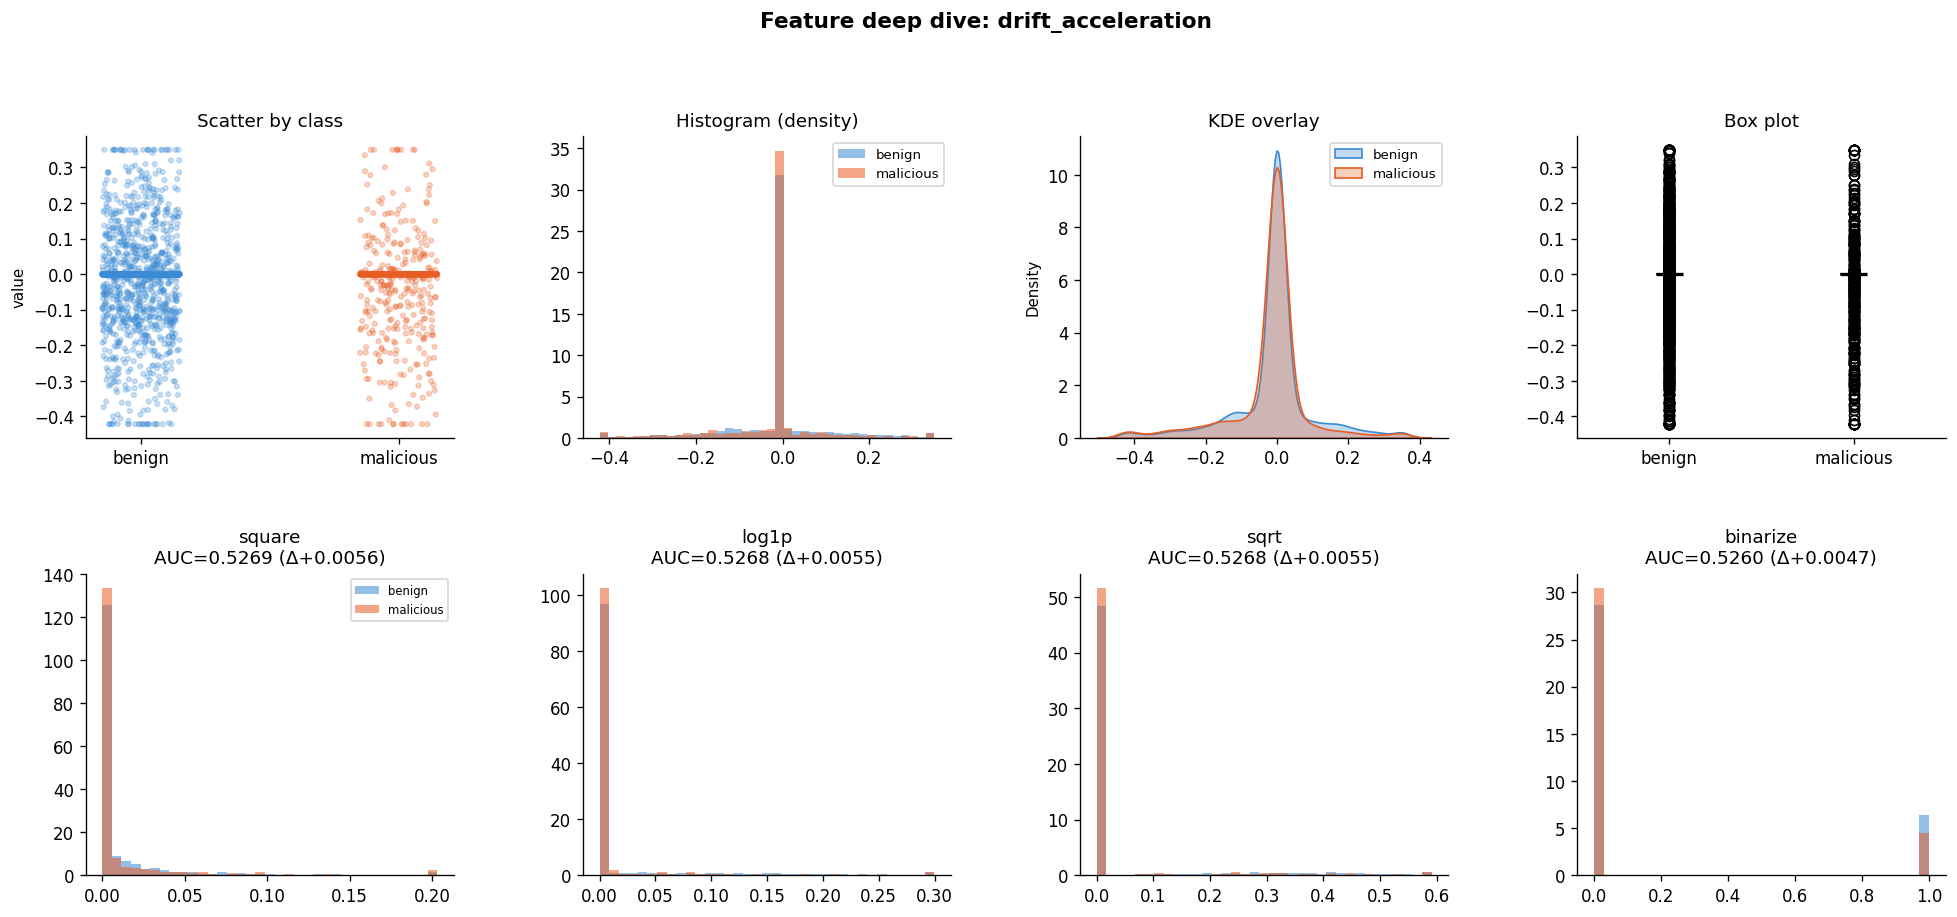

FEATURE: drift_acceleration
  Raw AUC         : 0.5213
  Skewness        : -0.758  (moderate)
  Zeros           : 60.5%
  KS stat / p     : 0.0589 / 0.02096
  Mean benign     : -0.0101   malicious: -0.0201
  Best transform  : square  →  AUC=0.5269  KS=0.0676
  Verdict         : WEAK
  All transforms (sorted by AUC):
    square          AUC=0.5269  Δ=+0.0056  KS=0.0676
    log1p           AUC=0.5268  Δ=+0.0055  KS=0.0589
    sqrt            AUC=0.5268  Δ=+0.0055  KS=0.0589
    binarize        AUC=0.5260  Δ=+0.0047  KS=0.0521
    yeo-johnson     AUC=0.5213  Δ=+0.0000  KS=0.0589
    quantile        AUC=0.5213  Δ=+0.0000  KS=0.0589
    rank            AUC=0.5213  Δ=+0.0000  KS=0.0589


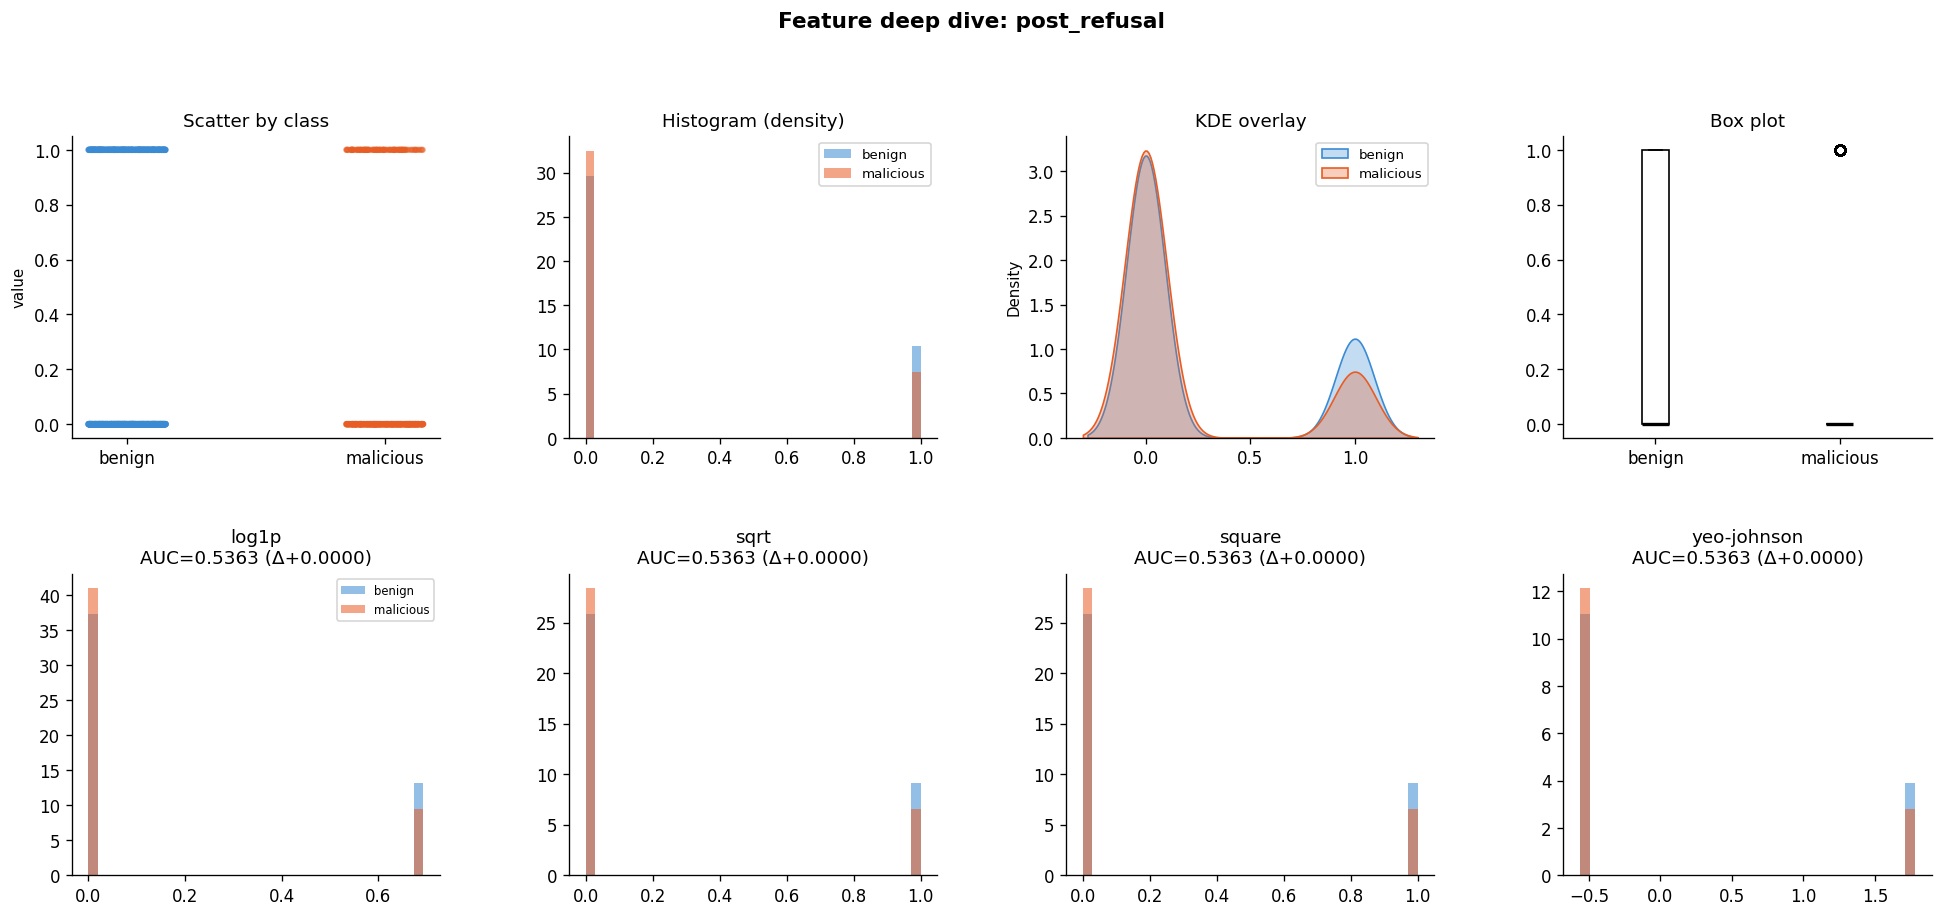

FEATURE: post_refusal
  Raw AUC         : 0.5363
  Skewness        : 1.219  (high)
  Zeros           : 76.0%
  KS stat / p     : 0.0727 / 0.00196
  Mean benign     : 0.2600   malicious: 0.1873
  Best transform  : log1p  →  AUC=0.5363  KS=0.0727
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5363  Δ=+0.0000  KS=0.0727
    sqrt            AUC=0.5363  Δ=+0.0000  KS=0.0727
    square          AUC=0.5363  Δ=+0.0000  KS=0.0727
    yeo-johnson     AUC=0.5363  Δ=+0.0000  KS=0.0727
    quantile        AUC=0.5363  Δ=+0.0000  KS=0.0727
    rank            AUC=0.5363  Δ=+0.0000  KS=0.0727
    binarize        AUC=0.5363  Δ=+0.0000  KS=0.0727


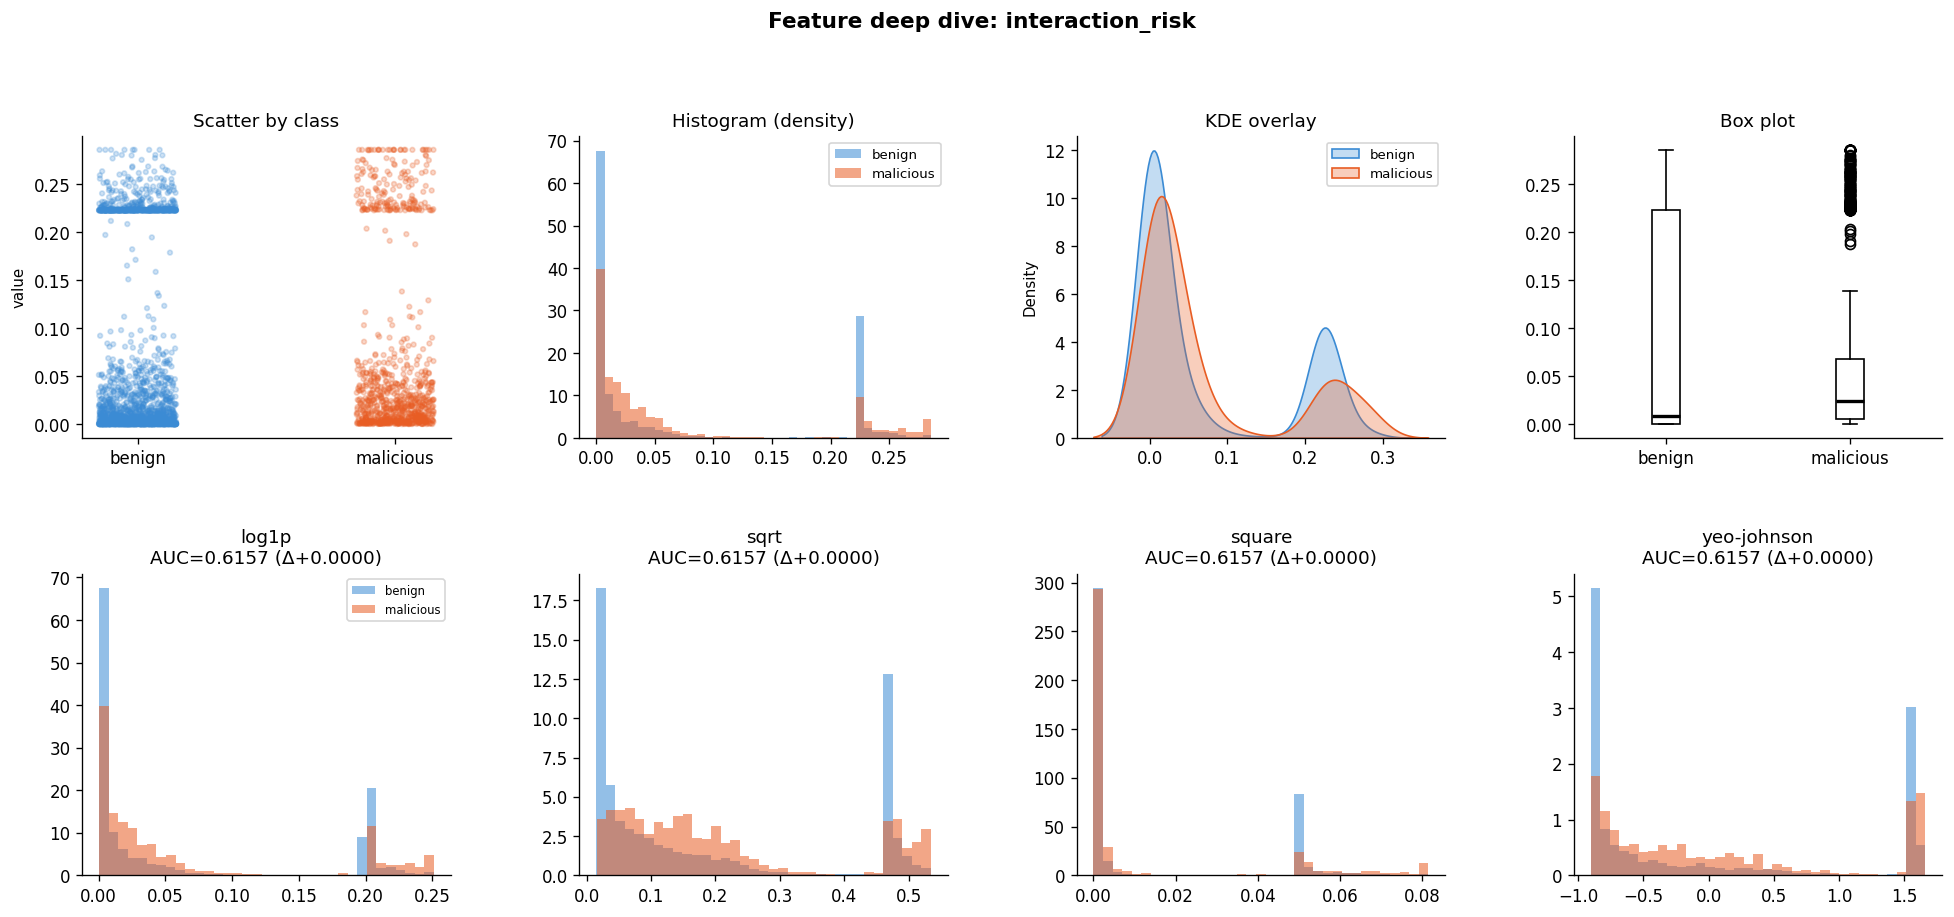

FEATURE: interaction_risk
  Raw AUC         : 0.6157
  Skewness        : 1.567  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.2482 / 0.00000
  Mean benign     : 0.0692   malicious: 0.0735
  Best transform  : log1p  →  AUC=0.6157  KS=0.2482
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.6157  Δ=+0.0000  KS=0.2482
    sqrt            AUC=0.6157  Δ=+0.0000  KS=0.2482
    square          AUC=0.6157  Δ=+0.0000  KS=0.2482
    yeo-johnson     AUC=0.6157  Δ=+0.0000  KS=0.2482
    quantile        AUC=0.6157  Δ=+0.0000  KS=0.2482
    rank            AUC=0.6157  Δ=+0.0000  KS=0.2482
    binarize        AUC=0.5000  Δ=-0.1157  KS=0.0000


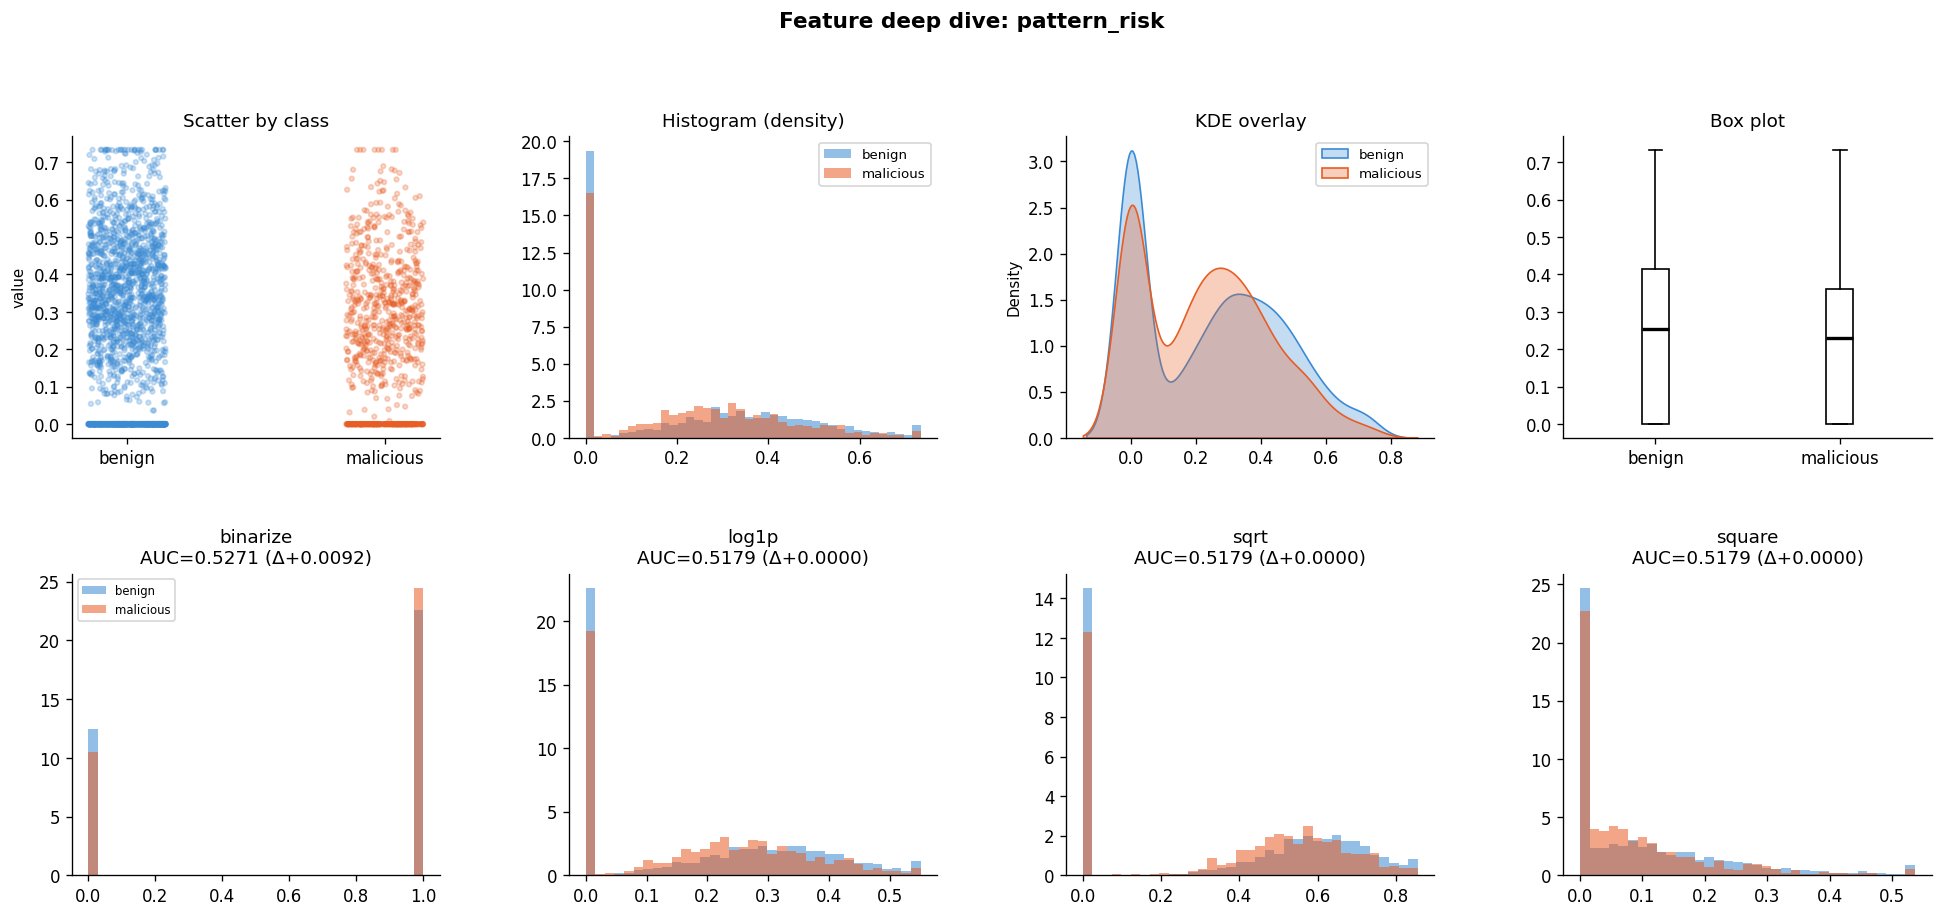

FEATURE: pattern_risk
  Raw AUC         : 0.5179
  Skewness        : 0.361  (low)
  Zeros           : 34.0%
  KS stat / p     : 0.0834 / 0.00022
  Mean benign     : 0.2429   malicious: 0.2272
  Best transform  : binarize  →  AUC=0.5271  KS=0.0541
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5271  Δ=+0.0092  KS=0.0541
    log1p           AUC=0.5179  Δ=+0.0000  KS=0.0834
    sqrt            AUC=0.5179  Δ=+0.0000  KS=0.0834
    square          AUC=0.5179  Δ=+0.0000  KS=0.0834
    yeo-johnson     AUC=0.5179  Δ=+0.0000  KS=0.0834
    quantile        AUC=0.5179  Δ=+0.0000  KS=0.0834
    rank            AUC=0.5179  Δ=+0.0000  KS=0.0834


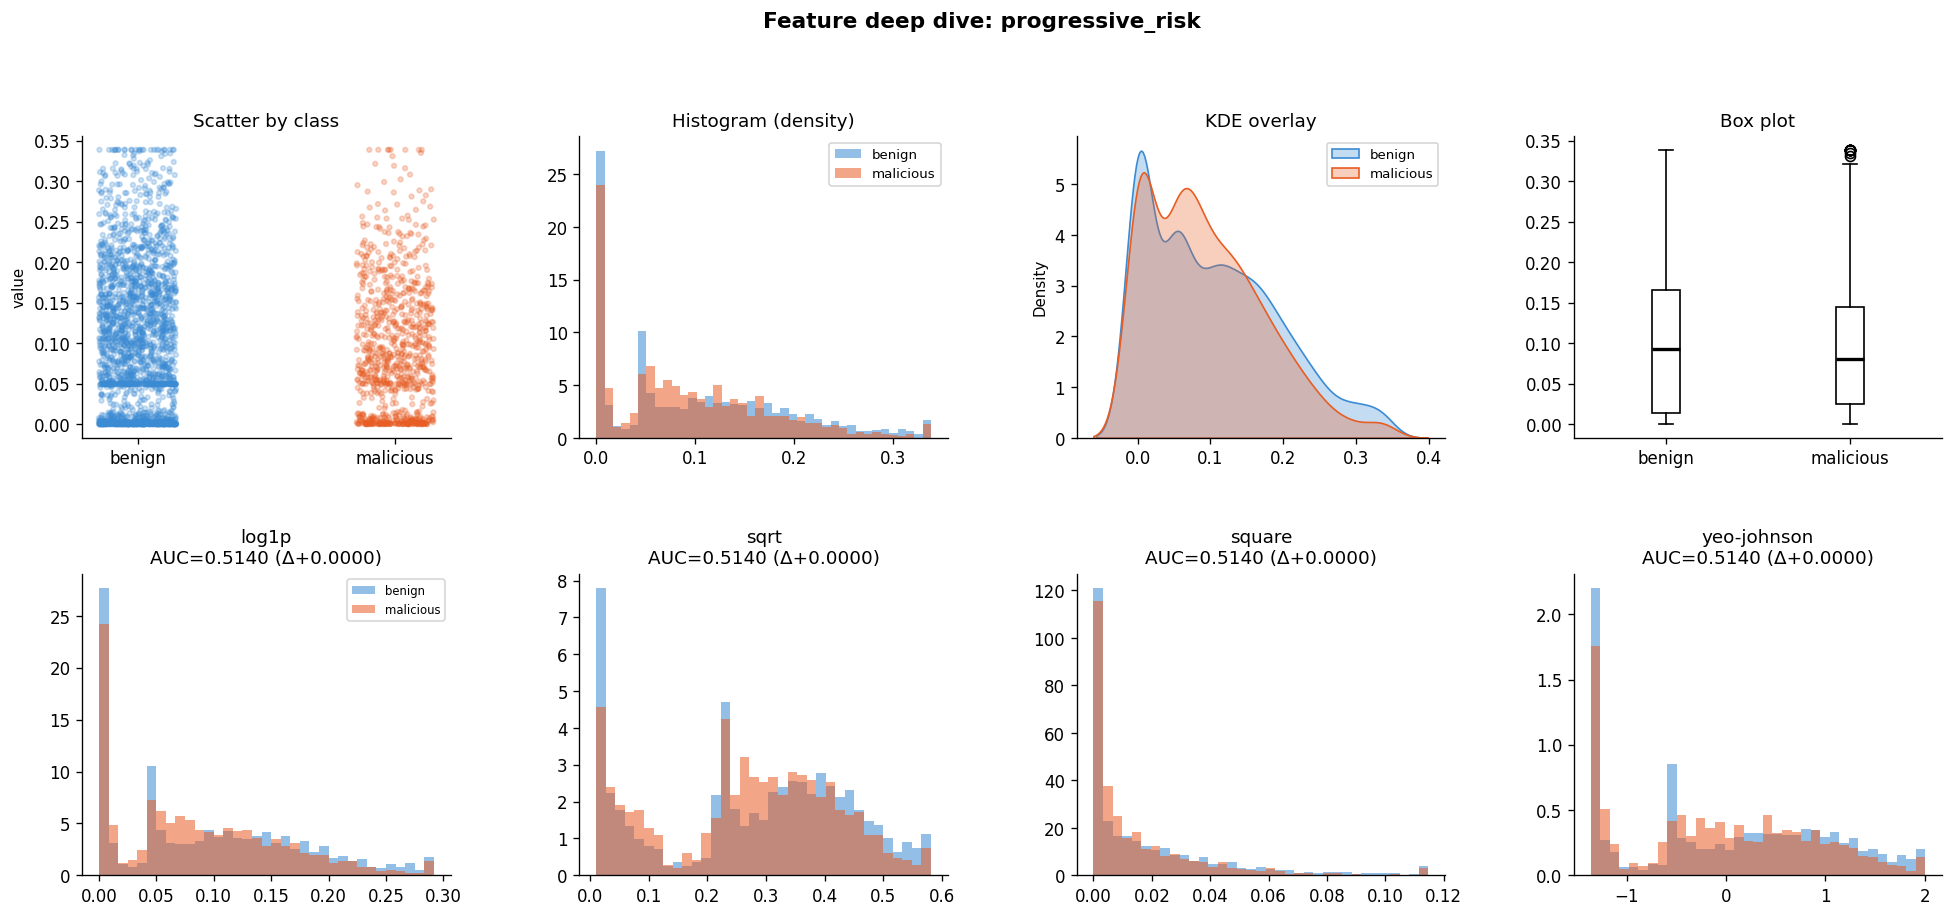

FEATURE: progressive_risk
  Raw AUC         : 0.5140
  Skewness        : 0.744  (moderate)
  Zeros           : 0.3%
  KS stat / p     : 0.0724 / 0.00206
  Mean benign     : 0.1042   malicious: 0.0948
  Best transform  : log1p  →  AUC=0.5140  KS=0.0724
  Verdict         : NOISE
  All transforms (sorted by AUC):
    log1p           AUC=0.5140  Δ=+0.0000  KS=0.0724
    sqrt            AUC=0.5140  Δ=+0.0000  KS=0.0724
    square          AUC=0.5140  Δ=+0.0000  KS=0.0724
    yeo-johnson     AUC=0.5140  Δ=+0.0000  KS=0.0724
    quantile        AUC=0.5140  Δ=+0.0000  KS=0.0724
    rank            AUC=0.5140  Δ=+0.0000  KS=0.0724
    binarize        AUC=0.5021  Δ=-0.0119  KS=0.0042


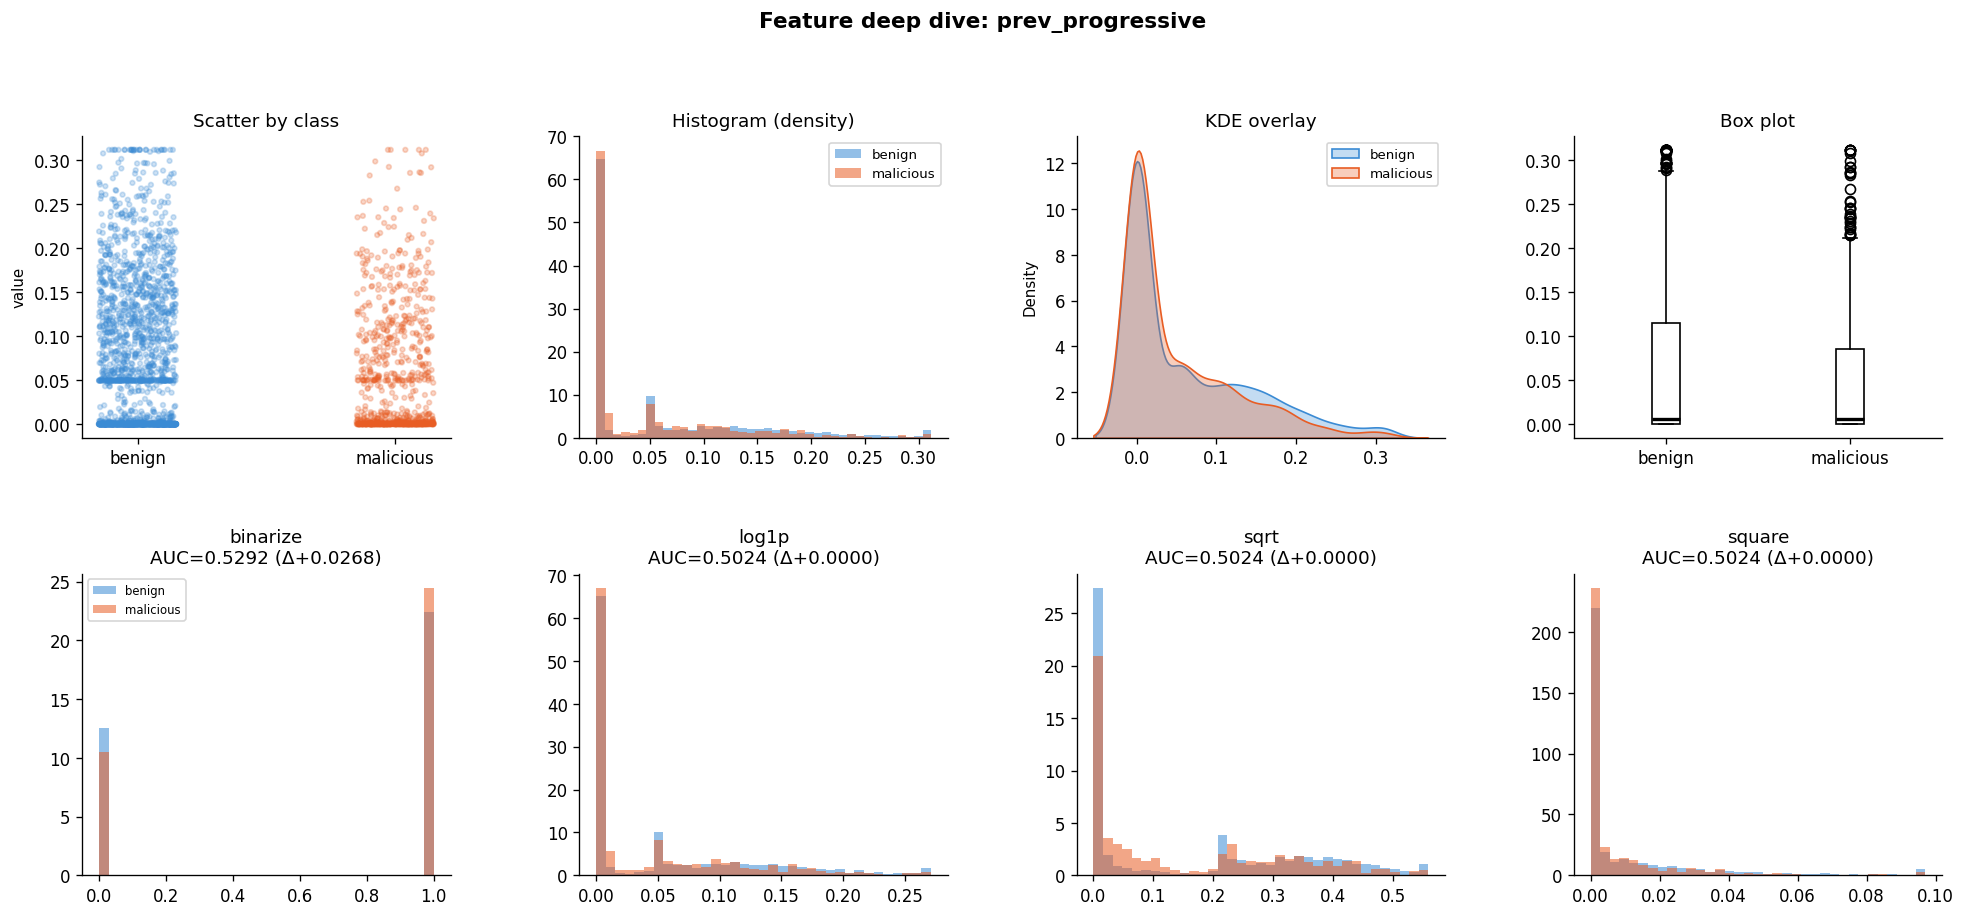

FEATURE: prev_progressive
  Raw AUC         : 0.5024
  Skewness        : 1.35  (high)
  Zeros           : 34.3%
  KS stat / p     : 0.1082 / 0.00000
  Mean benign     : 0.0627   malicious: 0.0504
  Best transform  : binarize  →  AUC=0.5292  KS=0.0584
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5292  Δ=+0.0268  KS=0.0584
    log1p           AUC=0.5024  Δ=+0.0000  KS=0.1082
    sqrt            AUC=0.5024  Δ=+0.0000  KS=0.1082
    square          AUC=0.5024  Δ=+0.0000  KS=0.1082
    yeo-johnson     AUC=0.5024  Δ=+0.0000  KS=0.1082
    quantile        AUC=0.5024  Δ=+0.0000  KS=0.1082
    rank            AUC=0.5024  Δ=+0.0000  KS=0.1082


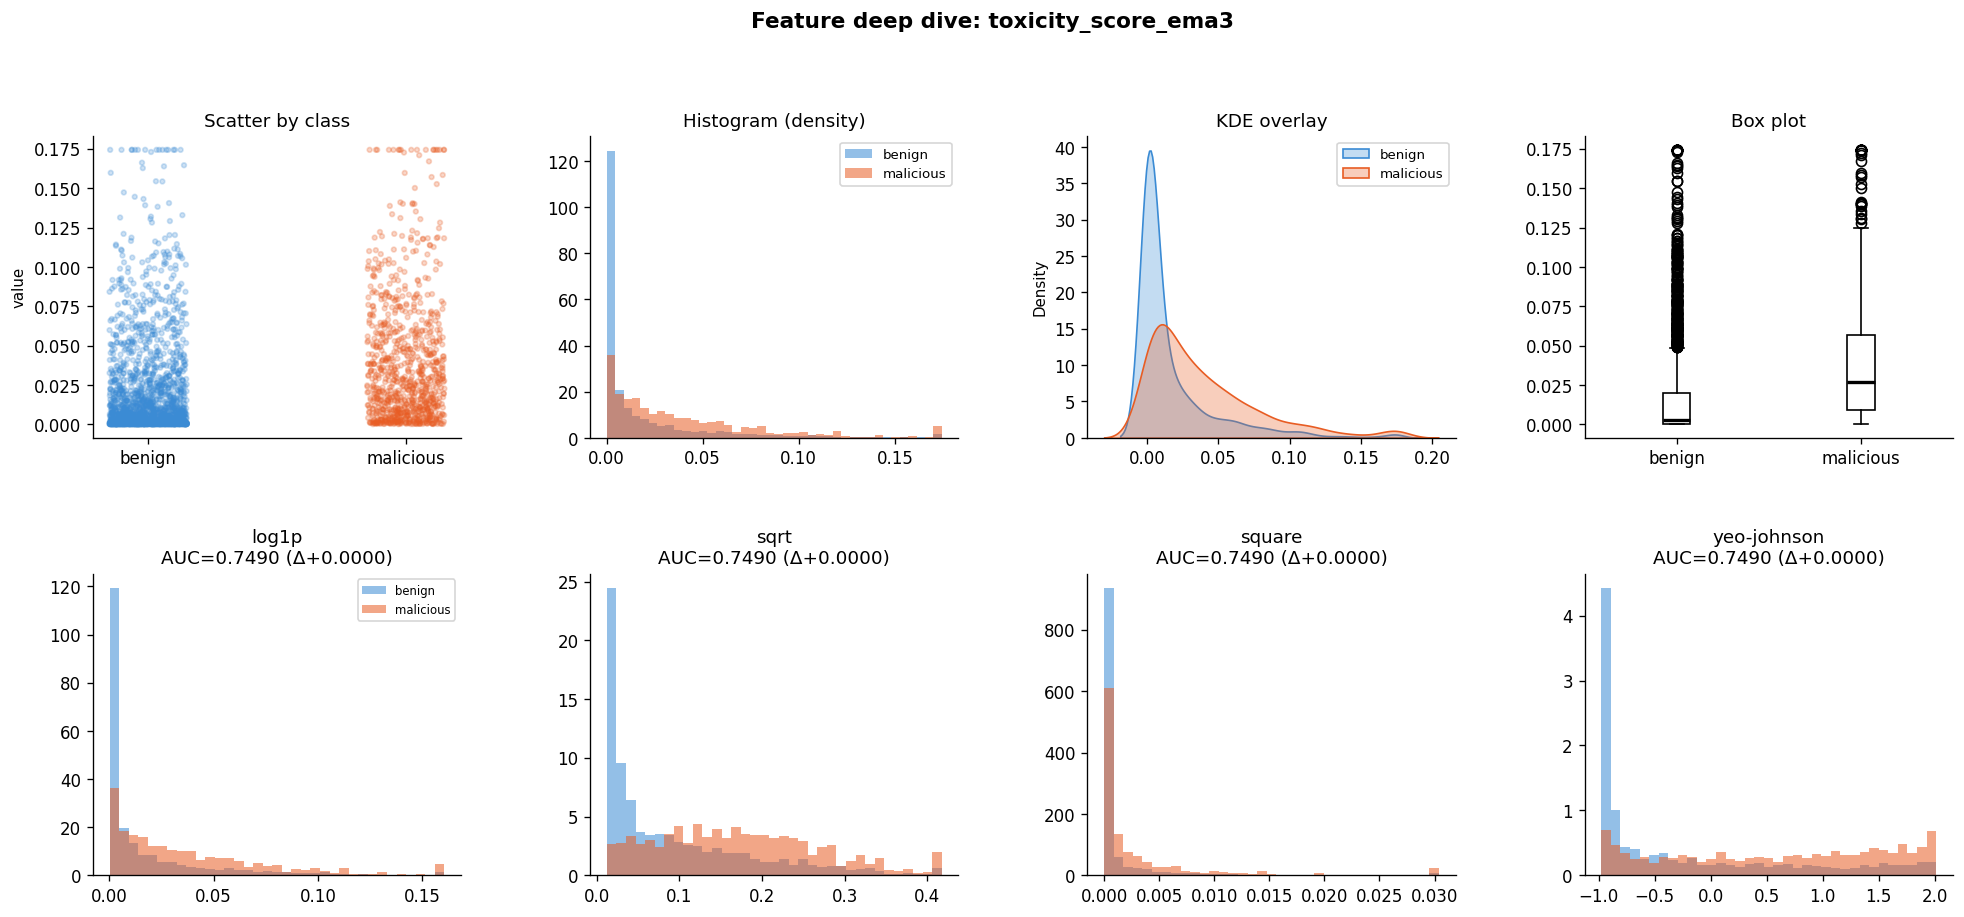

FEATURE: toxicity_score_ema3
  Raw AUC         : 0.7490
  Skewness        : 7.197  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3993 / 0.00000
  Mean benign     : 0.0181   malicious: 0.0431
  Best transform  : log1p  →  AUC=0.7490  KS=0.3993
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7490  Δ=+0.0000  KS=0.3993
    sqrt            AUC=0.7490  Δ=+0.0000  KS=0.3993
    square          AUC=0.7490  Δ=+0.0000  KS=0.3993
    yeo-johnson     AUC=0.7490  Δ=+0.0000  KS=0.3993
    quantile        AUC=0.7490  Δ=+0.0000  KS=0.3993
    rank            AUC=0.7490  Δ=+0.0000  KS=0.3993
    binarize        AUC=0.5000  Δ=-0.2490  KS=0.0000


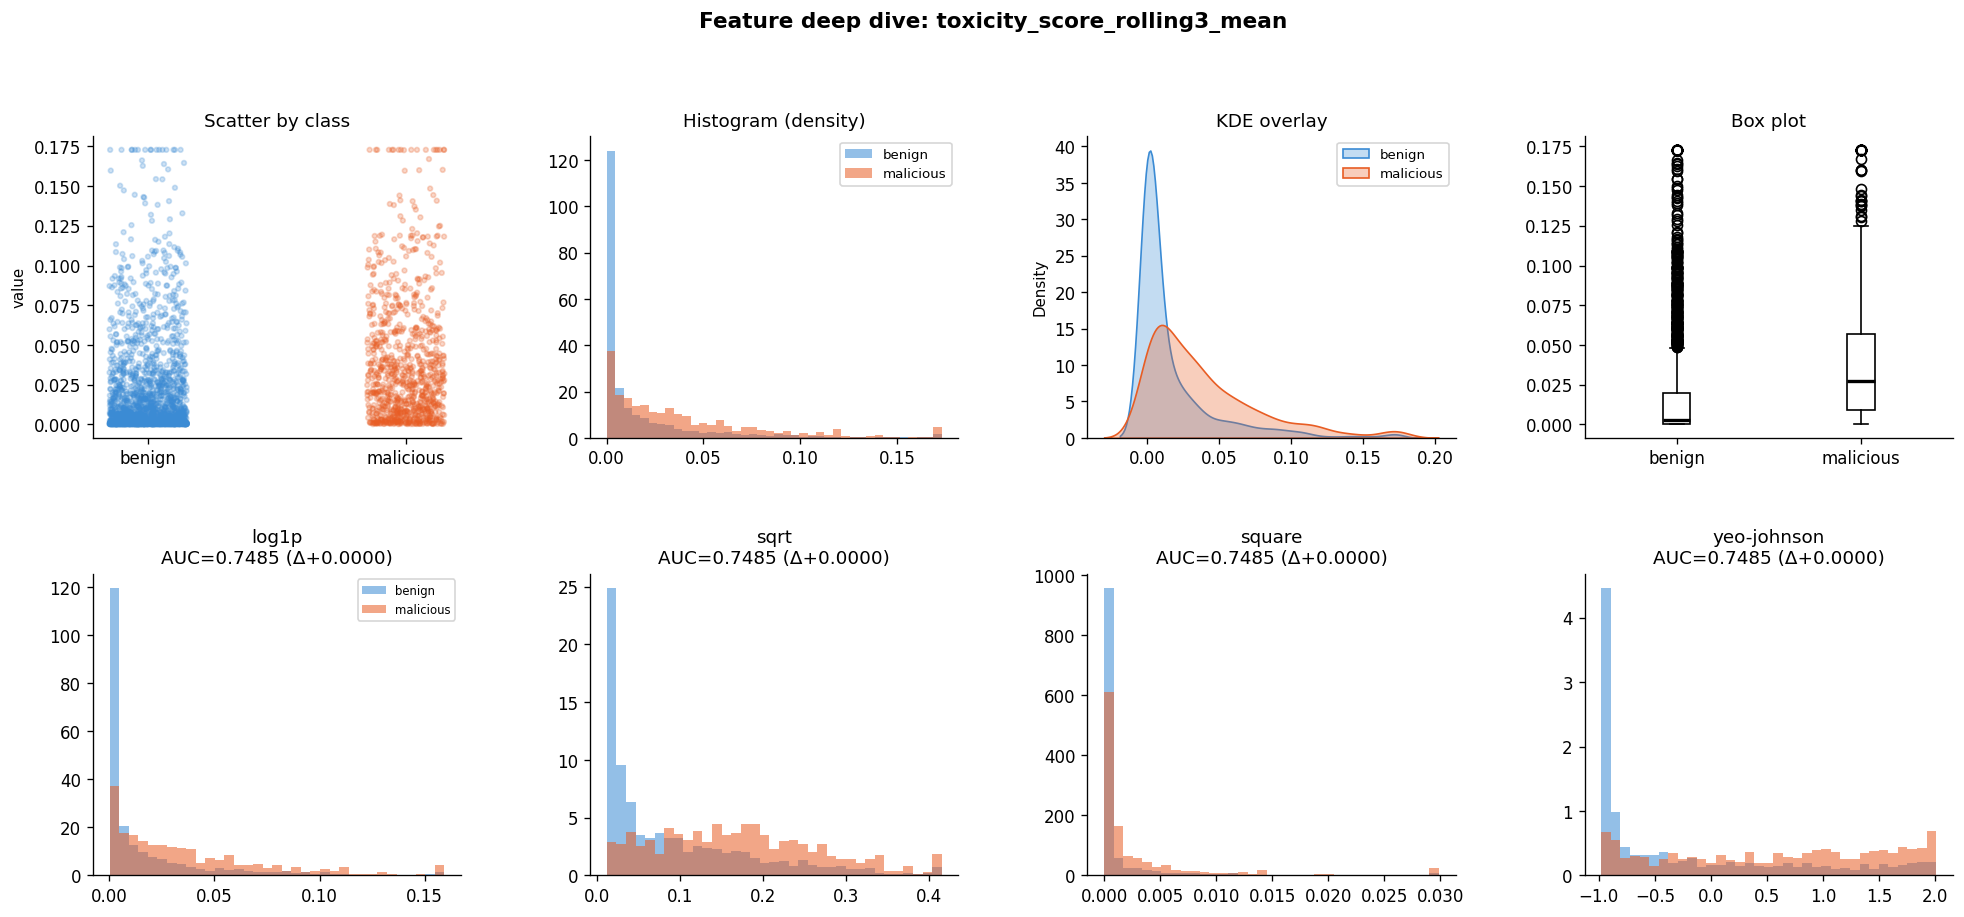

FEATURE: toxicity_score_rolling3_mean
  Raw AUC         : 0.7485
  Skewness        : 7.152  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.4020 / 0.00000
  Mean benign     : 0.0181   malicious: 0.0423
  Best transform  : log1p  →  AUC=0.7485  KS=0.4020
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7485  Δ=+0.0000  KS=0.4020
    sqrt            AUC=0.7485  Δ=+0.0000  KS=0.4020
    square          AUC=0.7485  Δ=+0.0000  KS=0.4020
    yeo-johnson     AUC=0.7485  Δ=+0.0000  KS=0.4020
    quantile        AUC=0.7485  Δ=+0.0000  KS=0.4020
    rank            AUC=0.7485  Δ=+0.0000  KS=0.4020
    binarize        AUC=0.5000  Δ=-0.2485  KS=0.0000


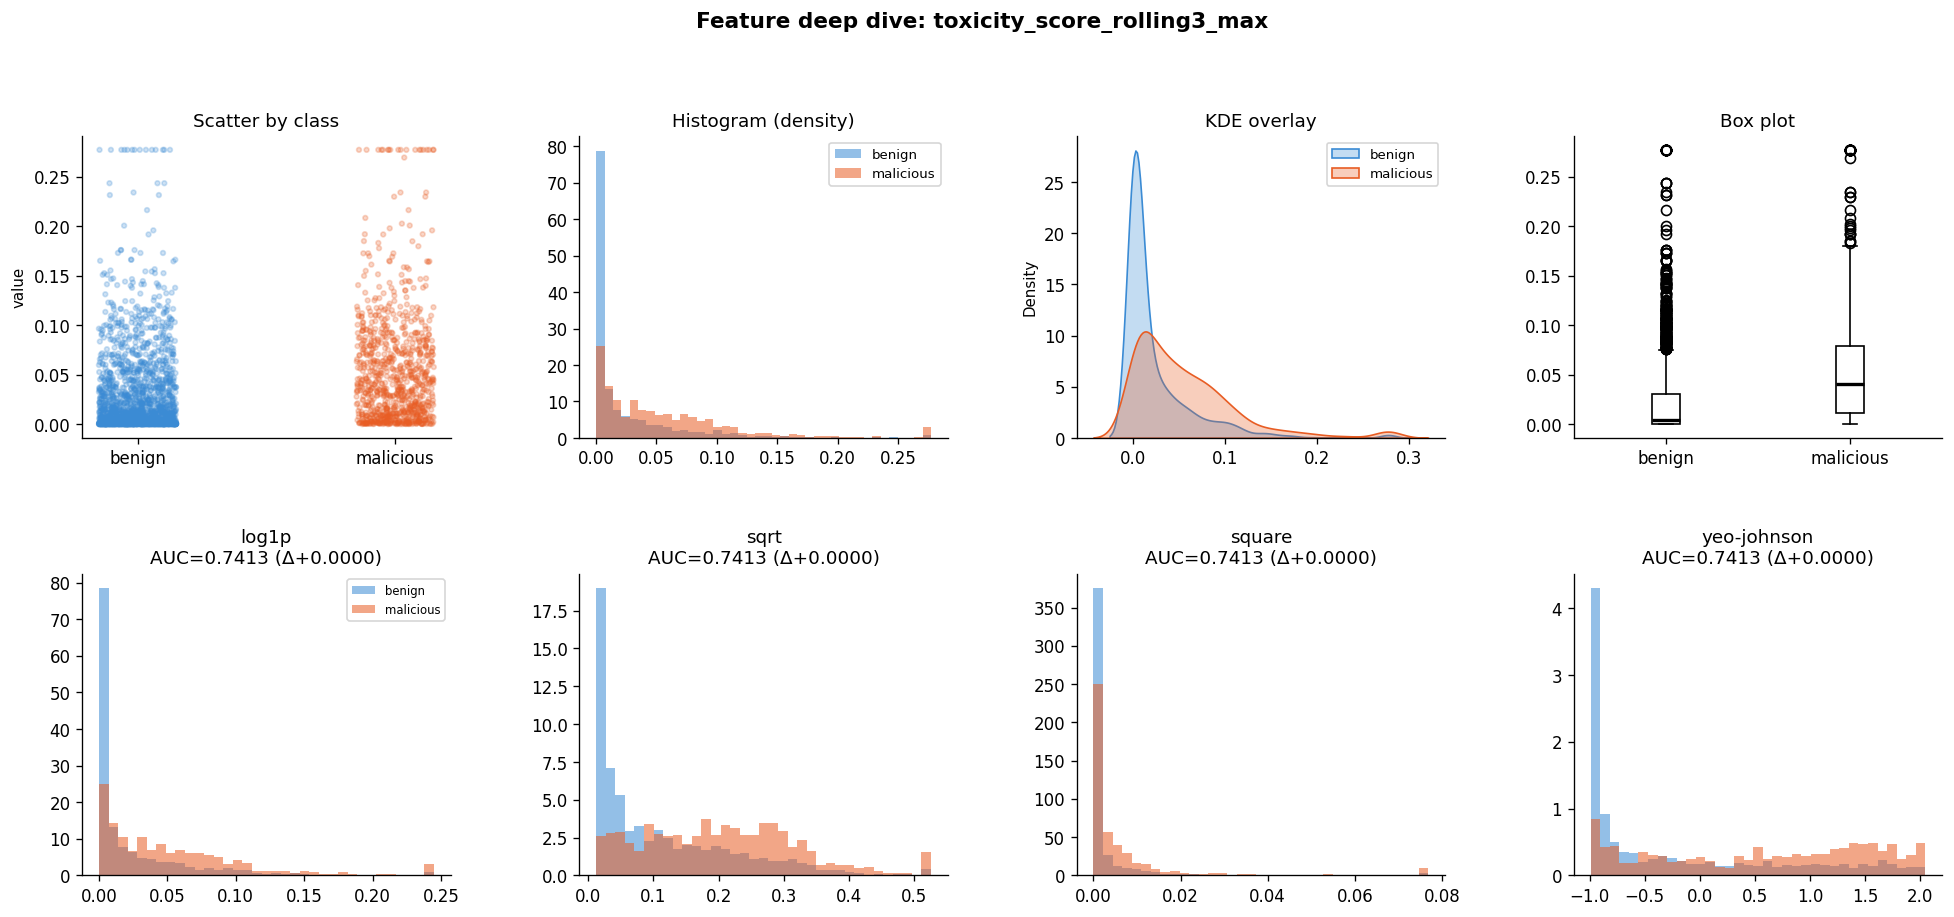

FEATURE: toxicity_score_rolling3_max
  Raw AUC         : 0.7413
  Skewness        : 7.266  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3783 / 0.00000
  Mean benign     : 0.0253   malicious: 0.0609
  Best transform  : log1p  →  AUC=0.7413  KS=0.3783
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7413  Δ=+0.0000  KS=0.3783
    sqrt            AUC=0.7413  Δ=+0.0000  KS=0.3783
    square          AUC=0.7413  Δ=+0.0000  KS=0.3783
    yeo-johnson     AUC=0.7413  Δ=+0.0000  KS=0.3783
    quantile        AUC=0.7413  Δ=+0.0000  KS=0.3783
    rank            AUC=0.7413  Δ=+0.0000  KS=0.3783
    binarize        AUC=0.5000  Δ=-0.2413  KS=0.0000


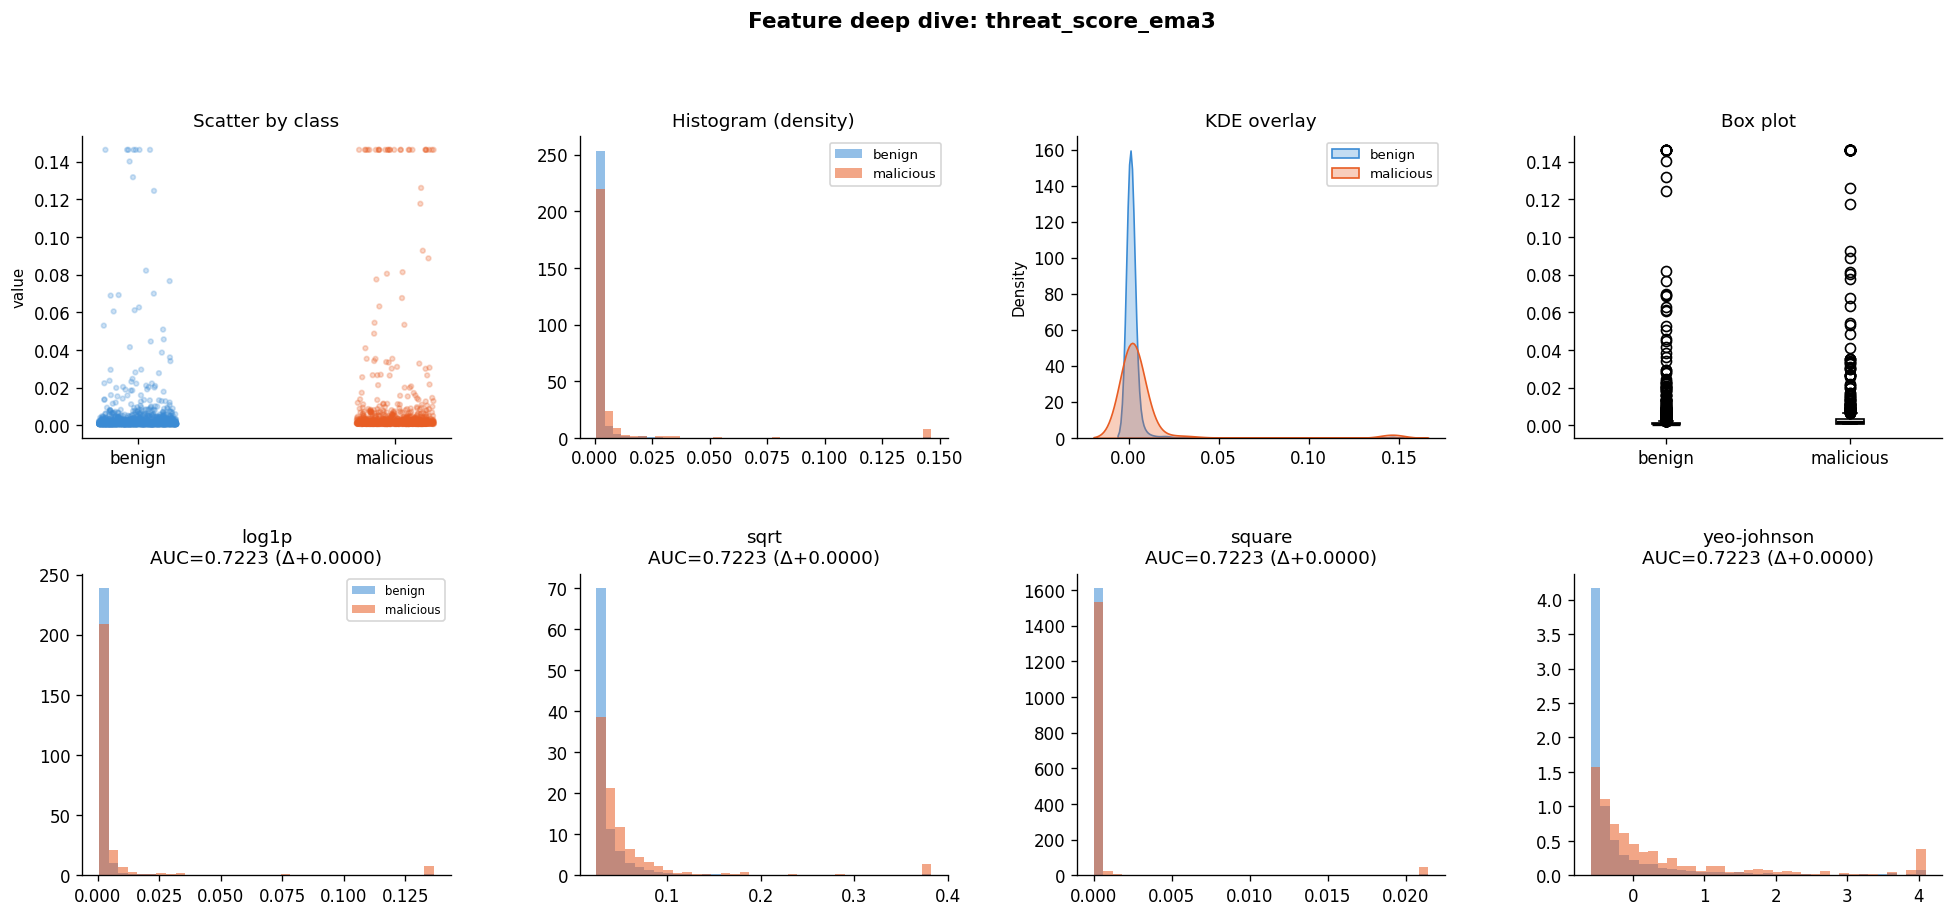

FEATURE: threat_score_ema3
  Raw AUC         : 0.7223
  Skewness        : 12.269  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3585 / 0.00000
  Mean benign     : 0.0030   malicious: 0.0148
  Best transform  : log1p  →  AUC=0.7223  KS=0.3585
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7223  Δ=+0.0000  KS=0.3585
    sqrt            AUC=0.7223  Δ=+0.0000  KS=0.3585
    square          AUC=0.7223  Δ=+0.0000  KS=0.3585
    yeo-johnson     AUC=0.7223  Δ=+0.0000  KS=0.3585
    quantile        AUC=0.7223  Δ=+0.0000  KS=0.3585
    rank            AUC=0.7223  Δ=+0.0000  KS=0.3585
    binarize        AUC=0.5000  Δ=-0.2223  KS=0.0000


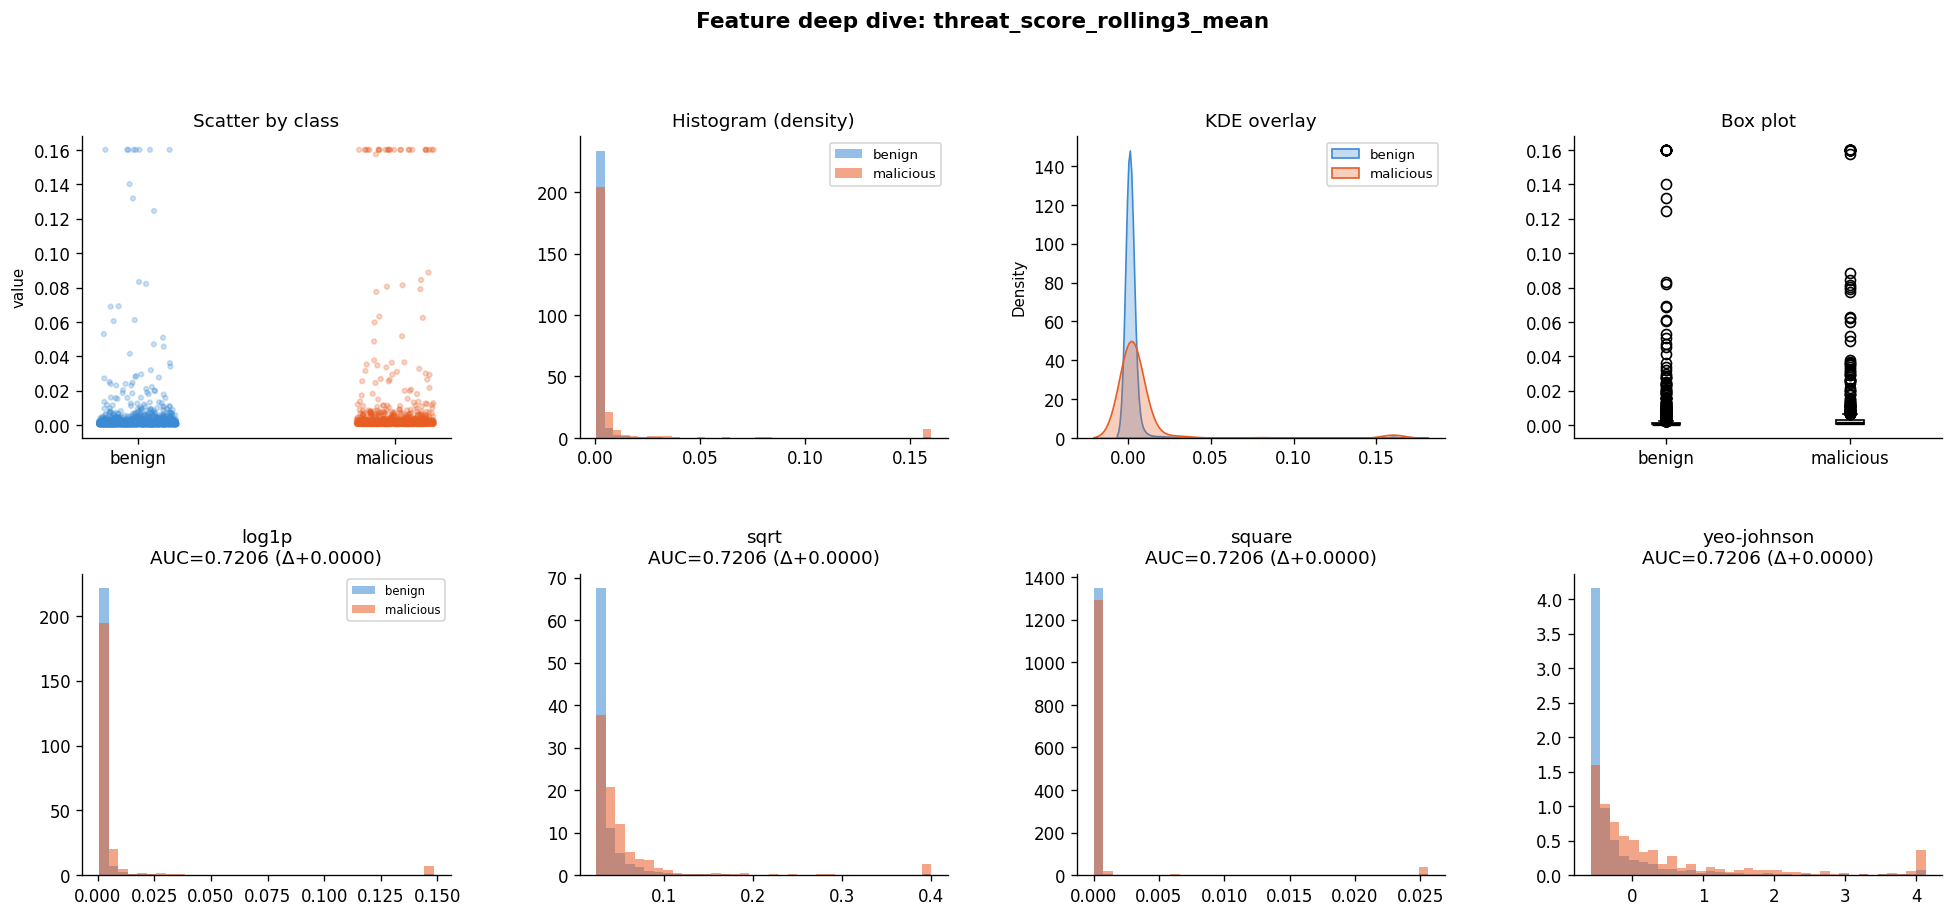

FEATURE: threat_score_rolling3_mean
  Raw AUC         : 0.7206
  Skewness        : 12.576  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3541 / 0.00000
  Mean benign     : 0.0031   malicious: 0.0135
  Best transform  : log1p  →  AUC=0.7206  KS=0.3541
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7206  Δ=+0.0000  KS=0.3541
    sqrt            AUC=0.7206  Δ=+0.0000  KS=0.3541
    square          AUC=0.7206  Δ=+0.0000  KS=0.3541
    yeo-johnson     AUC=0.7206  Δ=+0.0000  KS=0.3541
    quantile        AUC=0.7206  Δ=+0.0000  KS=0.3541
    rank            AUC=0.7206  Δ=+0.0000  KS=0.3541
    binarize        AUC=0.5000  Δ=-0.2206  KS=0.0000


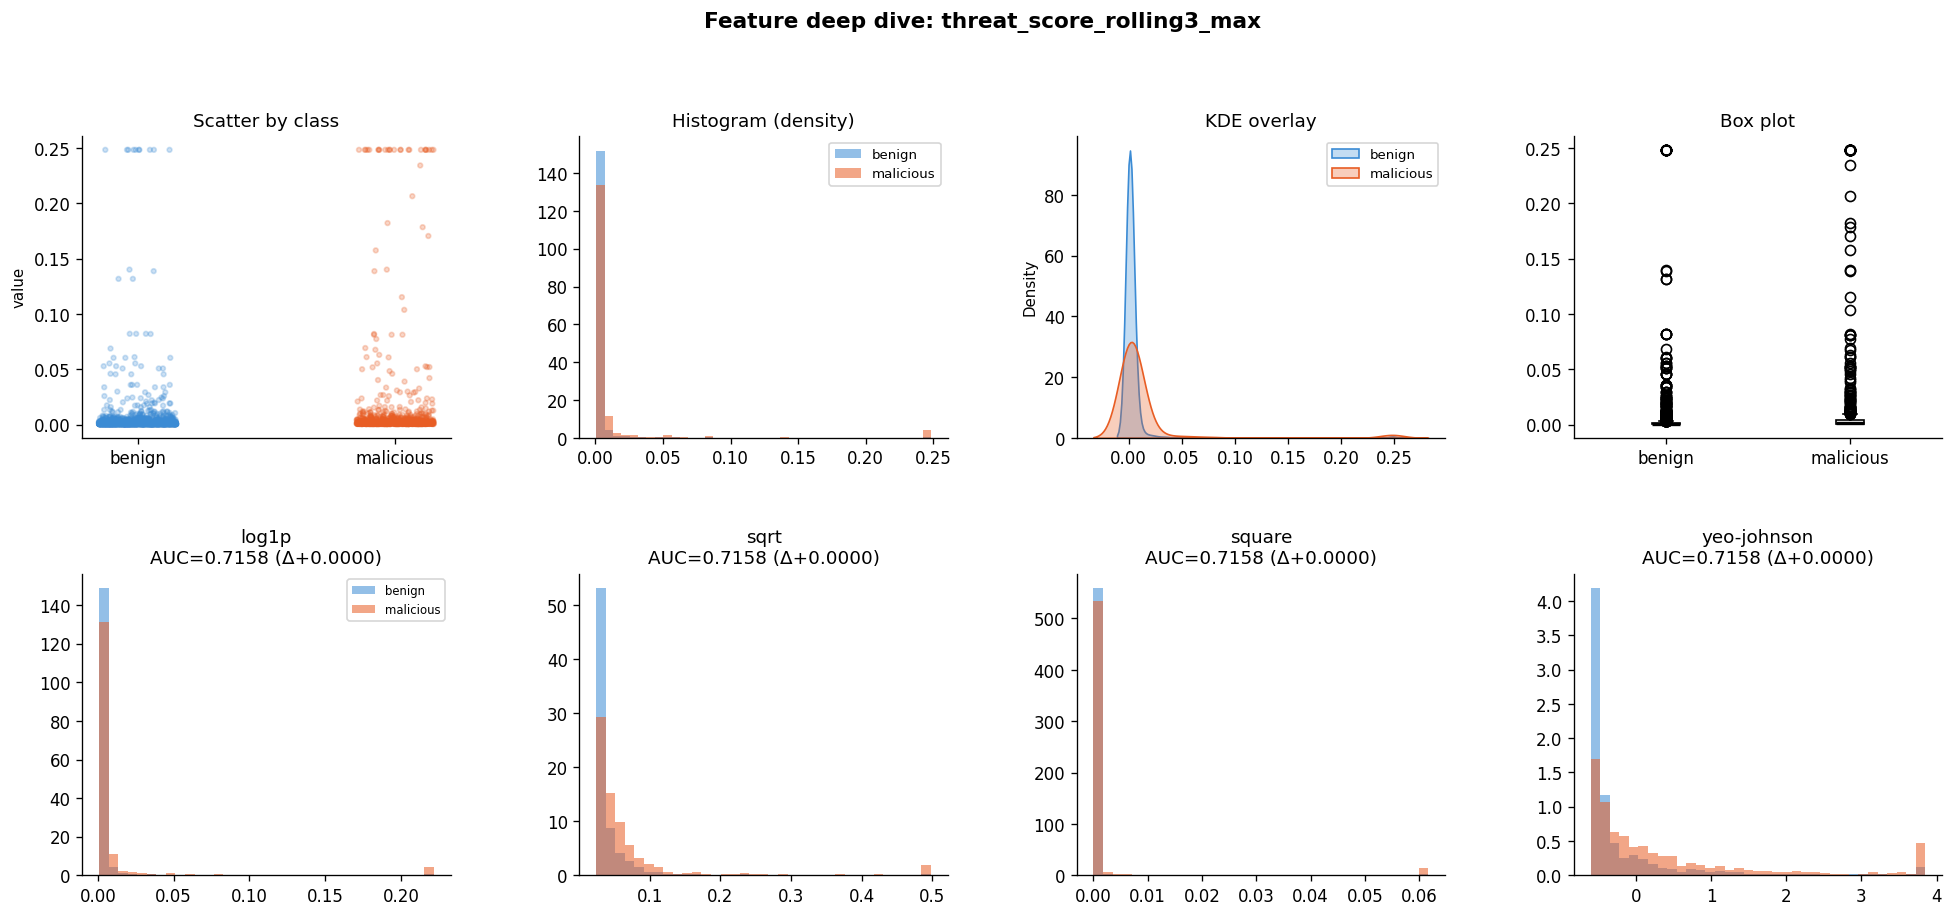

FEATURE: threat_score_rolling3_max
  Raw AUC         : 0.7158
  Skewness        : 10.512  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3475 / 0.00000
  Mean benign     : 0.0049   malicious: 0.0250
  Best transform  : log1p  →  AUC=0.7158  KS=0.3475
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7158  Δ=+0.0000  KS=0.3475
    sqrt            AUC=0.7158  Δ=+0.0000  KS=0.3475
    square          AUC=0.7158  Δ=+0.0000  KS=0.3475
    yeo-johnson     AUC=0.7158  Δ=+0.0000  KS=0.3475
    quantile        AUC=0.7158  Δ=+0.0000  KS=0.3475
    rank            AUC=0.7158  Δ=+0.0000  KS=0.3475
    binarize        AUC=0.5000  Δ=-0.2158  KS=0.0000


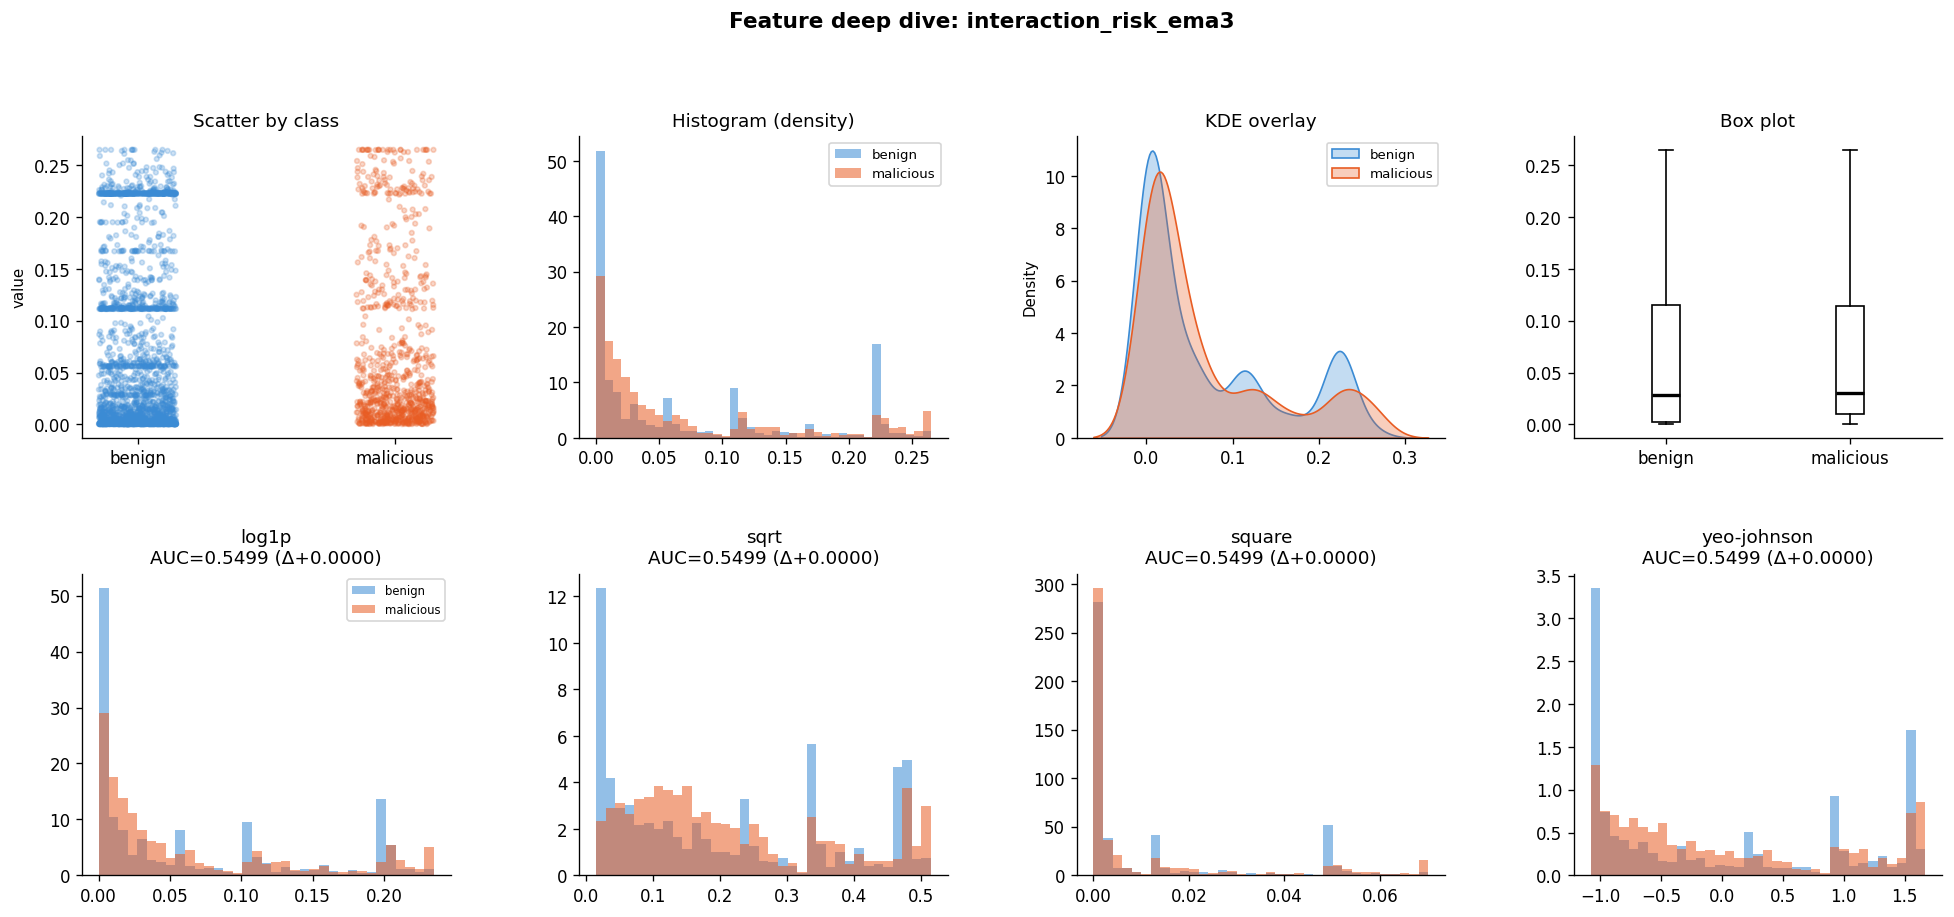

FEATURE: interaction_risk_ema3
  Raw AUC         : 0.5499
  Skewness        : 1.332  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.1704 / 0.00000
  Mean benign     : 0.0706   malicious: 0.0703
  Best transform  : log1p  →  AUC=0.5499  KS=0.1704
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5499  Δ=+0.0000  KS=0.1704
    sqrt            AUC=0.5499  Δ=+0.0000  KS=0.1704
    square          AUC=0.5499  Δ=+0.0000  KS=0.1704
    yeo-johnson     AUC=0.5499  Δ=+0.0000  KS=0.1704
    quantile        AUC=0.5499  Δ=+0.0000  KS=0.1704
    rank            AUC=0.5499  Δ=+0.0000  KS=0.1704
    binarize        AUC=0.5000  Δ=-0.0499  KS=0.0000


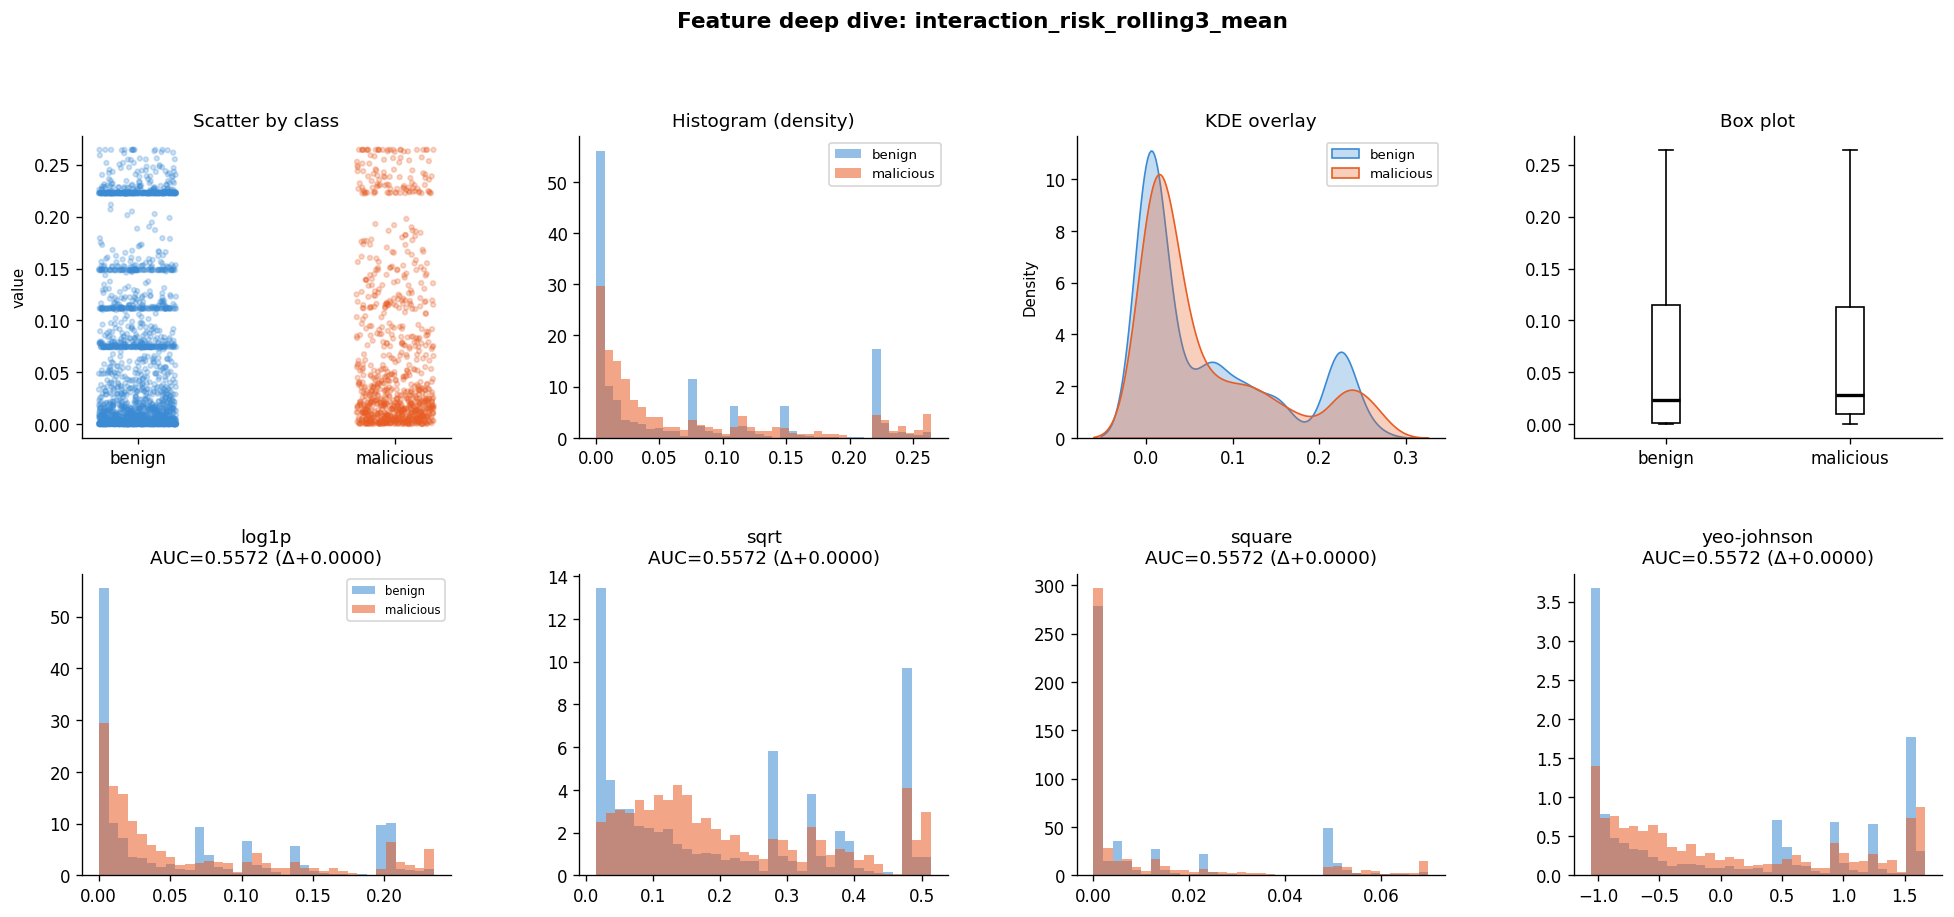

FEATURE: interaction_risk_rolling3_mean
  Raw AUC         : 0.5572
  Skewness        : 1.281  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.1924 / 0.00000
  Mean benign     : 0.0707   malicious: 0.0701
  Best transform  : log1p  →  AUC=0.5572  KS=0.1924
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5572  Δ=+0.0000  KS=0.1924
    sqrt            AUC=0.5572  Δ=+0.0000  KS=0.1924
    square          AUC=0.5572  Δ=+0.0000  KS=0.1924
    yeo-johnson     AUC=0.5572  Δ=+0.0000  KS=0.1924
    quantile        AUC=0.5572  Δ=+0.0000  KS=0.1924
    rank            AUC=0.5572  Δ=+0.0000  KS=0.1924
    binarize        AUC=0.5000  Δ=-0.0572  KS=0.0000


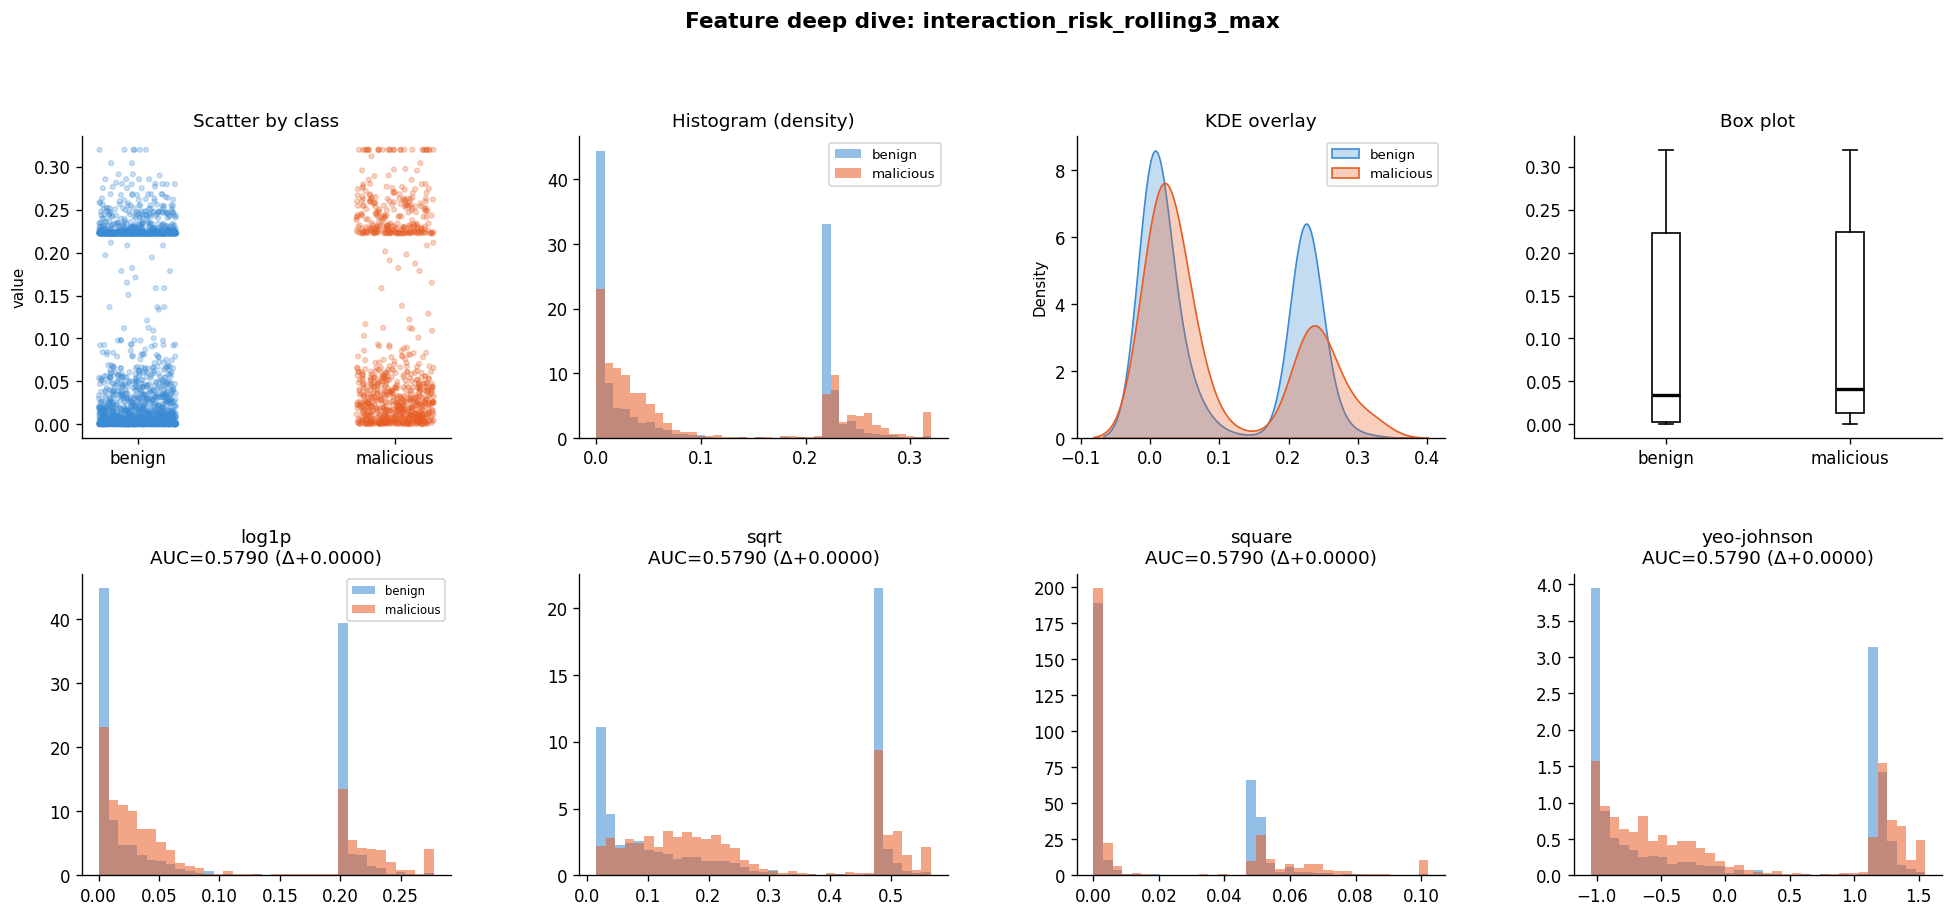

FEATURE: interaction_risk_rolling3_max
  Raw AUC         : 0.5790
  Skewness        : 0.925  (moderate)
  Zeros           : 0.0%
  KS stat / p     : 0.1784 / 0.00000
  Mean benign     : 0.1011   malicious: 0.1024
  Best transform  : log1p  →  AUC=0.5790  KS=0.1784
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5790  Δ=+0.0000  KS=0.1784
    sqrt            AUC=0.5790  Δ=+0.0000  KS=0.1784
    square          AUC=0.5790  Δ=+0.0000  KS=0.1784
    yeo-johnson     AUC=0.5790  Δ=+0.0000  KS=0.1784
    quantile        AUC=0.5790  Δ=+0.0000  KS=0.1784
    rank            AUC=0.5790  Δ=+0.0000  KS=0.1784
    binarize        AUC=0.5000  Δ=-0.0790  KS=0.0000


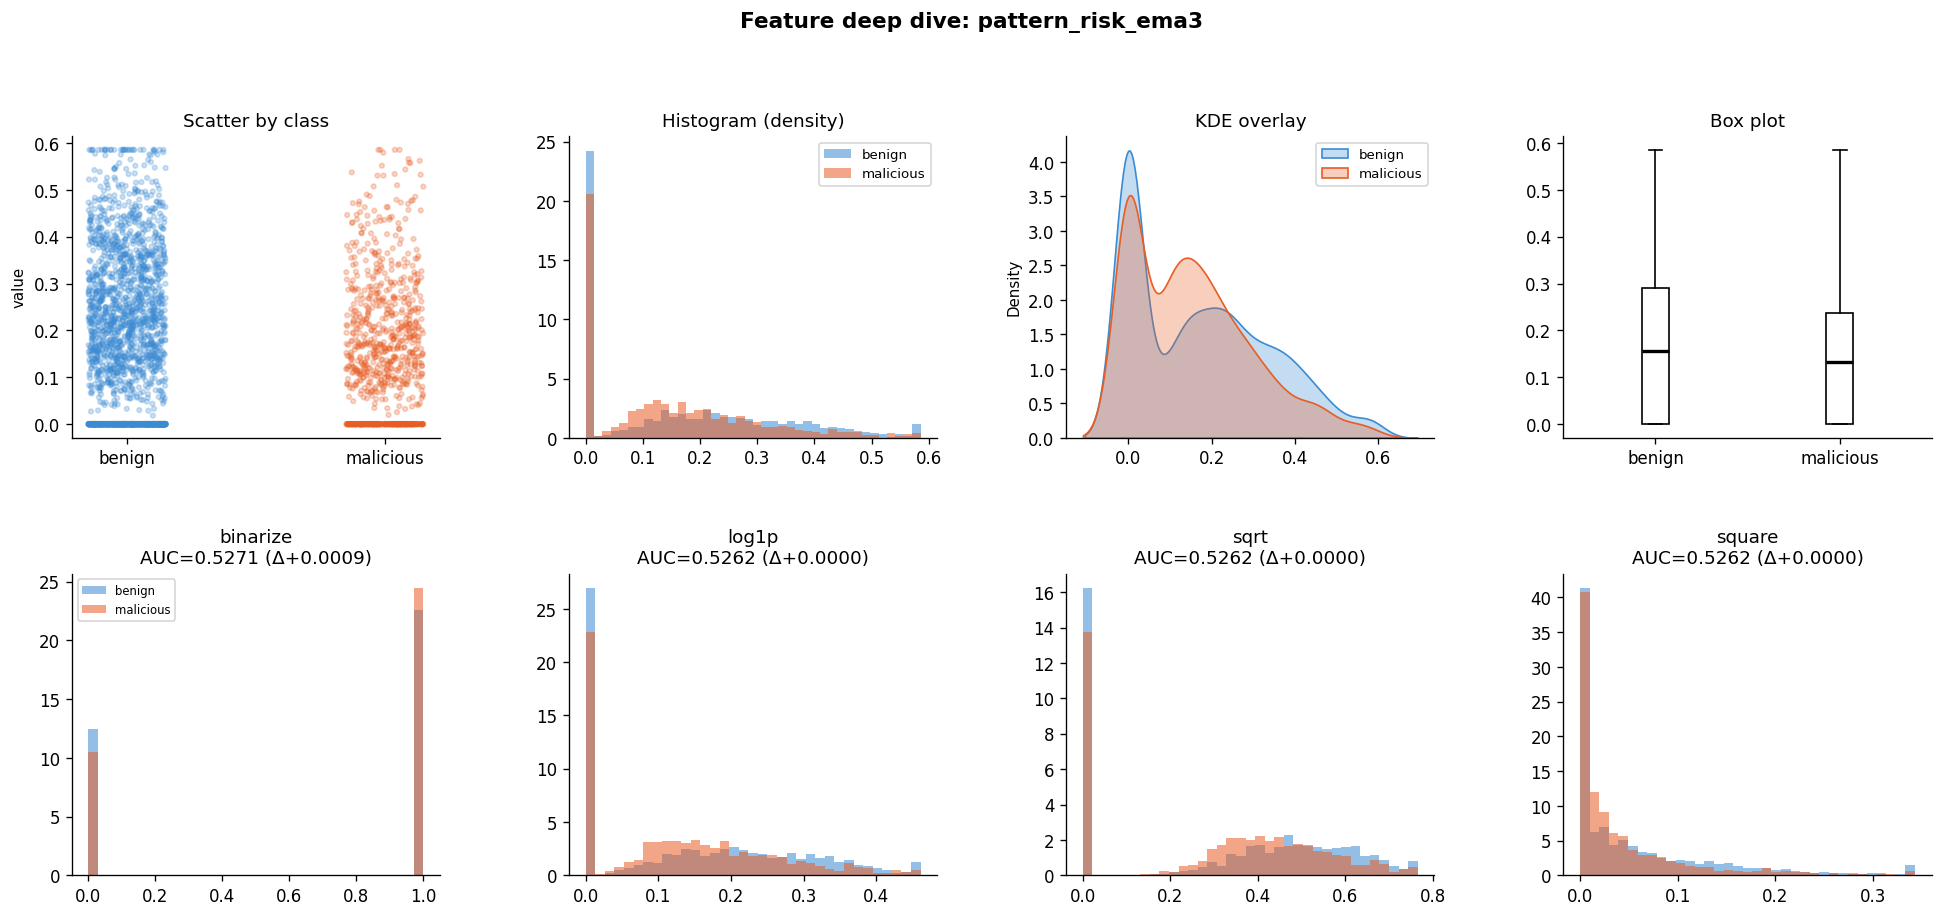

FEATURE: pattern_risk_ema3
  Raw AUC         : 0.5262
  Skewness        : 0.662  (moderate)
  Zeros           : 34.0%
  KS stat / p     : 0.1033 / 0.00000
  Mean benign     : 0.1727   malicious: 0.1520
  Best transform  : binarize  →  AUC=0.5271  KS=0.0541
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5271  Δ=+0.0009  KS=0.0541
    log1p           AUC=0.5262  Δ=+0.0000  KS=0.1033
    sqrt            AUC=0.5262  Δ=+0.0000  KS=0.1033
    square          AUC=0.5262  Δ=+0.0000  KS=0.1033
    yeo-johnson     AUC=0.5262  Δ=+0.0000  KS=0.1033
    quantile        AUC=0.5262  Δ=+0.0000  KS=0.1033
    rank            AUC=0.5262  Δ=+0.0000  KS=0.1033


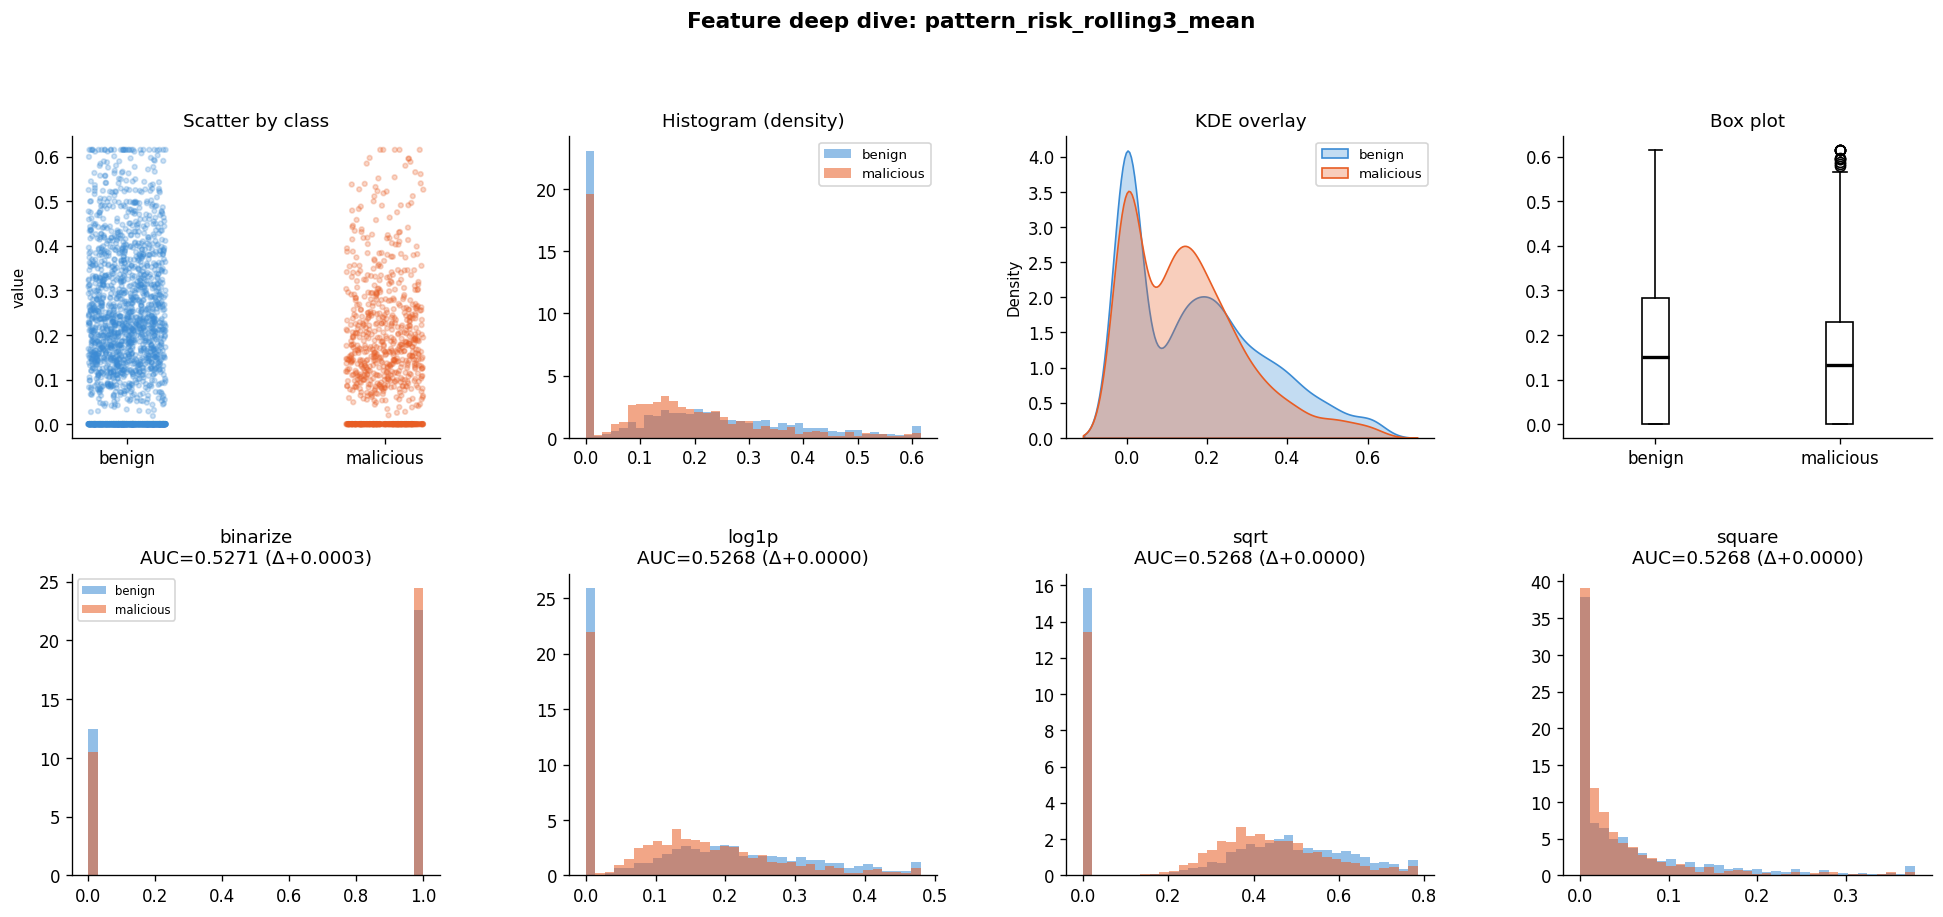

FEATURE: pattern_risk_rolling3_mean
  Raw AUC         : 0.5268
  Skewness        : 0.815  (moderate)
  Zeros           : 34.0%
  KS stat / p     : 0.0989 / 0.00001
  Mean benign     : 0.1724   malicious: 0.1500
  Best transform  : binarize  →  AUC=0.5271  KS=0.0541
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5271  Δ=+0.0003  KS=0.0541
    log1p           AUC=0.5268  Δ=+0.0000  KS=0.0989
    sqrt            AUC=0.5268  Δ=+0.0000  KS=0.0989
    square          AUC=0.5268  Δ=+0.0000  KS=0.0989
    yeo-johnson     AUC=0.5268  Δ=+0.0000  KS=0.0989
    quantile        AUC=0.5268  Δ=+0.0000  KS=0.0989
    rank            AUC=0.5268  Δ=+0.0000  KS=0.0989


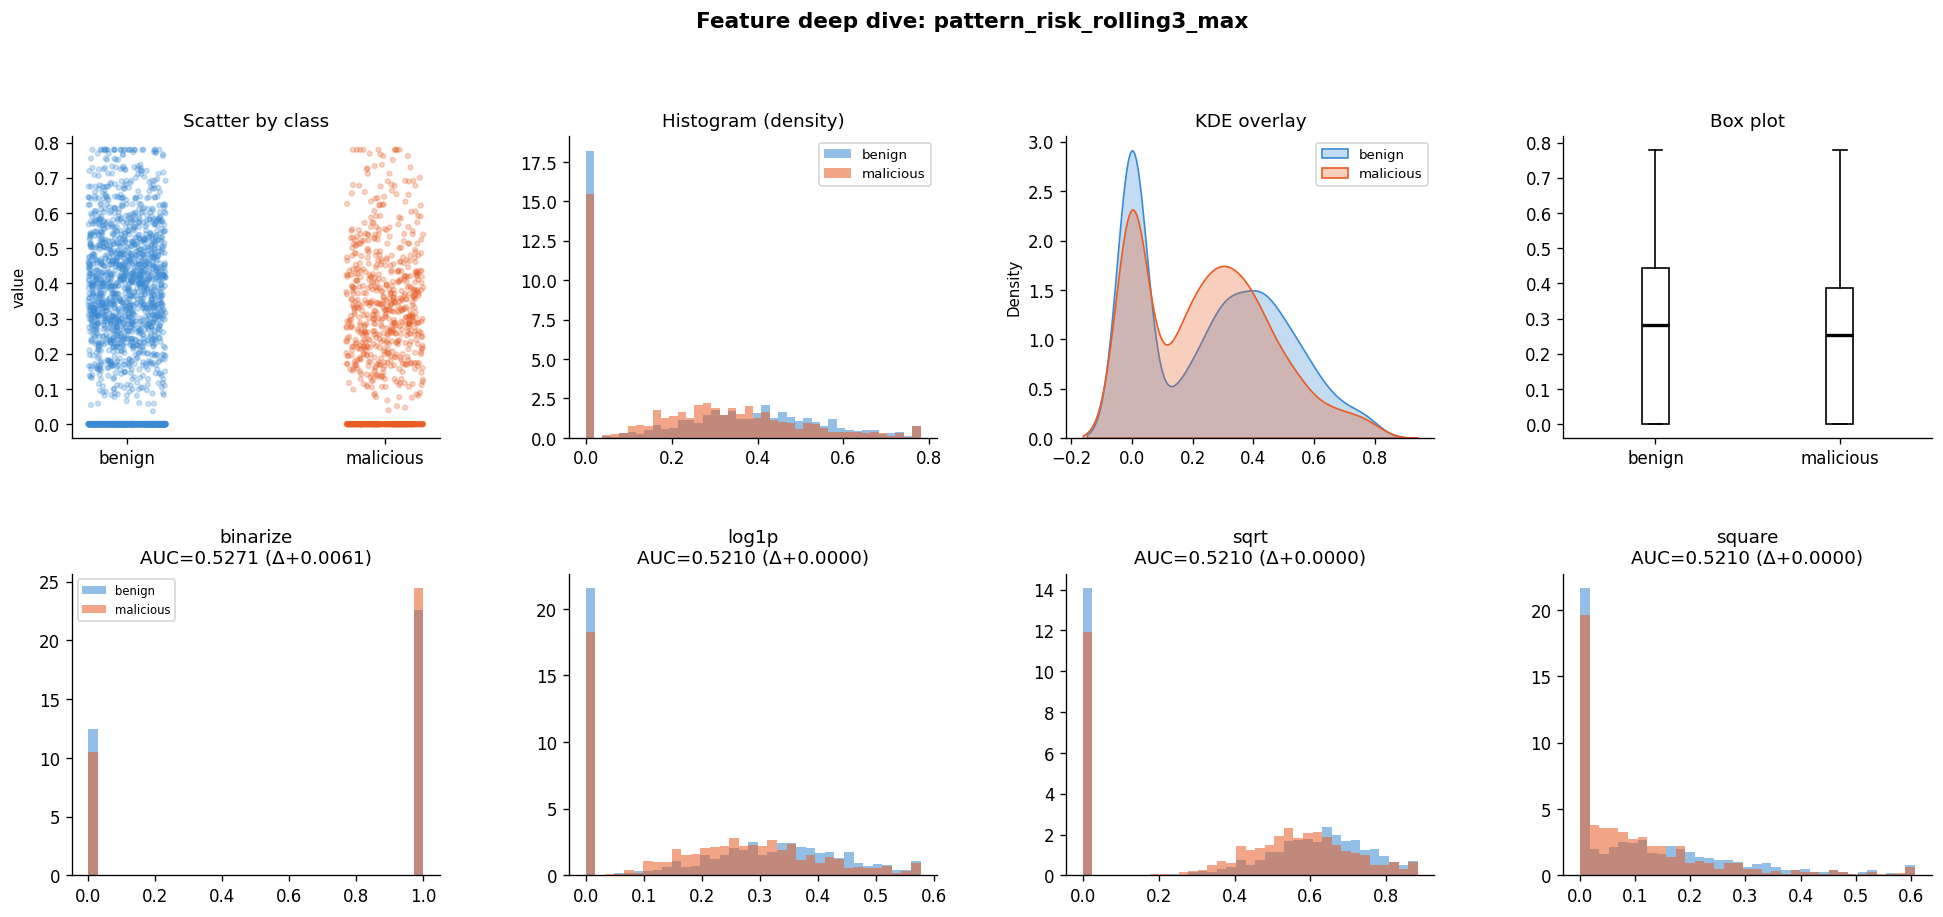

FEATURE: pattern_risk_rolling3_max
  Raw AUC         : 0.5210
  Skewness        : 0.317  (low)
  Zeros           : 34.0%
  KS stat / p     : 0.0969 / 0.00001
  Mean benign     : 0.2620   malicious: 0.2453
  Best transform  : binarize  →  AUC=0.5271  KS=0.0541
  Verdict         : WEAK
  All transforms (sorted by AUC):
    binarize        AUC=0.5271  Δ=+0.0061  KS=0.0541
    log1p           AUC=0.5210  Δ=+0.0000  KS=0.0969
    sqrt            AUC=0.5210  Δ=+0.0000  KS=0.0969
    square          AUC=0.5210  Δ=+0.0000  KS=0.0969
    yeo-johnson     AUC=0.5210  Δ=+0.0000  KS=0.0969
    quantile        AUC=0.5210  Δ=+0.0000  KS=0.0969
    rank            AUC=0.5210  Δ=+0.0000  KS=0.0969


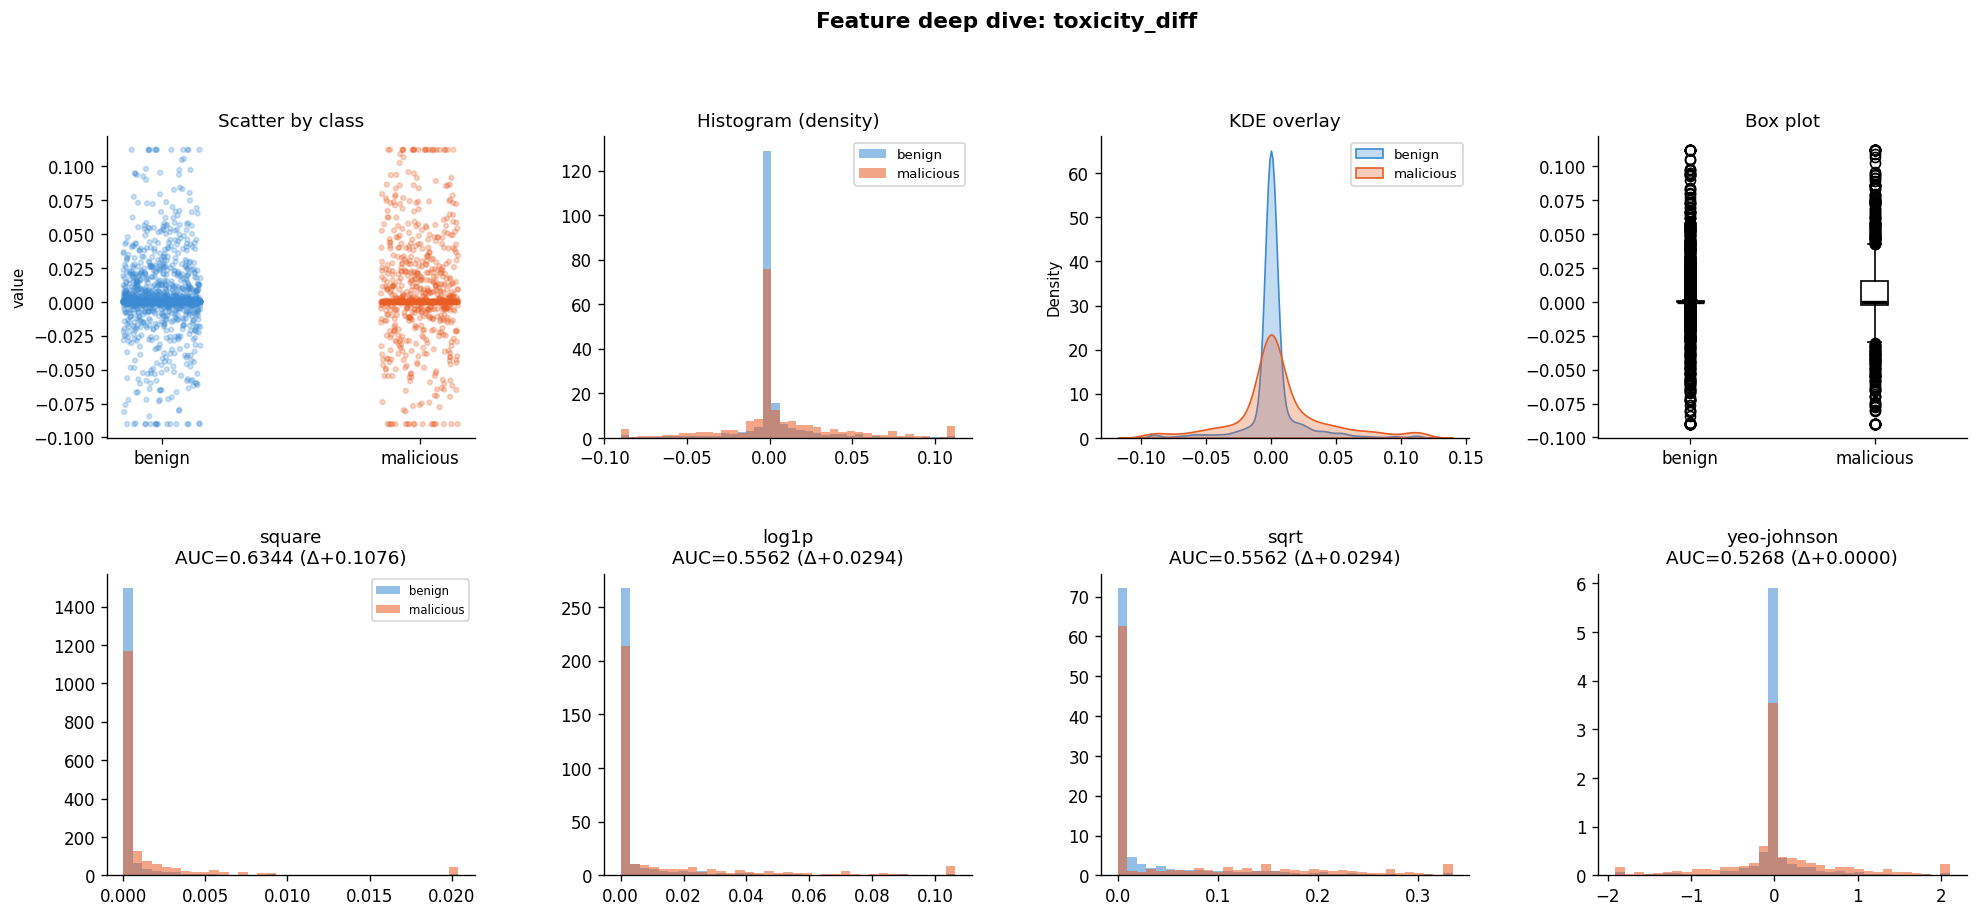

FEATURE: toxicity_diff
  Raw AUC         : 0.5268
  Skewness        : 5.143  (high)
  Zeros           : 34.0%
  KS stat / p     : 0.1656 / 0.00000
  Mean benign     : 0.0017   malicious: 0.0087
  Best transform  : square  →  AUC=0.6344  KS=0.2916
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    square          AUC=0.6344  Δ=+0.1076  KS=0.2916
    log1p           AUC=0.5562  Δ=+0.0294  KS=0.1656
    sqrt            AUC=0.5562  Δ=+0.0294  KS=0.1656
    yeo-johnson     AUC=0.5268  Δ=+0.0000  KS=0.1656
    quantile        AUC=0.5268  Δ=+0.0000  KS=0.1656
    rank            AUC=0.5268  Δ=+0.0000  KS=0.1656
    binarize        AUC=0.5210  Δ=-0.0058  KS=0.0420


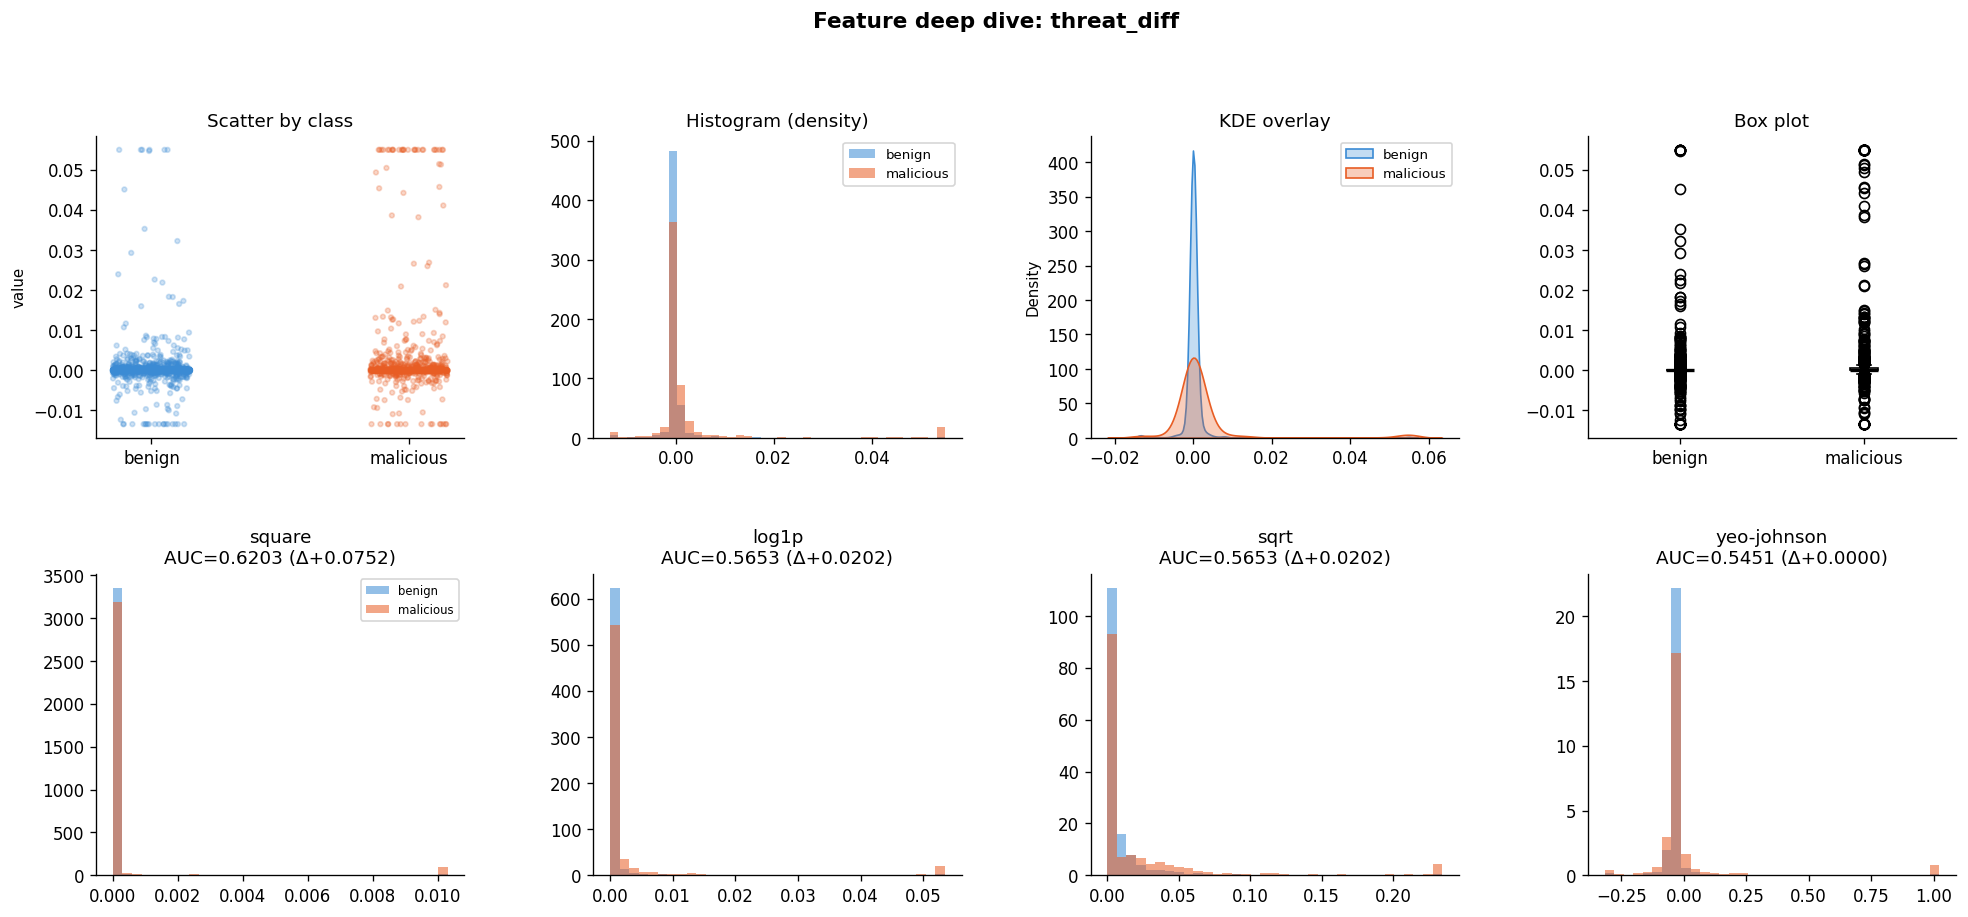

FEATURE: threat_diff
  Raw AUC         : 0.5451
  Skewness        : 9.041  (high)
  Zeros           : 34.0%
  KS stat / p     : 0.1792 / 0.00000
  Mean benign     : 0.0001   malicious: 0.0140
  Best transform  : square  →  AUC=0.6203  KS=0.2489
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    square          AUC=0.6203  Δ=+0.0752  KS=0.2489
    log1p           AUC=0.5653  Δ=+0.0202  KS=0.1792
    sqrt            AUC=0.5653  Δ=+0.0202  KS=0.1792
    yeo-johnson     AUC=0.5451  Δ=+0.0000  KS=0.1792
    quantile        AUC=0.5451  Δ=+0.0000  KS=0.1792
    rank            AUC=0.5451  Δ=+0.0000  KS=0.1792
    binarize        AUC=0.5308  Δ=-0.0143  KS=0.0616


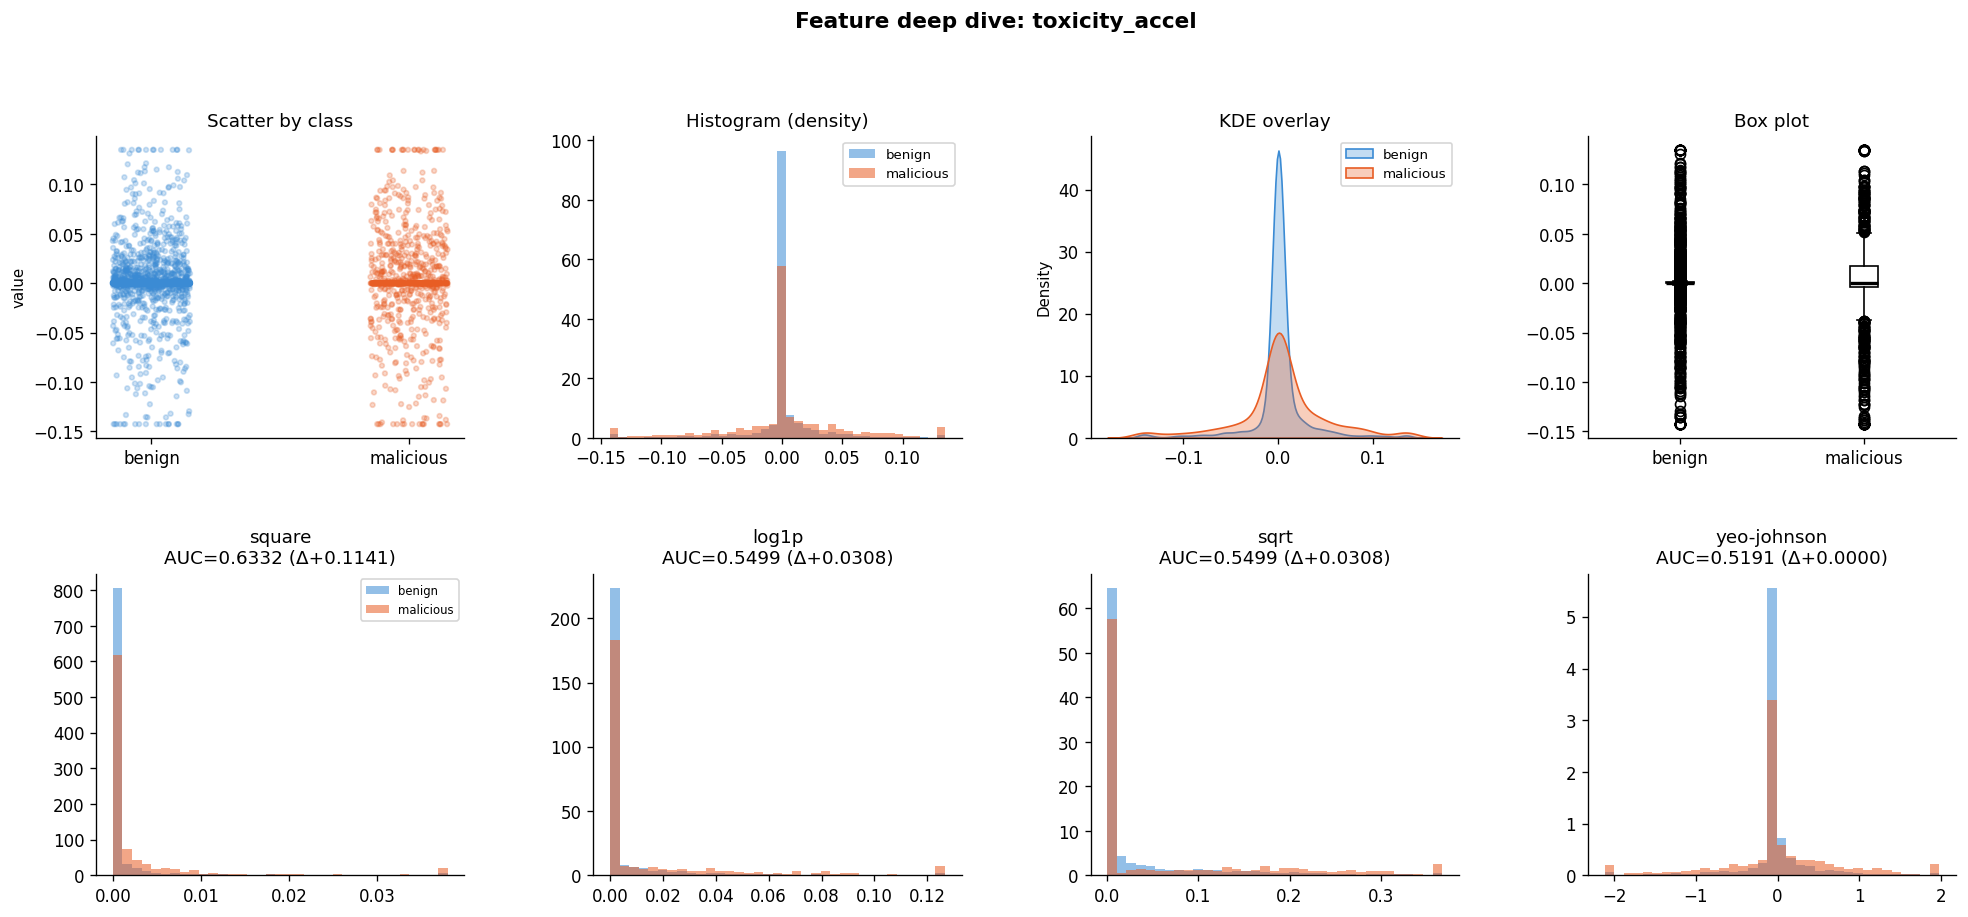

FEATURE: toxicity_accel
  Raw AUC         : 0.5191
  Skewness        : -2.381  (high)
  Zeros           : 34.0%
  KS stat / p     : 0.1559 / 0.00000
  Mean benign     : 0.0006   malicious: 0.0053
  Best transform  : square  →  AUC=0.6332  KS=0.2763
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    square          AUC=0.6332  Δ=+0.1141  KS=0.2763
    log1p           AUC=0.5499  Δ=+0.0308  KS=0.1559
    sqrt            AUC=0.5499  Δ=+0.0308  KS=0.1559
    yeo-johnson     AUC=0.5191  Δ=+0.0000  KS=0.1559
    quantile        AUC=0.5191  Δ=+0.0000  KS=0.1559
    rank            AUC=0.5191  Δ=+0.0000  KS=0.1559
    binarize        AUC=0.5148  Δ=-0.0043  KS=0.0296


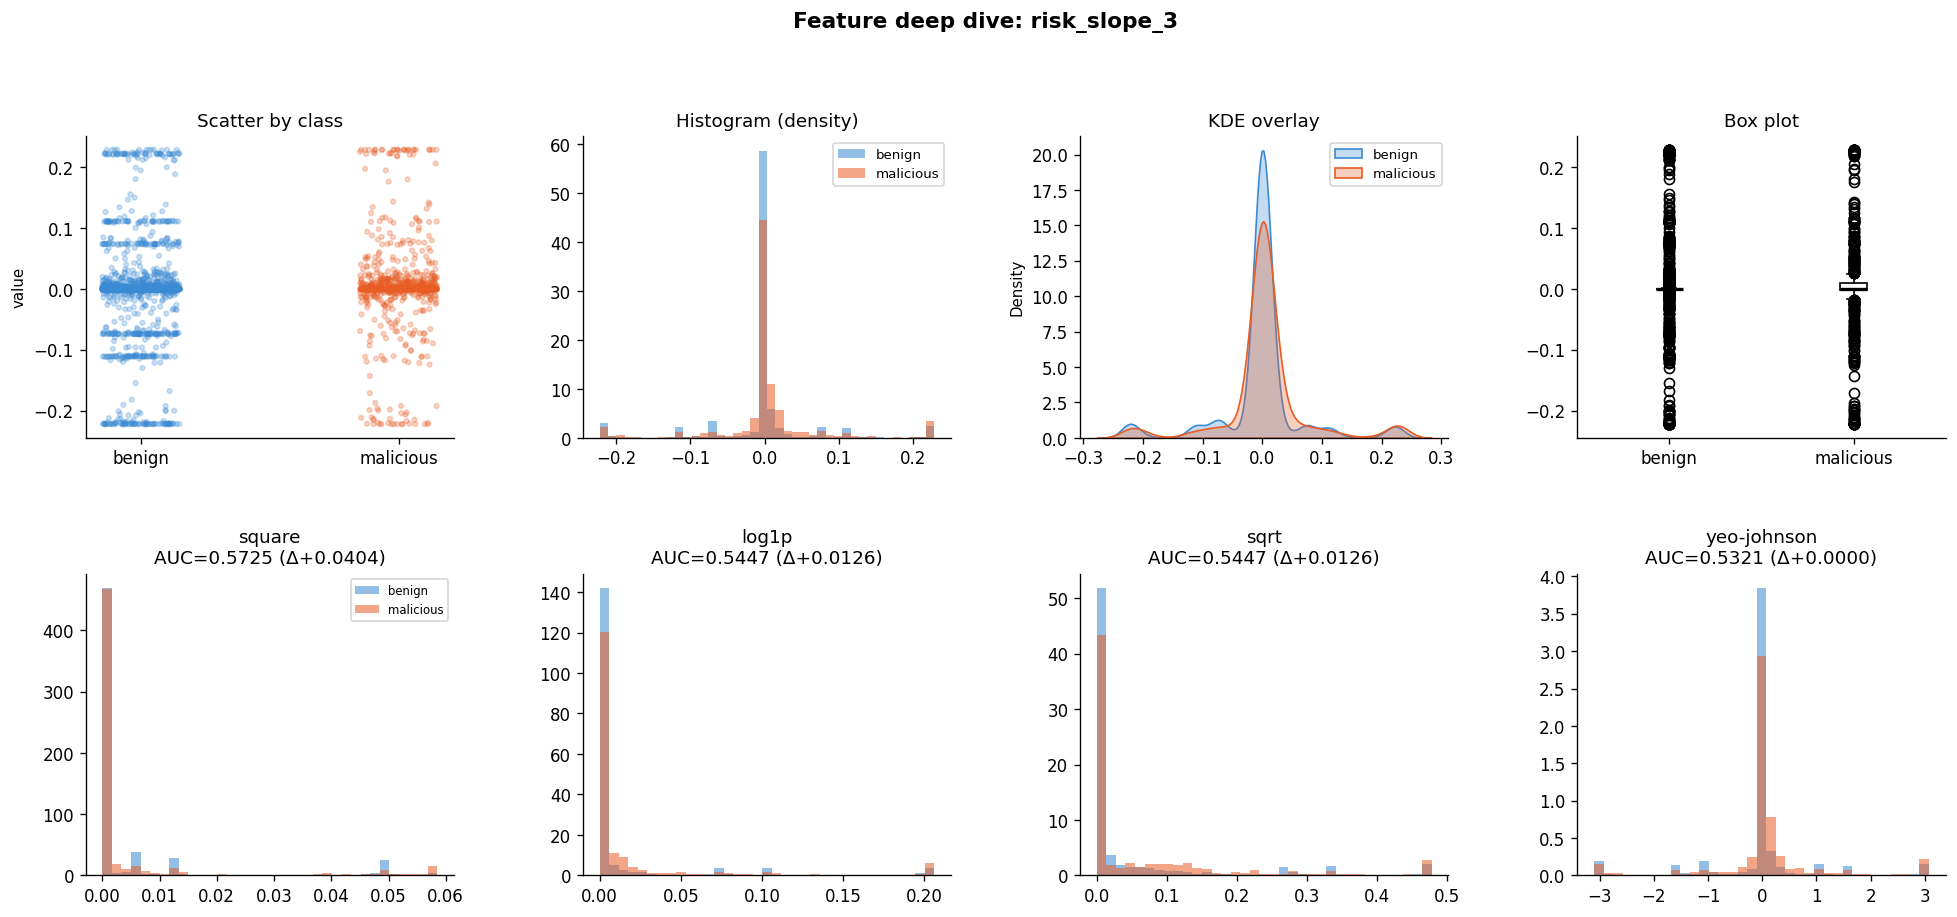

FEATURE: risk_slope_3
  Raw AUC         : 0.5321
  Skewness        : 0.215  (low)
  Zeros           : 34.0%
  KS stat / p     : 0.1501 / 0.00000
  Mean benign     : -0.0025   malicious: 0.0055
  Best transform  : square  →  AUC=0.5725  KS=0.2199
  Verdict         : WEAK
  All transforms (sorted by AUC):
    square          AUC=0.5725  Δ=+0.0404  KS=0.2199
    log1p           AUC=0.5447  Δ=+0.0126  KS=0.1501
    sqrt            AUC=0.5447  Δ=+0.0126  KS=0.1501
    yeo-johnson     AUC=0.5321  Δ=+0.0000  KS=0.1501
    quantile        AUC=0.5321  Δ=+0.0000  KS=0.1501
    rank            AUC=0.5321  Δ=+0.0000  KS=0.1501
    binarize        AUC=0.5226  Δ=-0.0095  KS=0.0451


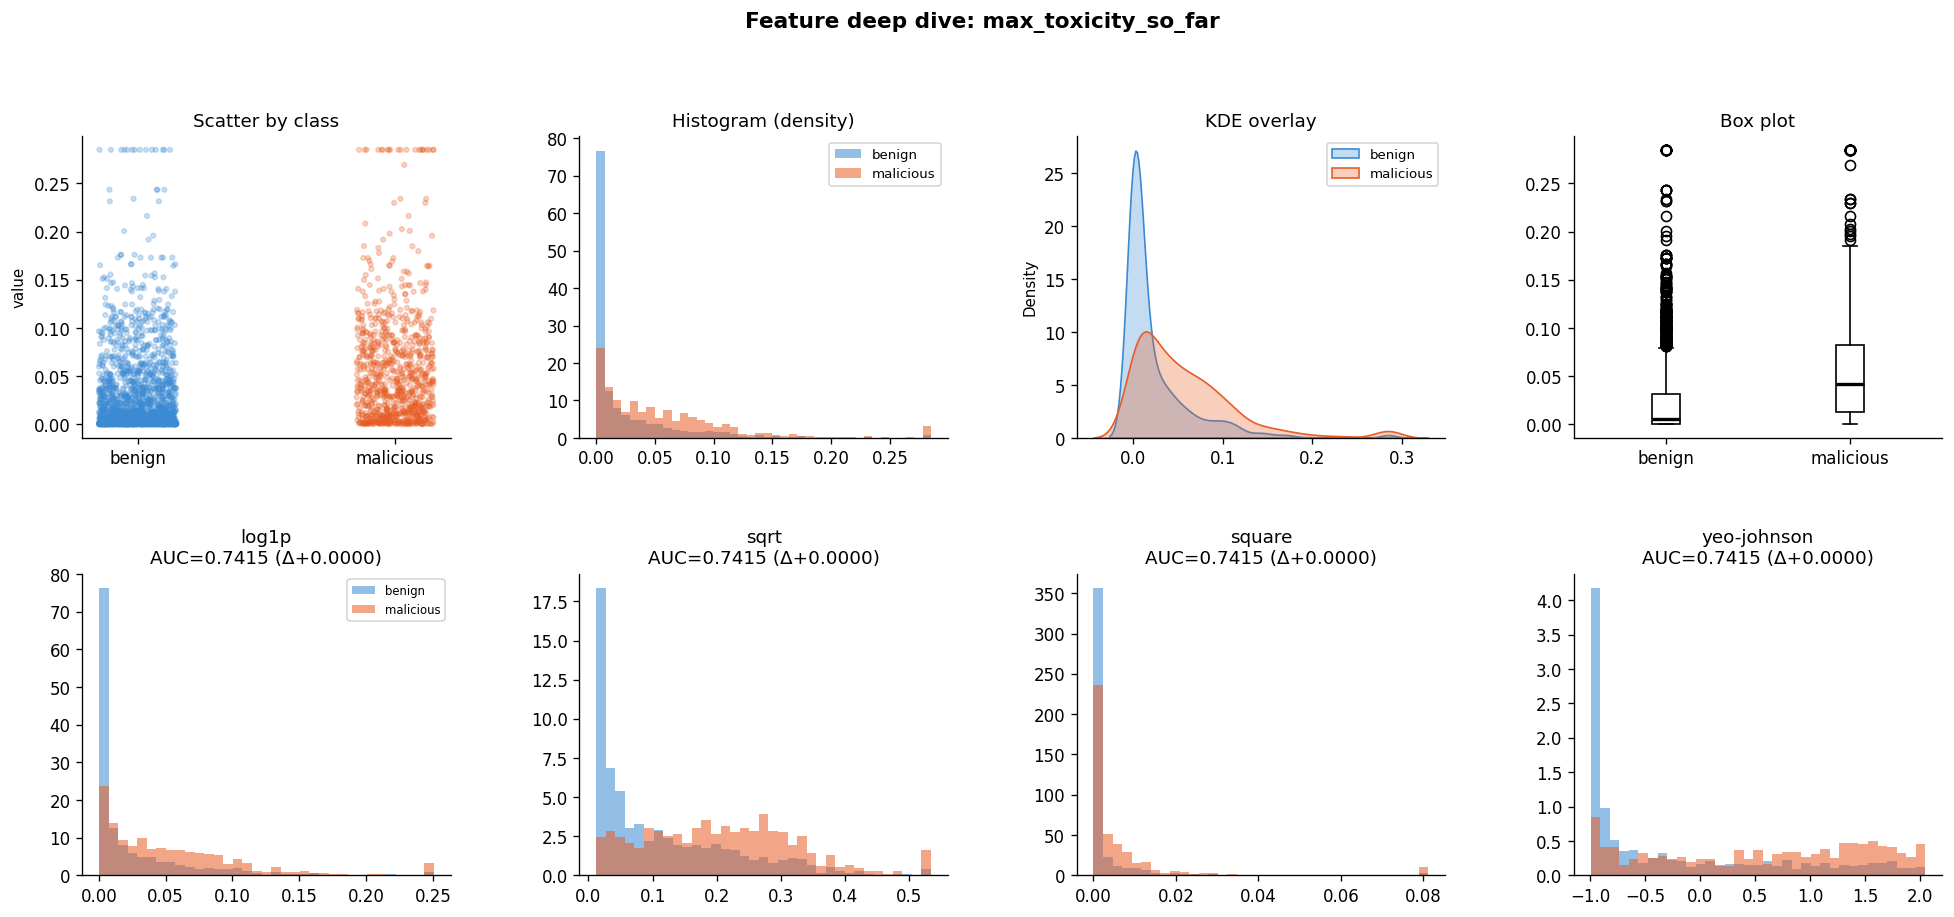

FEATURE: max_toxicity_so_far
  Raw AUC         : 0.7415
  Skewness        : 7.05  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3795 / 0.00000
  Mean benign     : 0.0261   malicious: 0.0627
  Best transform  : log1p  →  AUC=0.7415  KS=0.3795
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7415  Δ=+0.0000  KS=0.3795
    sqrt            AUC=0.7415  Δ=+0.0000  KS=0.3795
    square          AUC=0.7415  Δ=+0.0000  KS=0.3795
    yeo-johnson     AUC=0.7415  Δ=+0.0000  KS=0.3795
    quantile        AUC=0.7415  Δ=+0.0000  KS=0.3795
    rank            AUC=0.7415  Δ=+0.0000  KS=0.3795
    binarize        AUC=0.5000  Δ=-0.2415  KS=0.0000


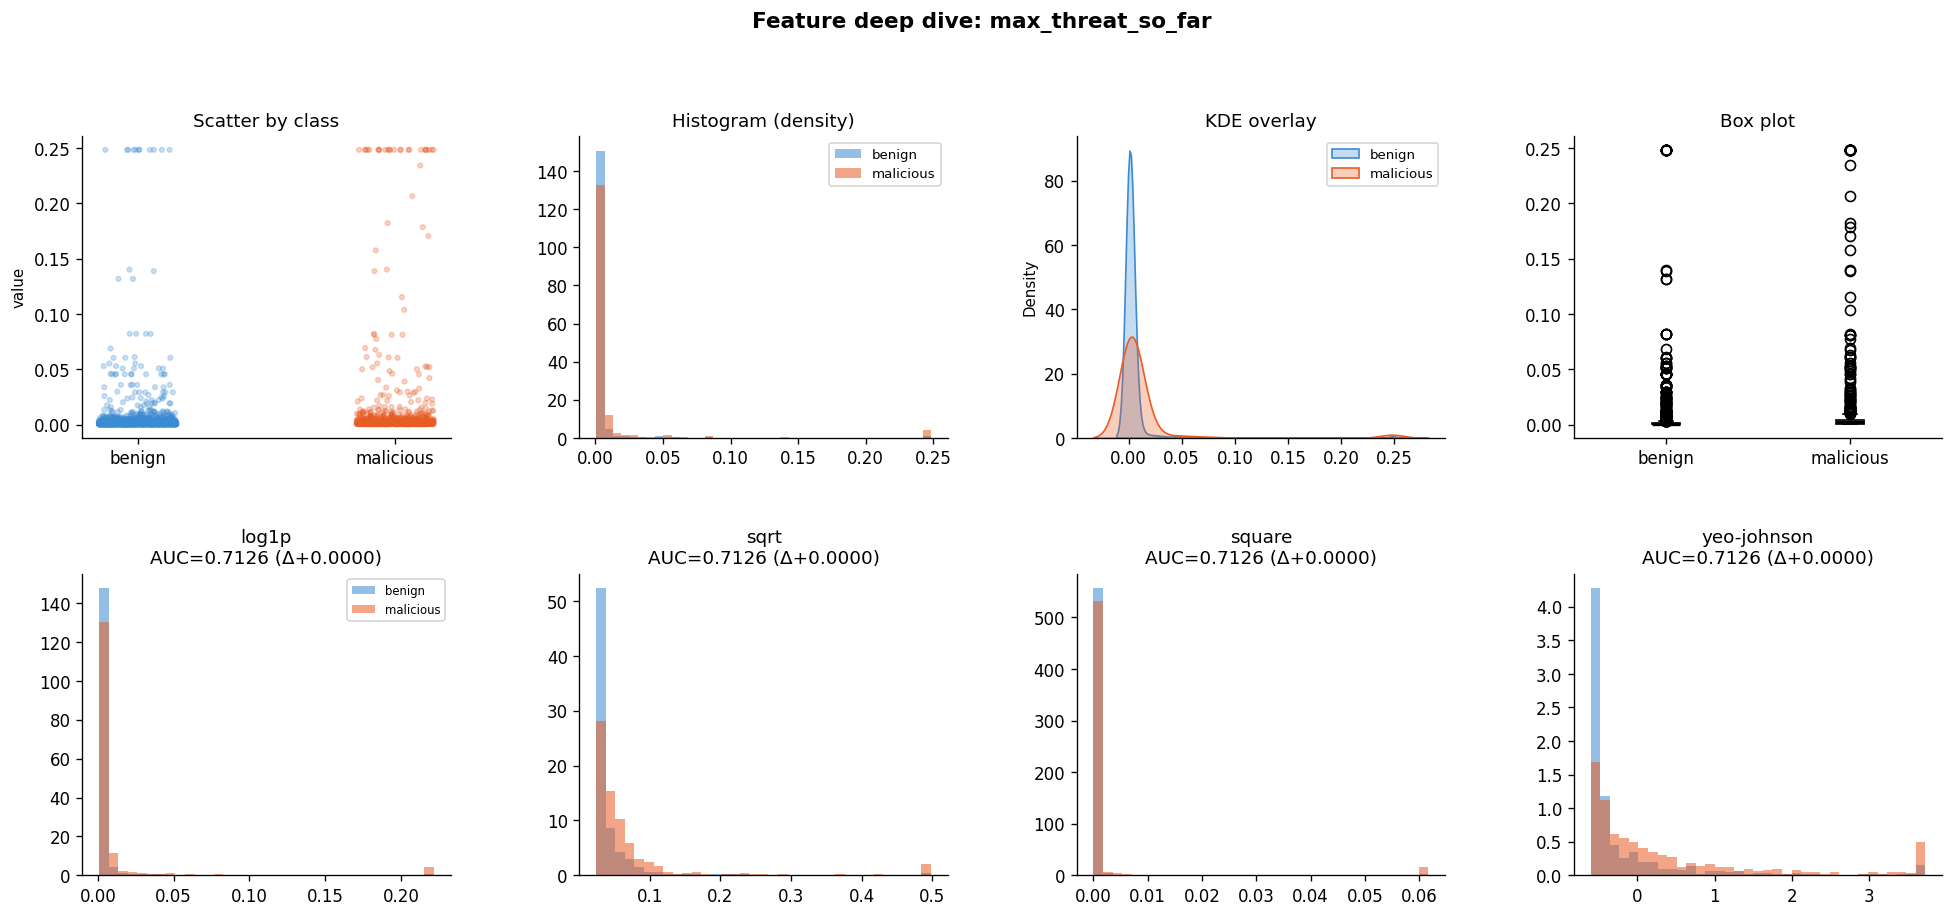

FEATURE: max_threat_so_far
  Raw AUC         : 0.7126
  Skewness        : 10.339  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.3493 / 0.00000
  Mean benign     : 0.0054   malicious: 0.0253
  Best transform  : log1p  →  AUC=0.7126  KS=0.3493
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.7126  Δ=+0.0000  KS=0.3493
    sqrt            AUC=0.7126  Δ=+0.0000  KS=0.3493
    square          AUC=0.7126  Δ=+0.0000  KS=0.3493
    yeo-johnson     AUC=0.7126  Δ=+0.0000  KS=0.3493
    quantile        AUC=0.7126  Δ=+0.0000  KS=0.3493
    rank            AUC=0.7126  Δ=+0.0000  KS=0.3493
    binarize        AUC=0.5000  Δ=-0.2126  KS=0.0000


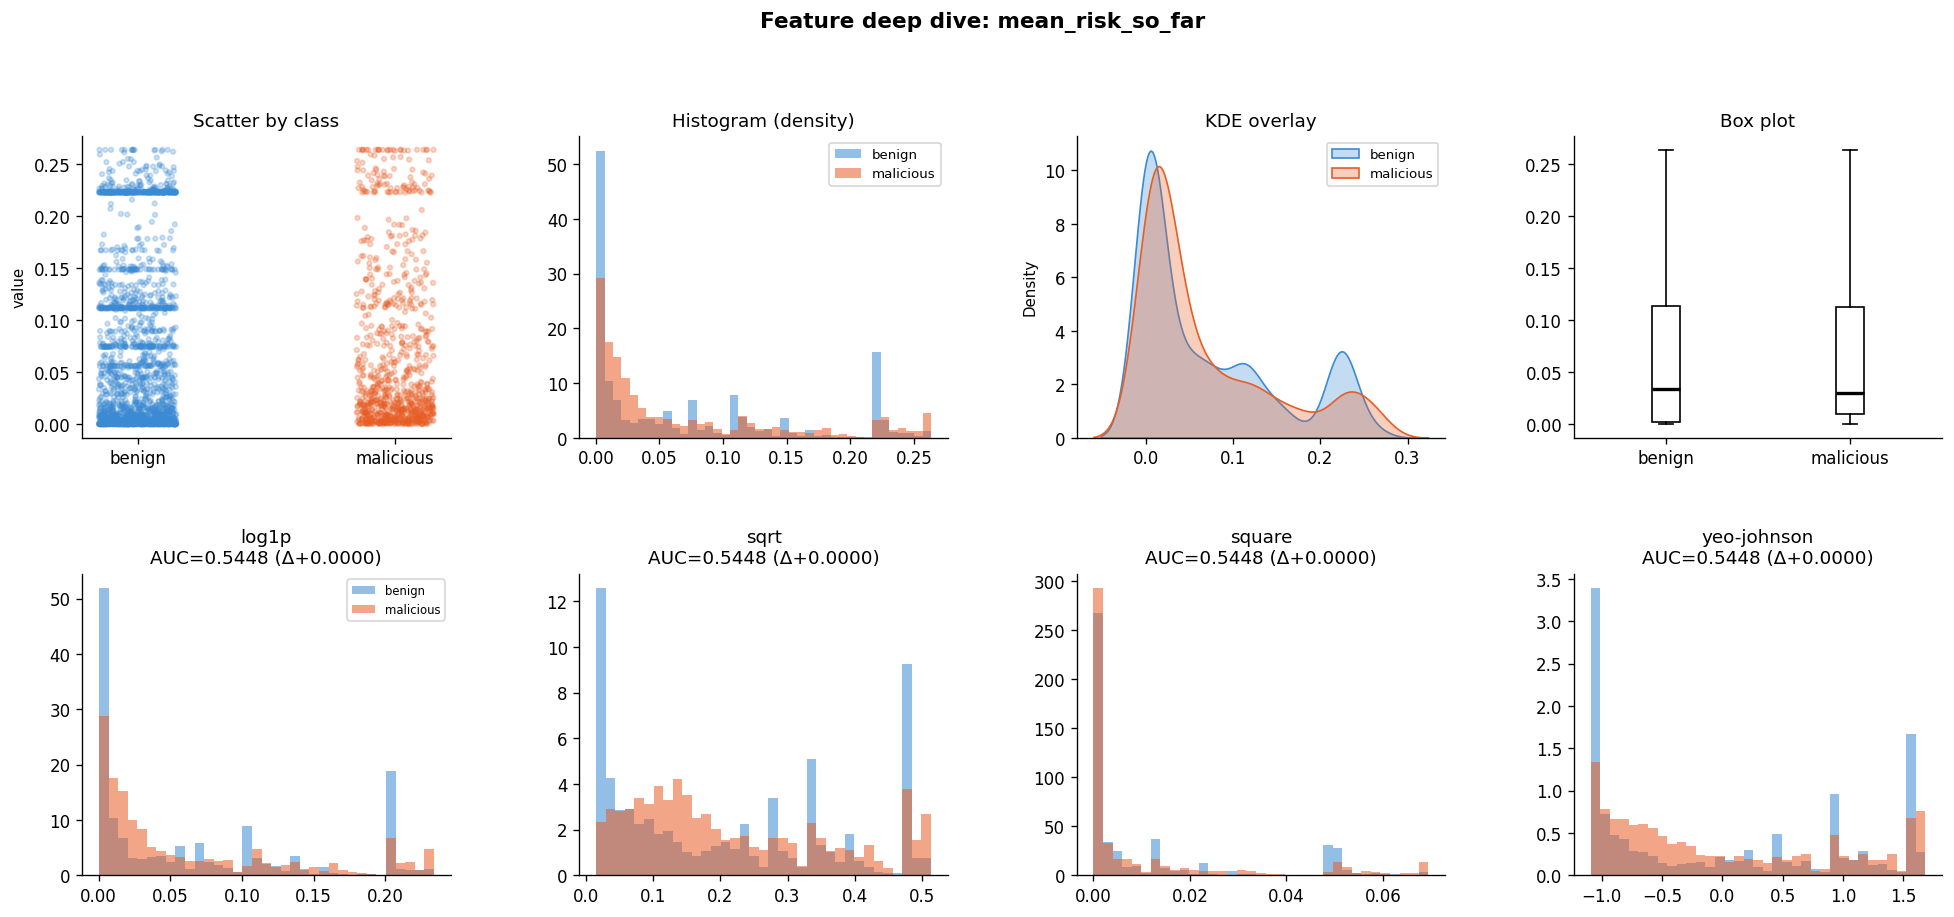

FEATURE: mean_risk_so_far
  Raw AUC         : 0.5448
  Skewness        : 1.291  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.1756 / 0.00000
  Mean benign     : 0.0712   malicious: 0.0698
  Best transform  : log1p  →  AUC=0.5448  KS=0.1756
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5448  Δ=+0.0000  KS=0.1756
    sqrt            AUC=0.5448  Δ=+0.0000  KS=0.1756
    square          AUC=0.5448  Δ=+0.0000  KS=0.1756
    yeo-johnson     AUC=0.5448  Δ=+0.0000  KS=0.1756
    quantile        AUC=0.5448  Δ=+0.0000  KS=0.1756
    rank            AUC=0.5448  Δ=+0.0000  KS=0.1756
    binarize        AUC=0.5000  Δ=-0.0448  KS=0.0000


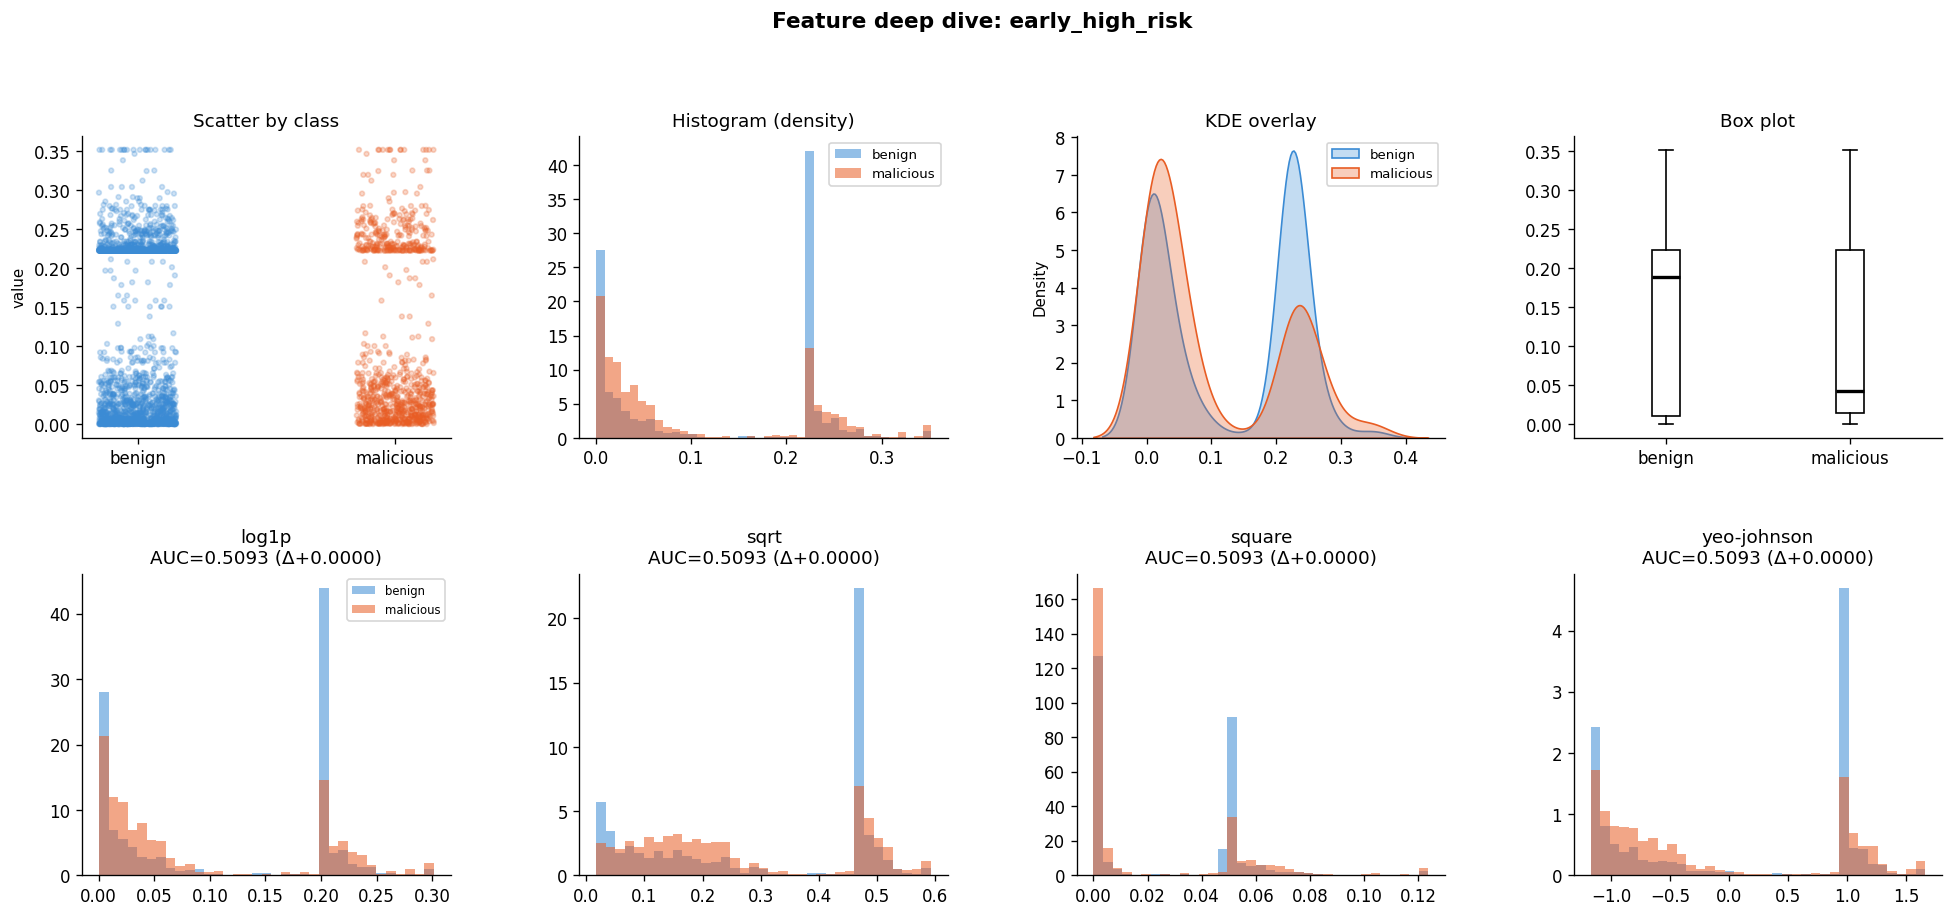

FEATURE: early_high_risk
  Raw AUC         : 0.5093
  Skewness        : 0.918  (moderate)
  Zeros           : 0.0%
  KS stat / p     : 0.1821 / 0.00000
  Mean benign     : 0.1290   malicious: 0.1036
  Best transform  : log1p  →  AUC=0.5093  KS=0.1821
  Verdict         : NOISE
  All transforms (sorted by AUC):
    log1p           AUC=0.5093  Δ=+0.0000  KS=0.1821
    sqrt            AUC=0.5093  Δ=+0.0000  KS=0.1821
    square          AUC=0.5093  Δ=+0.0000  KS=0.1821
    yeo-johnson     AUC=0.5093  Δ=+0.0000  KS=0.1821
    quantile        AUC=0.5093  Δ=+0.0000  KS=0.1821
    rank            AUC=0.5093  Δ=+0.0000  KS=0.1821
    binarize        AUC=0.5000  Δ=-0.0093  KS=0.0000


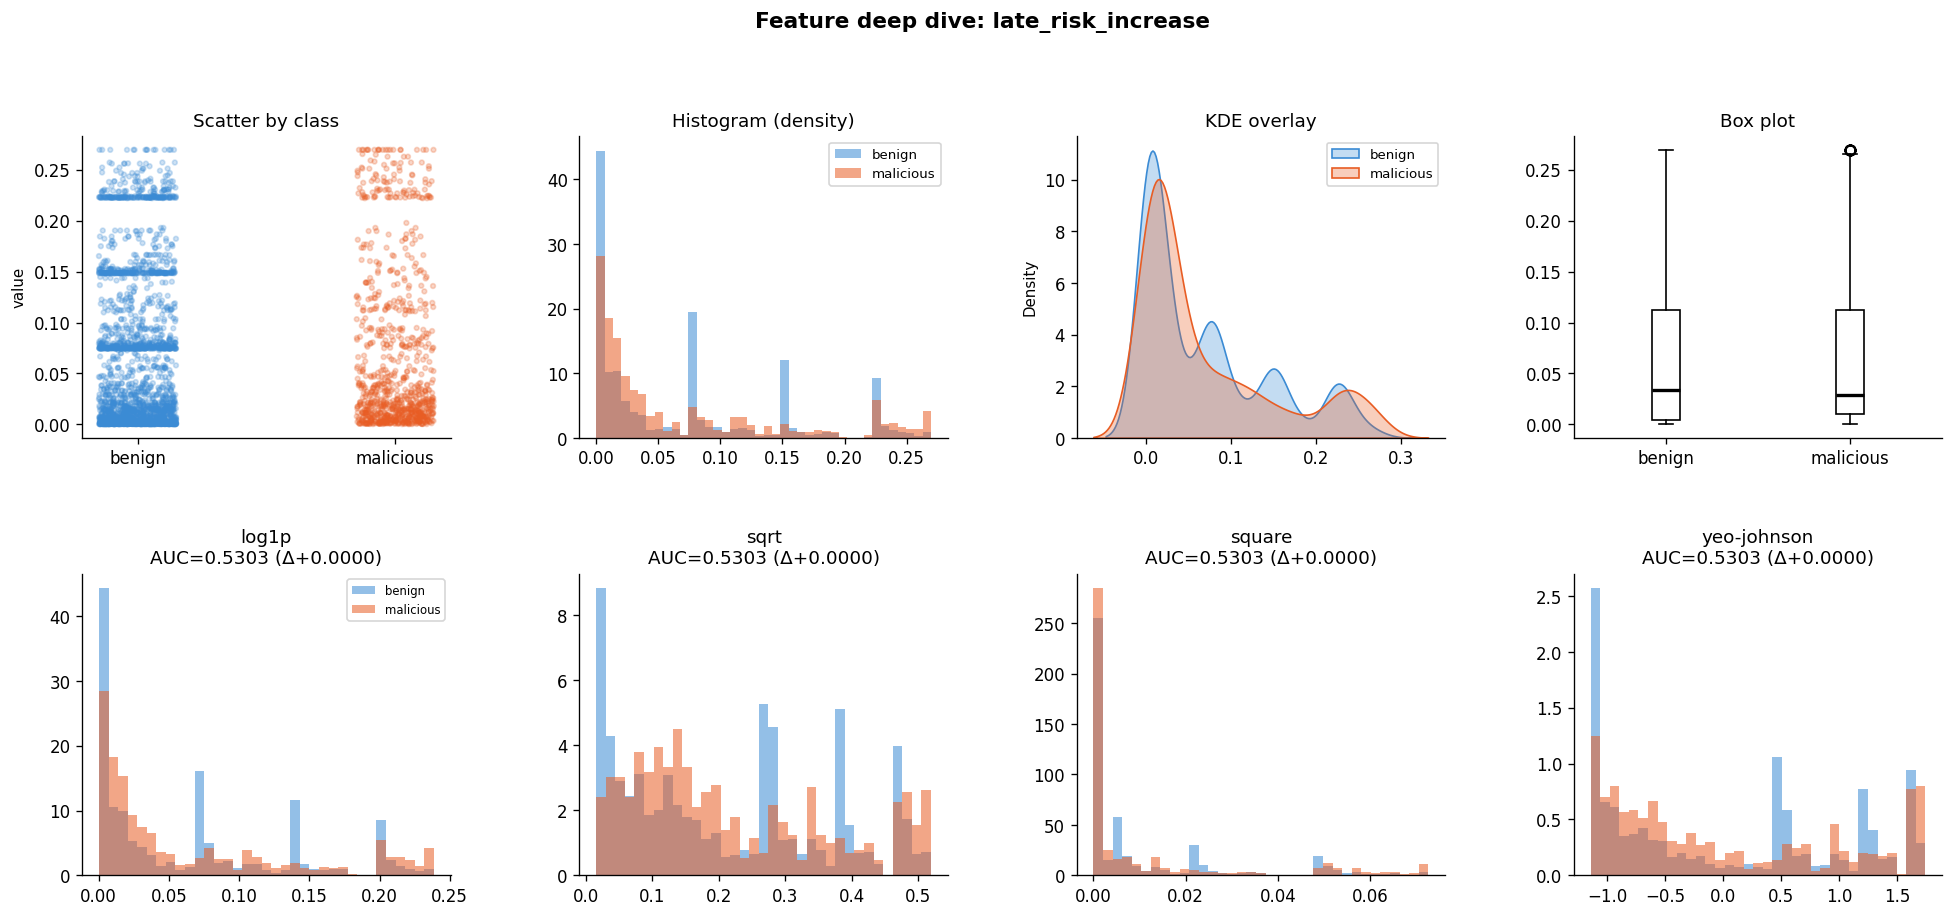

FEATURE: late_risk_increase
  Raw AUC         : 0.5303
  Skewness        : 1.355  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.1178 / 0.00000
  Mean benign     : 0.0685   malicious: 0.0712
  Best transform  : log1p  →  AUC=0.5303  KS=0.1178
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5303  Δ=+0.0000  KS=0.1178
    sqrt            AUC=0.5303  Δ=+0.0000  KS=0.1178
    square          AUC=0.5303  Δ=+0.0000  KS=0.1178
    yeo-johnson     AUC=0.5303  Δ=+0.0000  KS=0.1178
    quantile        AUC=0.5303  Δ=+0.0000  KS=0.1178
    rank            AUC=0.5303  Δ=+0.0000  KS=0.1178
    binarize        AUC=0.5000  Δ=-0.0303  KS=0.0000


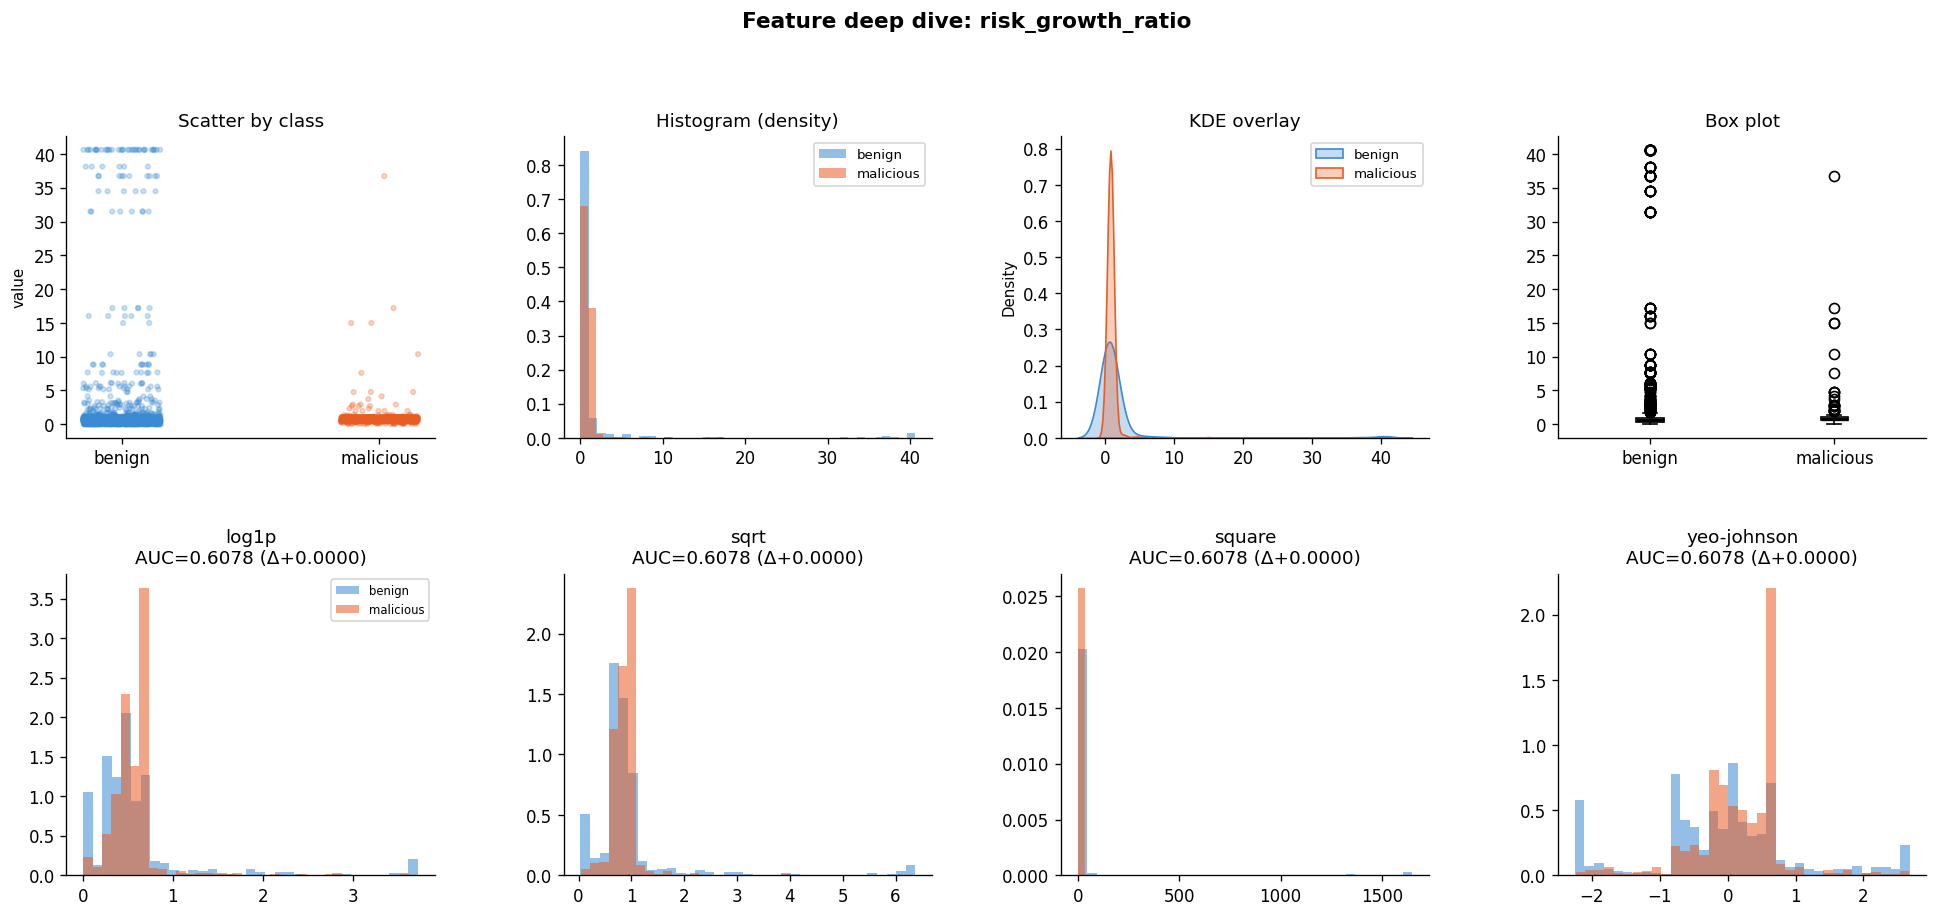

FEATURE: risk_growth_ratio
  Raw AUC         : 0.6078
  Skewness        : 11.954  (high)
  Zeros           : 0.0%
  KS stat / p     : 0.2243 / 0.00000
  Mean benign     : 2.7361   malicious: 0.8882
  Best transform  : log1p  →  AUC=0.6078  KS=0.2243
  Verdict         : USEFUL
  All transforms (sorted by AUC):
    log1p           AUC=0.6078  Δ=+0.0000  KS=0.2243
    sqrt            AUC=0.6078  Δ=+0.0000  KS=0.2243
    square          AUC=0.6078  Δ=+0.0000  KS=0.2243
    yeo-johnson     AUC=0.6078  Δ=+0.0000  KS=0.2243
    quantile        AUC=0.6078  Δ=+0.0000  KS=0.2243
    rank            AUC=0.6078  Δ=+0.0000  KS=0.2243
    binarize        AUC=0.5000  Δ=-0.1078  KS=0.0000


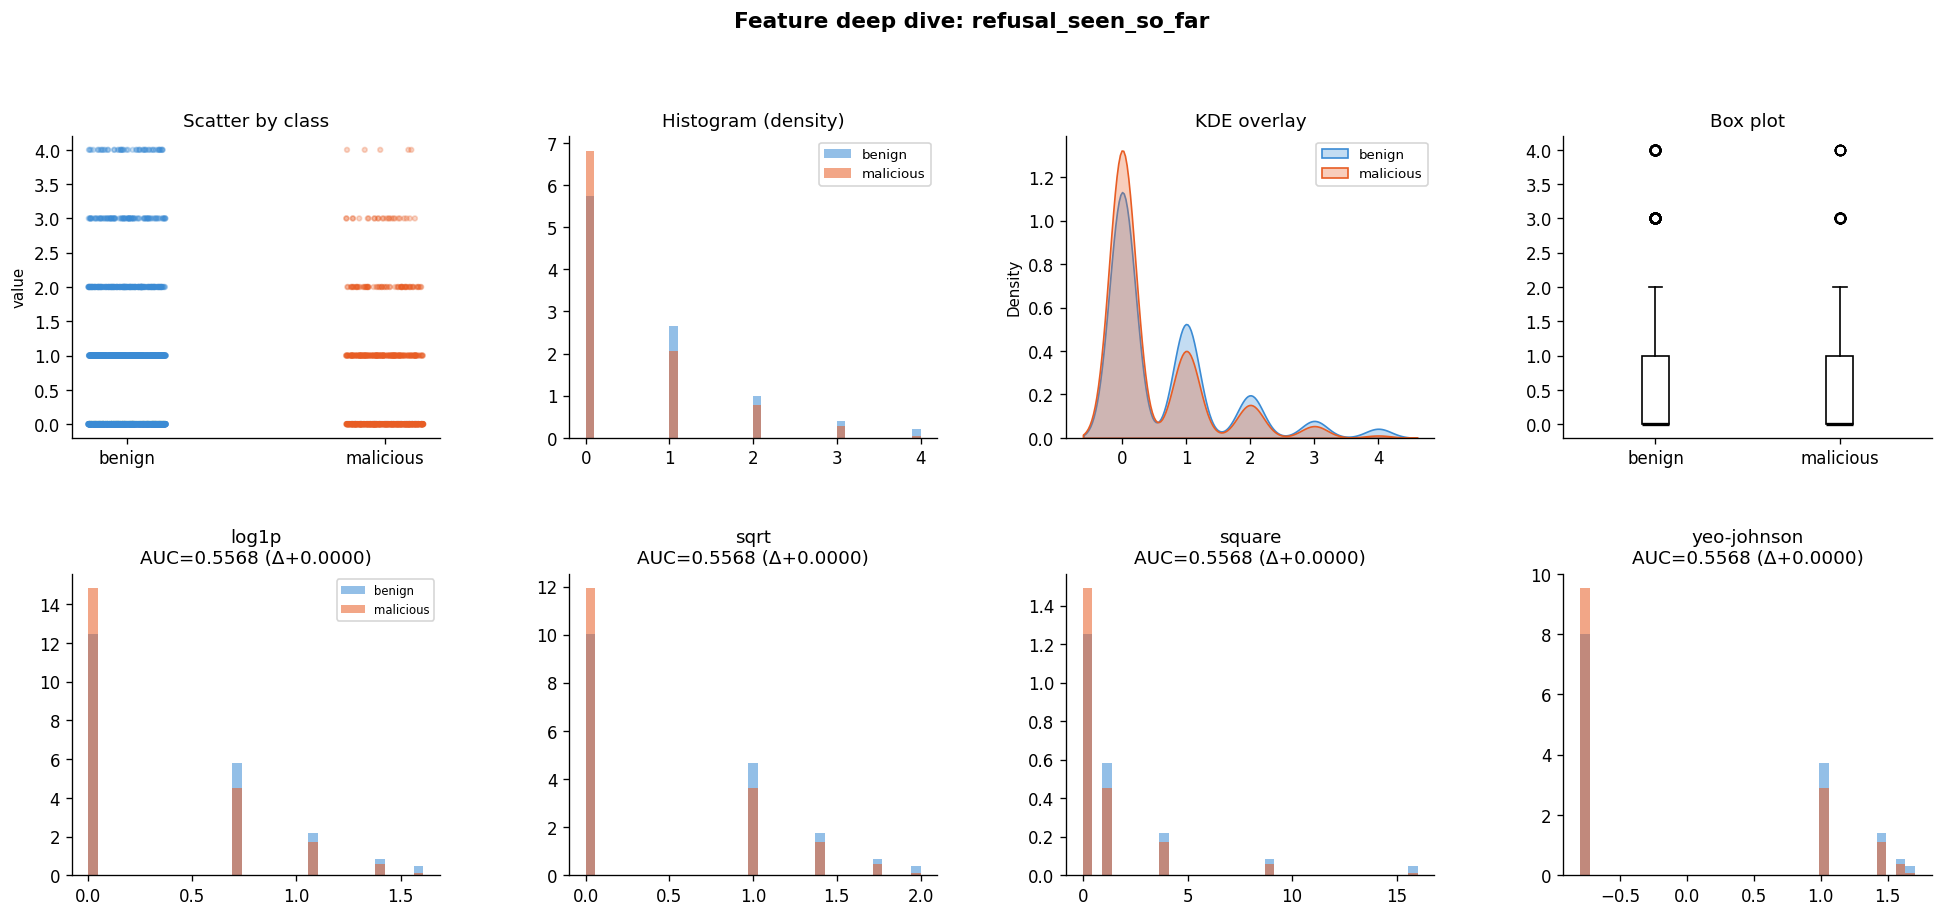

FEATURE: refusal_seen_so_far
  Raw AUC         : 0.5568
  Skewness        : 1.941  (high)
  Zeros           : 60.4%
  KS stat / p     : 0.1084 / 0.00000
  Mean benign     : 0.6788   malicious: 0.4705
  Best transform  : log1p  →  AUC=0.5568  KS=0.1084
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5568  Δ=+0.0000  KS=0.1084
    sqrt            AUC=0.5568  Δ=+0.0000  KS=0.1084
    square          AUC=0.5568  Δ=+0.0000  KS=0.1084
    yeo-johnson     AUC=0.5568  Δ=+0.0000  KS=0.1084
    quantile        AUC=0.5568  Δ=+0.0000  KS=0.1084
    rank            AUC=0.5568  Δ=+0.0000  KS=0.1084
    binarize        AUC=0.5542  Δ=-0.0026  KS=0.1084


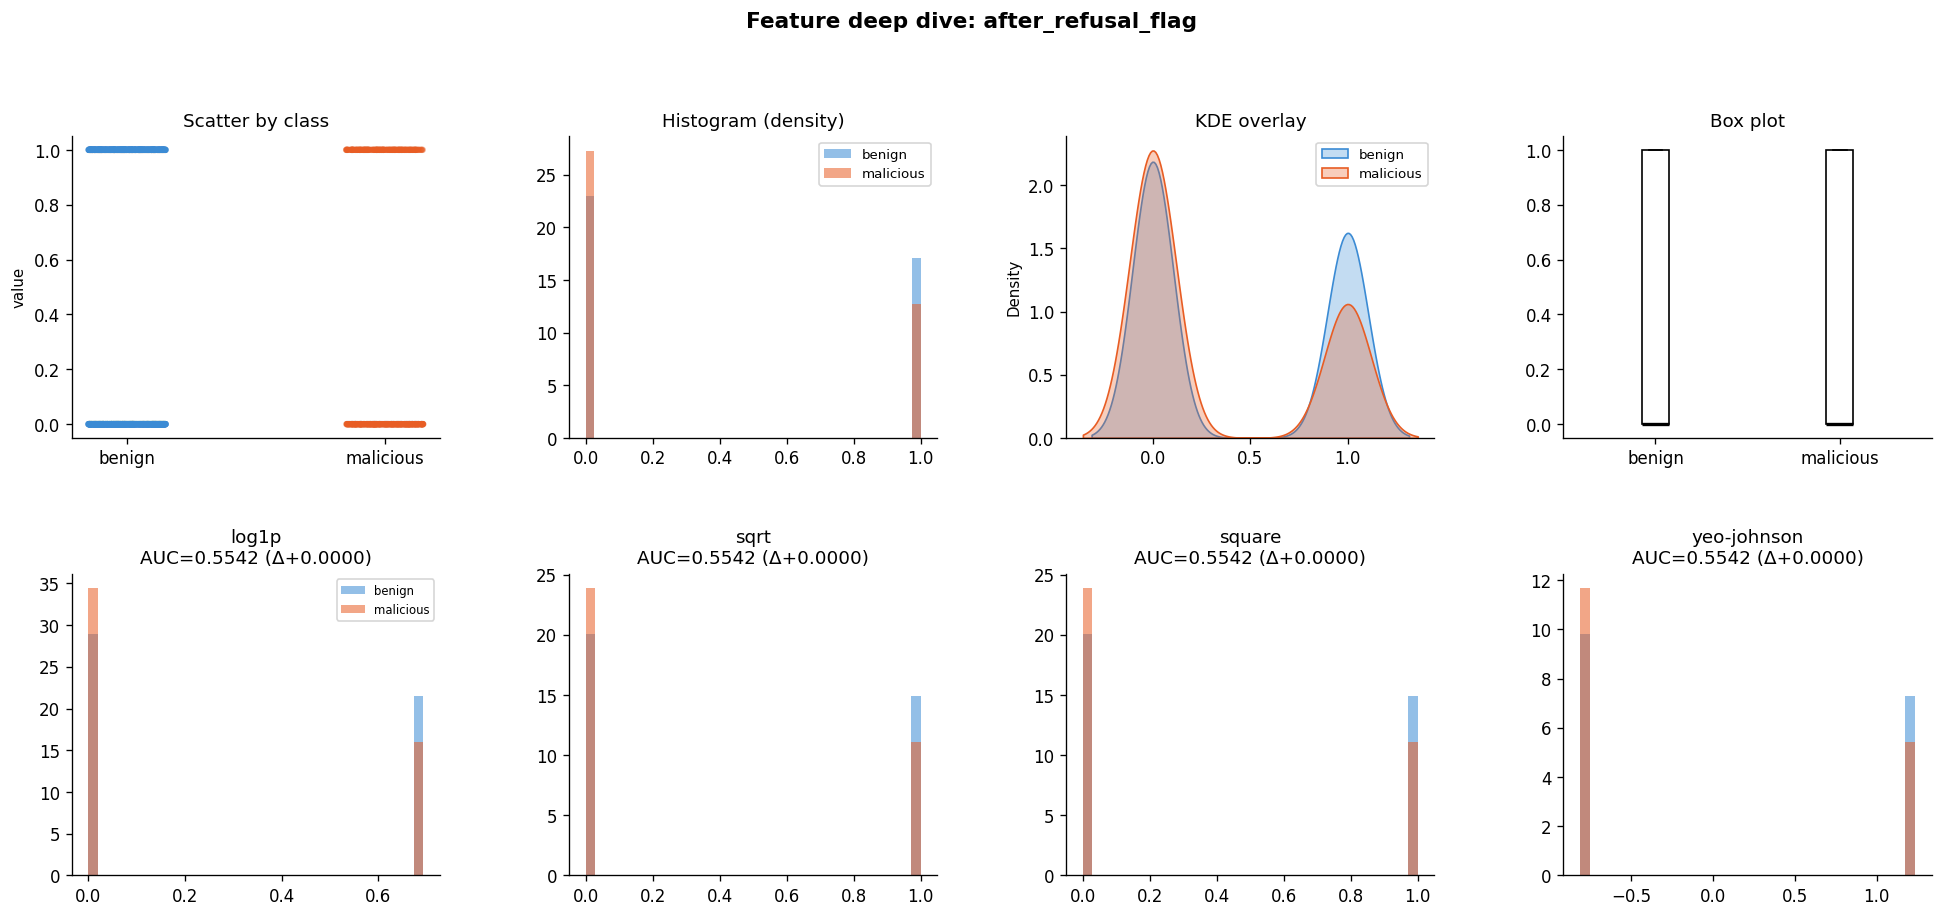

FEATURE: after_refusal_flag
  Raw AUC         : 0.5542
  Skewness        : 0.425  (low)
  Zeros           : 60.4%
  KS stat / p     : 0.1084 / 0.00000
  Mean benign     : 0.4261   malicious: 0.3177
  Best transform  : log1p  →  AUC=0.5542  KS=0.1084
  Verdict         : WEAK
  All transforms (sorted by AUC):
    log1p           AUC=0.5542  Δ=+0.0000  KS=0.1084
    sqrt            AUC=0.5542  Δ=+0.0000  KS=0.1084
    square          AUC=0.5542  Δ=+0.0000  KS=0.1084
    yeo-johnson     AUC=0.5542  Δ=+0.0000  KS=0.1084
    quantile        AUC=0.5542  Δ=+0.0000  KS=0.1084
    rank            AUC=0.5542  Δ=+0.0000  KS=0.1084
    binarize        AUC=0.5542  Δ=+0.0000  KS=0.1084


In [59]:
def clip_outliers(s, pct=99):
    """Clip to [1st, pct] percentile for display only."""
    lo, hi = np.percentile(s, 1), np.percentile(s, pct)
    return np.clip(s, lo, hi)

def compute_separability(raw, transformed, y):
    """AUC + KS stat for raw and transformed versions."""
    results = {}
    for name, arr in [('raw', raw), ('transformed', transformed)]:
        try:
            auc = roc_auc_score(y, arr)
            auc = max(auc, 1-auc)
        except:
            auc = np.nan
        ks, ksp = ks_2samp(arr[y==0], arr[y==1])
        results[name] = {'AUC': round(auc,4), 'KS': round(ks,4), 'KS_p': round(ksp,5)}
    return results

TRANSFORMS = {
    'log1p'     : lambda x: np.log1p(np.clip(x, 0, None)),
    'sqrt'      : lambda x: np.sqrt(np.clip(x, 0, None)),
    'square'    : lambda x: x**2,
    'yeo-johnson': lambda x: PowerTransformer(method='yeo-johnson').fit_transform(x.reshape(-1,1)).ravel(),
    'quantile'  : lambda x: QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(x.reshape(-1,1)).ravel(),
    'rank'      : lambda x: stats.rankdata(x) / len(x),
    'binarize'  : lambda x: (x > 0).astype(float),
}

insight_report = {}

for col in X.columns:
    raw = X[col].values.astype(float)
    raw_clipped = clip_outliers(raw)
    
    ben = raw[y==0]
    mal = raw[y==1]
    ben_c = raw_clipped[y==0]
    mal_c = raw_clipped[y==1]

    # --- Figure layout: 2 rows × 4 cols ---
    fig = plt.figure(figsize=(20, 8))
    fig.suptitle(f'Feature deep dive: {col}', fontsize=13, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

    # ── Row 0, Col 0: Scatter by class ──
    ax0 = fig.add_subplot(gs[0, 0])
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(raw))
    ax0.scatter(y + jitter, raw_clipped, alpha=0.25, s=8,
                c=['#3B8BD4' if yi==0 else '#E85D24' for yi in y])
    ax0.set_xticks([0,1]); ax0.set_xticklabels(['benign','malicious'])
    ax0.set_ylabel('value'); ax0.set_title('Scatter by class')

    # ── Row 0, Col 1: Histogram by class ──
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.hist(ben_c, bins=40, alpha=0.55, color='#3B8BD4', density=True, label='benign')
    ax1.hist(mal_c, bins=40, alpha=0.55, color='#E85D24', density=True, label='malicious')
    ax1.set_title('Histogram (density)')
    ax1.legend(fontsize=8)

    # ── Row 0, Col 2: KDE overlay ──
    ax2 = fig.add_subplot(gs[0, 2])
    try:
        sns.kdeplot(ben_c, ax=ax2, color='#3B8BD4', label='benign', fill=True, alpha=0.3)
        sns.kdeplot(mal_c, ax=ax2, color='#E85D24', label='malicious', fill=True, alpha=0.3)
    except:
        ax2.text(0.5, 0.5, 'KDE failed\n(degenerate data)', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('KDE overlay')
    ax2.legend(fontsize=8)

    # ── Row 0, Col 3: Box plot ──
    ax3 = fig.add_subplot(gs[0, 3])
    ax3.boxplot([ben_c, mal_c], labels=['benign','malicious'],
                patch_artist=True,
                boxprops=dict(facecolor='none'),
                medianprops=dict(color='black', lw=2))
    ax3.set_title('Box plot')

    # ── Row 1: Best transforms (top-4 by AUC improvement) ──
    transform_results = {}
    for tname, tfn in TRANSFORMS.items():
        try:
            t_arr = tfn(raw)
            if not np.all(np.isfinite(t_arr)):
                continue
            sep = compute_separability(raw, t_arr, y)
            transform_results[tname] = {
                'array' : t_arr,
                'AUC'   : sep['transformed']['AUC'],
                'KS'    : sep['transformed']['KS'],
                'delta_AUC': sep['transformed']['AUC'] - sep['raw']['AUC'],
            }
        except Exception as e:
            pass

    raw_auc = roc_auc_score(y, raw) if len(np.unique(raw)) > 1 else 0.5
    raw_auc = max(raw_auc, 1-raw_auc)

    # Sort transforms by AUC, pick top-4 for display
    sorted_transforms = sorted(transform_results.items(), key=lambda kv: kv[1]['AUC'], reverse=True)
    top4 = sorted_transforms[:4]

    for ti, (tname, tres) in enumerate(top4):
        ax_t = fig.add_subplot(gs[1, ti])
        t_arr = tres['array']
        tc = clip_outliers(t_arr)
        ax_t.hist(tc[y==0], bins=35, alpha=0.55, color='#3B8BD4', density=True, label='benign')
        ax_t.hist(tc[y==1], bins=35, alpha=0.55, color='#E85D24', density=True, label='malicious')
        delta = tres['delta_AUC']
        delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
        ax_t.set_title(f'{tname}\nAUC={tres["AUC"]:.4f} (Δ{delta_str})')
        if ti == 0:
            ax_t.legend(fontsize=7)

    plt.savefig(f'{FIGURES_DIR}/feat_{col}.png', bbox_inches='tight')
    plt.show()

    # ── Summary text ──
    best_tname, best_tres = sorted_transforms[0]
    zero_pct = round((raw == 0).mean() * 100, 1)
    skew_val = round(pd.Series(raw).skew(), 3)
    ks_stat, ks_p = ks_2samp(ben, mal)

    verdict = 'USEFUL' if best_tres['AUC'] >= 0.6 else ('WEAK' if best_tres['AUC'] >= 0.52 else 'NOISE')

    print(f'FEATURE: {col}')
    print(f'  Raw AUC         : {raw_auc:.4f}')
    print(f'  Skewness        : {skew_val}  ({"high" if abs(skew_val)>1 else "moderate" if abs(skew_val)>0.5 else "low"})')
    print(f'  Zeros           : {zero_pct}%')
    print(f'  KS stat / p     : {ks_stat:.4f} / {ks_p:.5f}')
    print(f'  Mean benign     : {ben.mean():.4f}   malicious: {mal.mean():.4f}')
    print(f'  Best transform  : {best_tname}  →  AUC={best_tres["AUC"]:.4f}  KS={best_tres["KS"]:.4f}')
    print(f'  Verdict         : {verdict}')
    print('  All transforms (sorted by AUC):')
    for tname, tres in sorted_transforms:
        delta = tres['delta_AUC']
        delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
        print(f'    {tname:<15} AUC={tres["AUC"]:.4f}  Δ={delta_str}  KS={tres["KS"]:.4f}')

    insight_report[col] = {
        'raw_auc'        : raw_auc,
        'skewness'       : skew_val,
        'zeros_pct'      : zero_pct,
        'ks_stat'        : round(ks_stat, 4),
        'ks_p'           : round(ks_p, 5),
        'best_transform' : best_tname,
        'best_auc'       : best_tres['AUC'],
        'auc_delta'      : round(best_tres['delta_AUC'], 4),
        'verdict'        : verdict,
        'all_transforms' : {k: {'AUC': v['AUC'], 'KS': v['KS'], 'delta_AUC': round(v['delta_AUC'],4)}
                            for k,v in sorted_transforms},
    }

## 4. Transformation Comparison — All Features

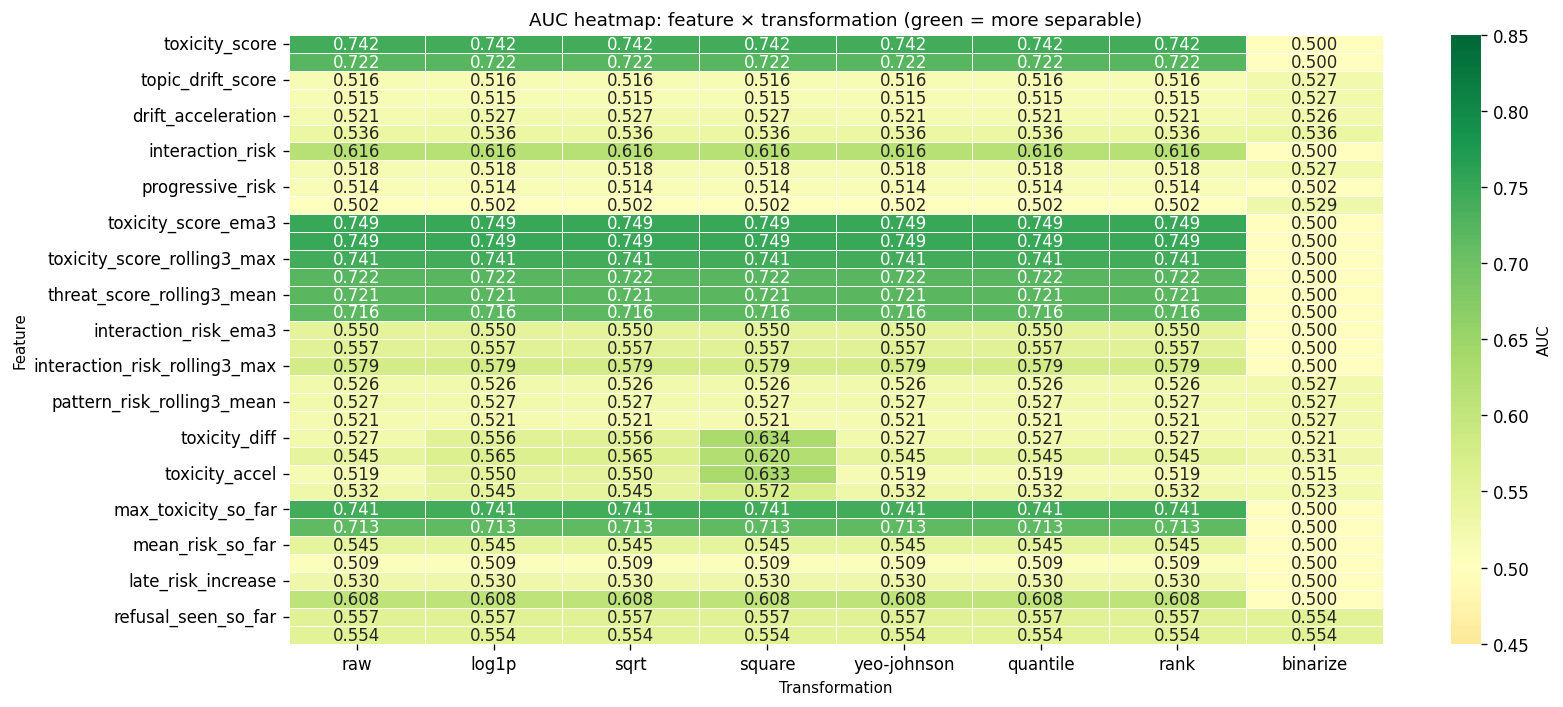

In [60]:
# Heatmap: AUC of every feature × every transform
tnames = list(TRANSFORMS.keys())
auc_matrix = pd.DataFrame(index=feature_cols, columns=['raw'] + tnames, dtype=float)

for col in X.columns:
    raw = X[col].values.astype(float)
    try:
        raw_auc = roc_auc_score(y, raw)
        raw_auc = max(raw_auc, 1-raw_auc)
    except:
        raw_auc = 0.5
    auc_matrix.loc[col, 'raw'] = raw_auc
    for tname, tfn in TRANSFORMS.items():
        try:
            t_arr = tfn(raw)
            if not np.all(np.isfinite(t_arr)):
                auc_matrix.loc[col, tname] = np.nan
                continue
            auc = roc_auc_score(y, t_arr)
            auc_matrix.loc[col, tname] = max(auc, 1-auc)
        except:
            auc_matrix.loc[col, tname] = np.nan

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    auc_matrix.astype(float), annot=True, fmt='.3f',
    cmap='RdYlGn', center=0.5, vmin=0.45, vmax=0.85,
    linewidths=0.4, ax=ax, cbar_kws={'label':'AUC'}
)
ax.set_title('AUC heatmap: feature × transformation (green = more separable)')
ax.set_xlabel('Transformation'); ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/transform_auc_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Best-Transform Separability — KDE Grid

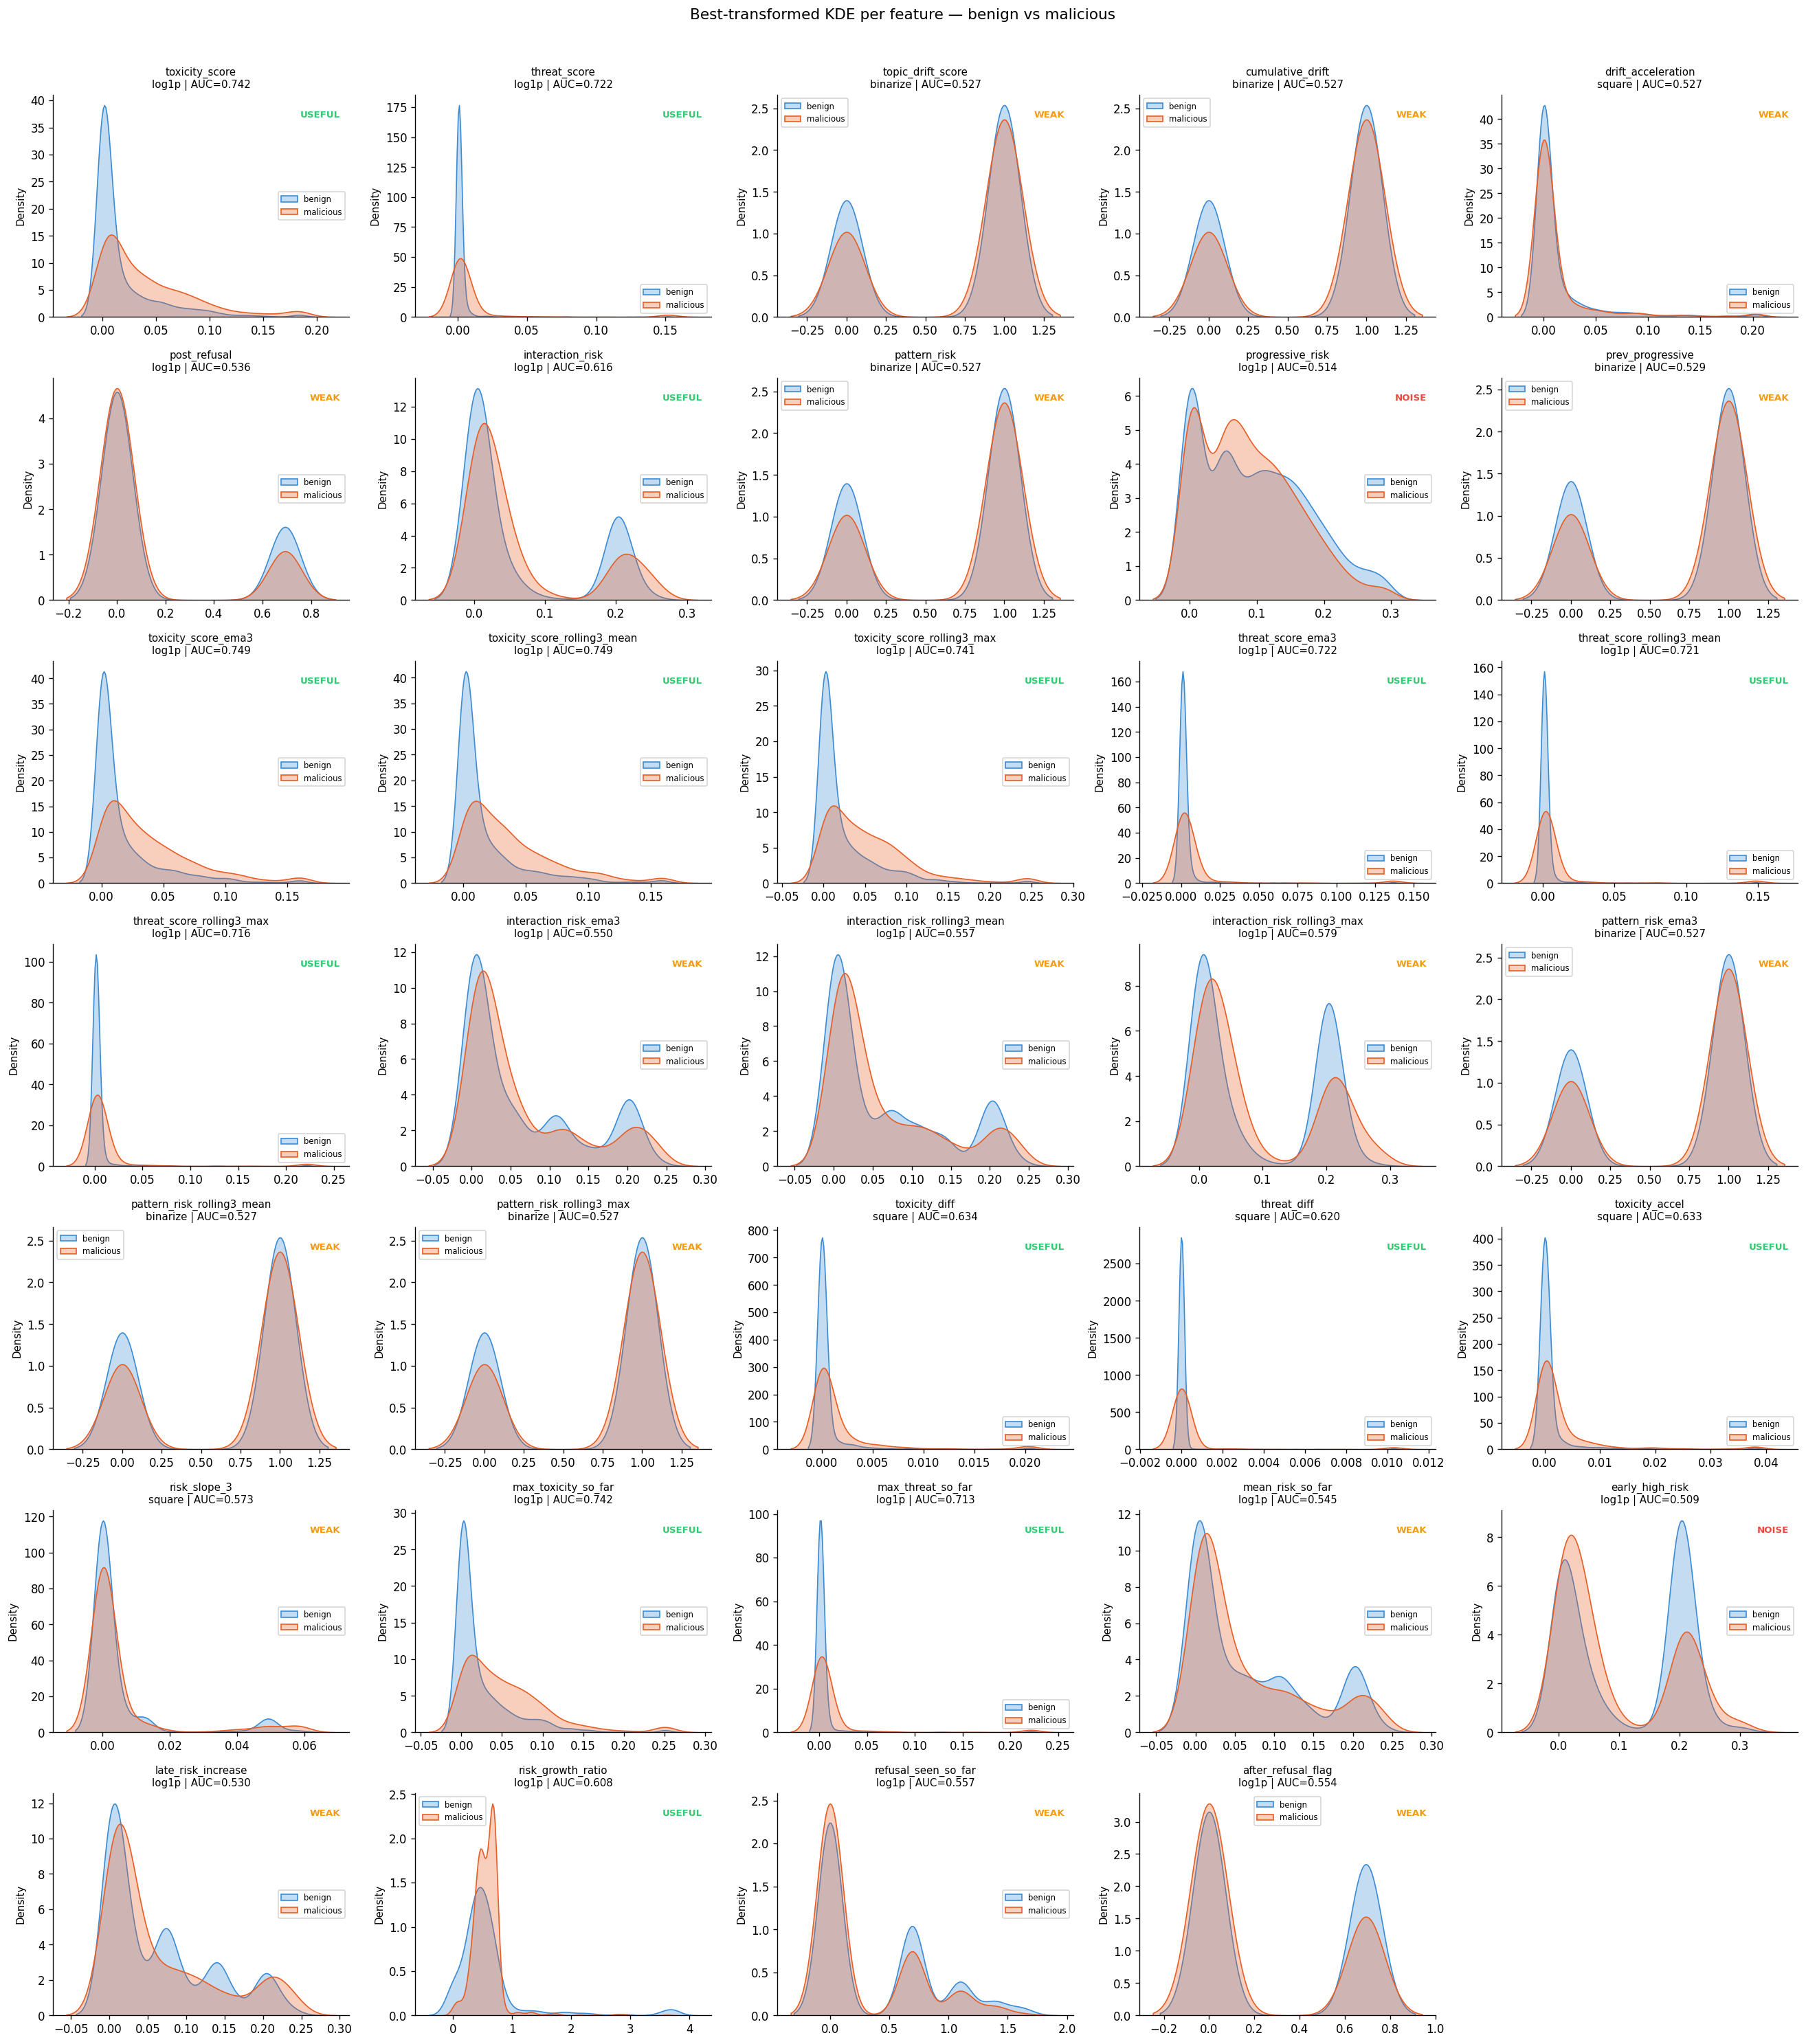

In [62]:
# Apply the best transform to each feature, show final KDE side-by-side
n = len(X.columns)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows*3.5))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    ax = axes[i]
    raw = X[col].values.astype(float)
    info = insight_report[col]
    best_t = info['best_transform']
    t_arr = clip_outliers(TRANSFORMS[best_t](raw))

    try:
        sns.kdeplot(t_arr[y==0], ax=ax, color='#3B8BD4', fill=True, alpha=0.3, label='benign')
        sns.kdeplot(t_arr[y==1], ax=ax, color='#E85D24', fill=True, alpha=0.3, label='malicious')
    except:
        ax.text(0.5,0.5,'degenerate', ha='center', va='center', transform=ax.transAxes)

    verdict_color = {'USEFUL':'#2ecc71','WEAK':'#f39c12','NOISE':'#e74c3c'}[info['verdict']]
    ax.set_title(f'{col}\n{best_t} | AUC={info["best_auc"]:.3f}', fontsize=9)
    ax.text(0.97, 0.93, info['verdict'], ha='right', va='top',
            transform=ax.transAxes, fontsize=8, fontweight='bold', color=verdict_color)
    ax.legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Best-transformed KDE per feature — benign vs malicious', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/best_transform_kde_grid.png', bbox_inches='tight')
plt.show()

## 6. Zero-Mass Analysis

High zero-% features may benefit from a two-part model: binarize (is it zero?) + scale the nonzero portion.

Zero-mass analysis (% of turns where feature = 0)

                                zeros_benign_%  zeros_malicious_%  delta_%
feature                                                                   
prev_progressive                          35.9               30.1      5.8
topic_drift_score                         35.5               30.1      5.4
threat_diff                               35.5               30.1      5.4
risk_slope_3                              35.5               30.1      5.4
pattern_risk                              35.5               30.1      5.4
cumulative_drift                          35.5               30.1      5.4
toxicity_diff                             35.5               30.1      5.4
pattern_risk_rolling3_max                 35.5               30.1      5.4
pattern_risk_rolling3_mean                35.5               30.1      5.4
pattern_risk_ema3                         35.5               30.1      5.4
toxicity_accel                            35.5   

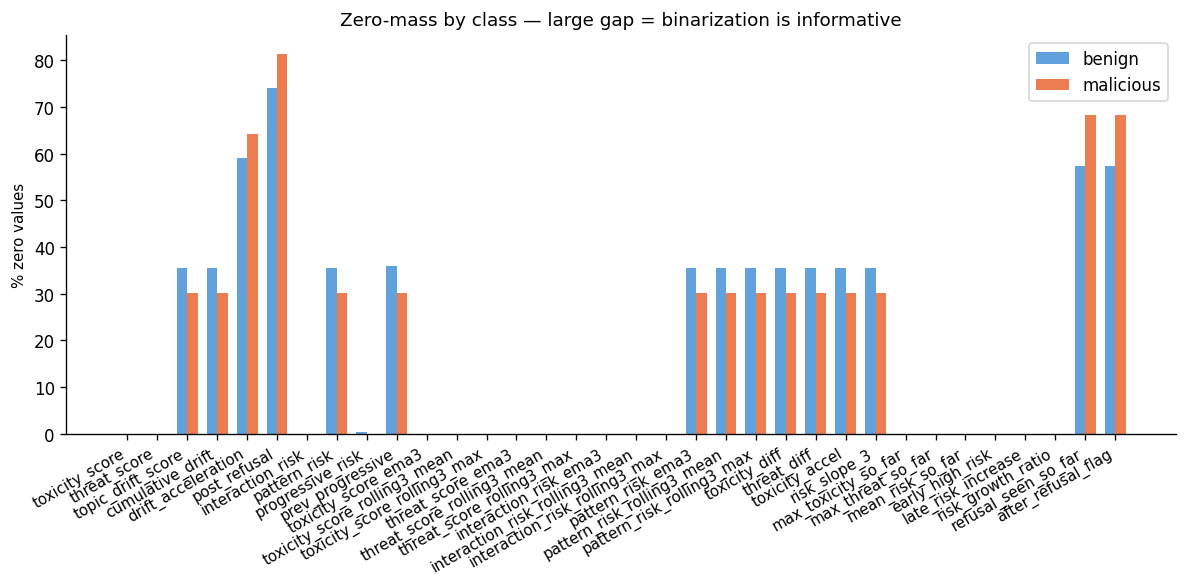

In [64]:
print('Zero-mass analysis (% of turns where feature = 0)\n')
zero_rows = []
for col in X.columns:
    raw = X[col].values
    z_ben = (raw[y==0] == 0).mean() * 100
    z_mal = (raw[y==1] == 0).mean() * 100
    zero_rows.append({'feature': col,
                      'zeros_benign_%': round(z_ben,1),
                      'zeros_malicious_%': round(z_mal,1),
                      'delta_%': round(z_ben - z_mal, 1)})

zero_df = pd.DataFrame(zero_rows).set_index('feature')
print(zero_df.sort_values('delta_%', ascending=False).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(X.columns))
w = 0.35
ax.bar(x_pos - w/2, zero_df['zeros_benign_%'],   width=w, color='#3B8BD4', label='benign', alpha=0.8)
ax.bar(x_pos + w/2, zero_df['zeros_malicious_%'], width=w, color='#E85D24', label='malicious', alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(X.columns, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% zero values')
ax.set_title('Zero-mass by class — large gap = binarization is informative')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/zero_mass_analysis.png', bbox_inches='tight')
plt.show()

## 7. Feature Interaction — 2D Scatter Grid

Are any feature *pairs* more separable together than individually?

Top 5 features by best-transformed AUC:
  toxicity_score_ema3       AUC=0.7490  transform=log1p
  toxicity_score_rolling3_mean AUC=0.7485  transform=log1p
  toxicity_score            AUC=0.7420  transform=log1p
  max_toxicity_so_far       AUC=0.7415  transform=log1p
  toxicity_score_rolling3_max AUC=0.7413  transform=log1p


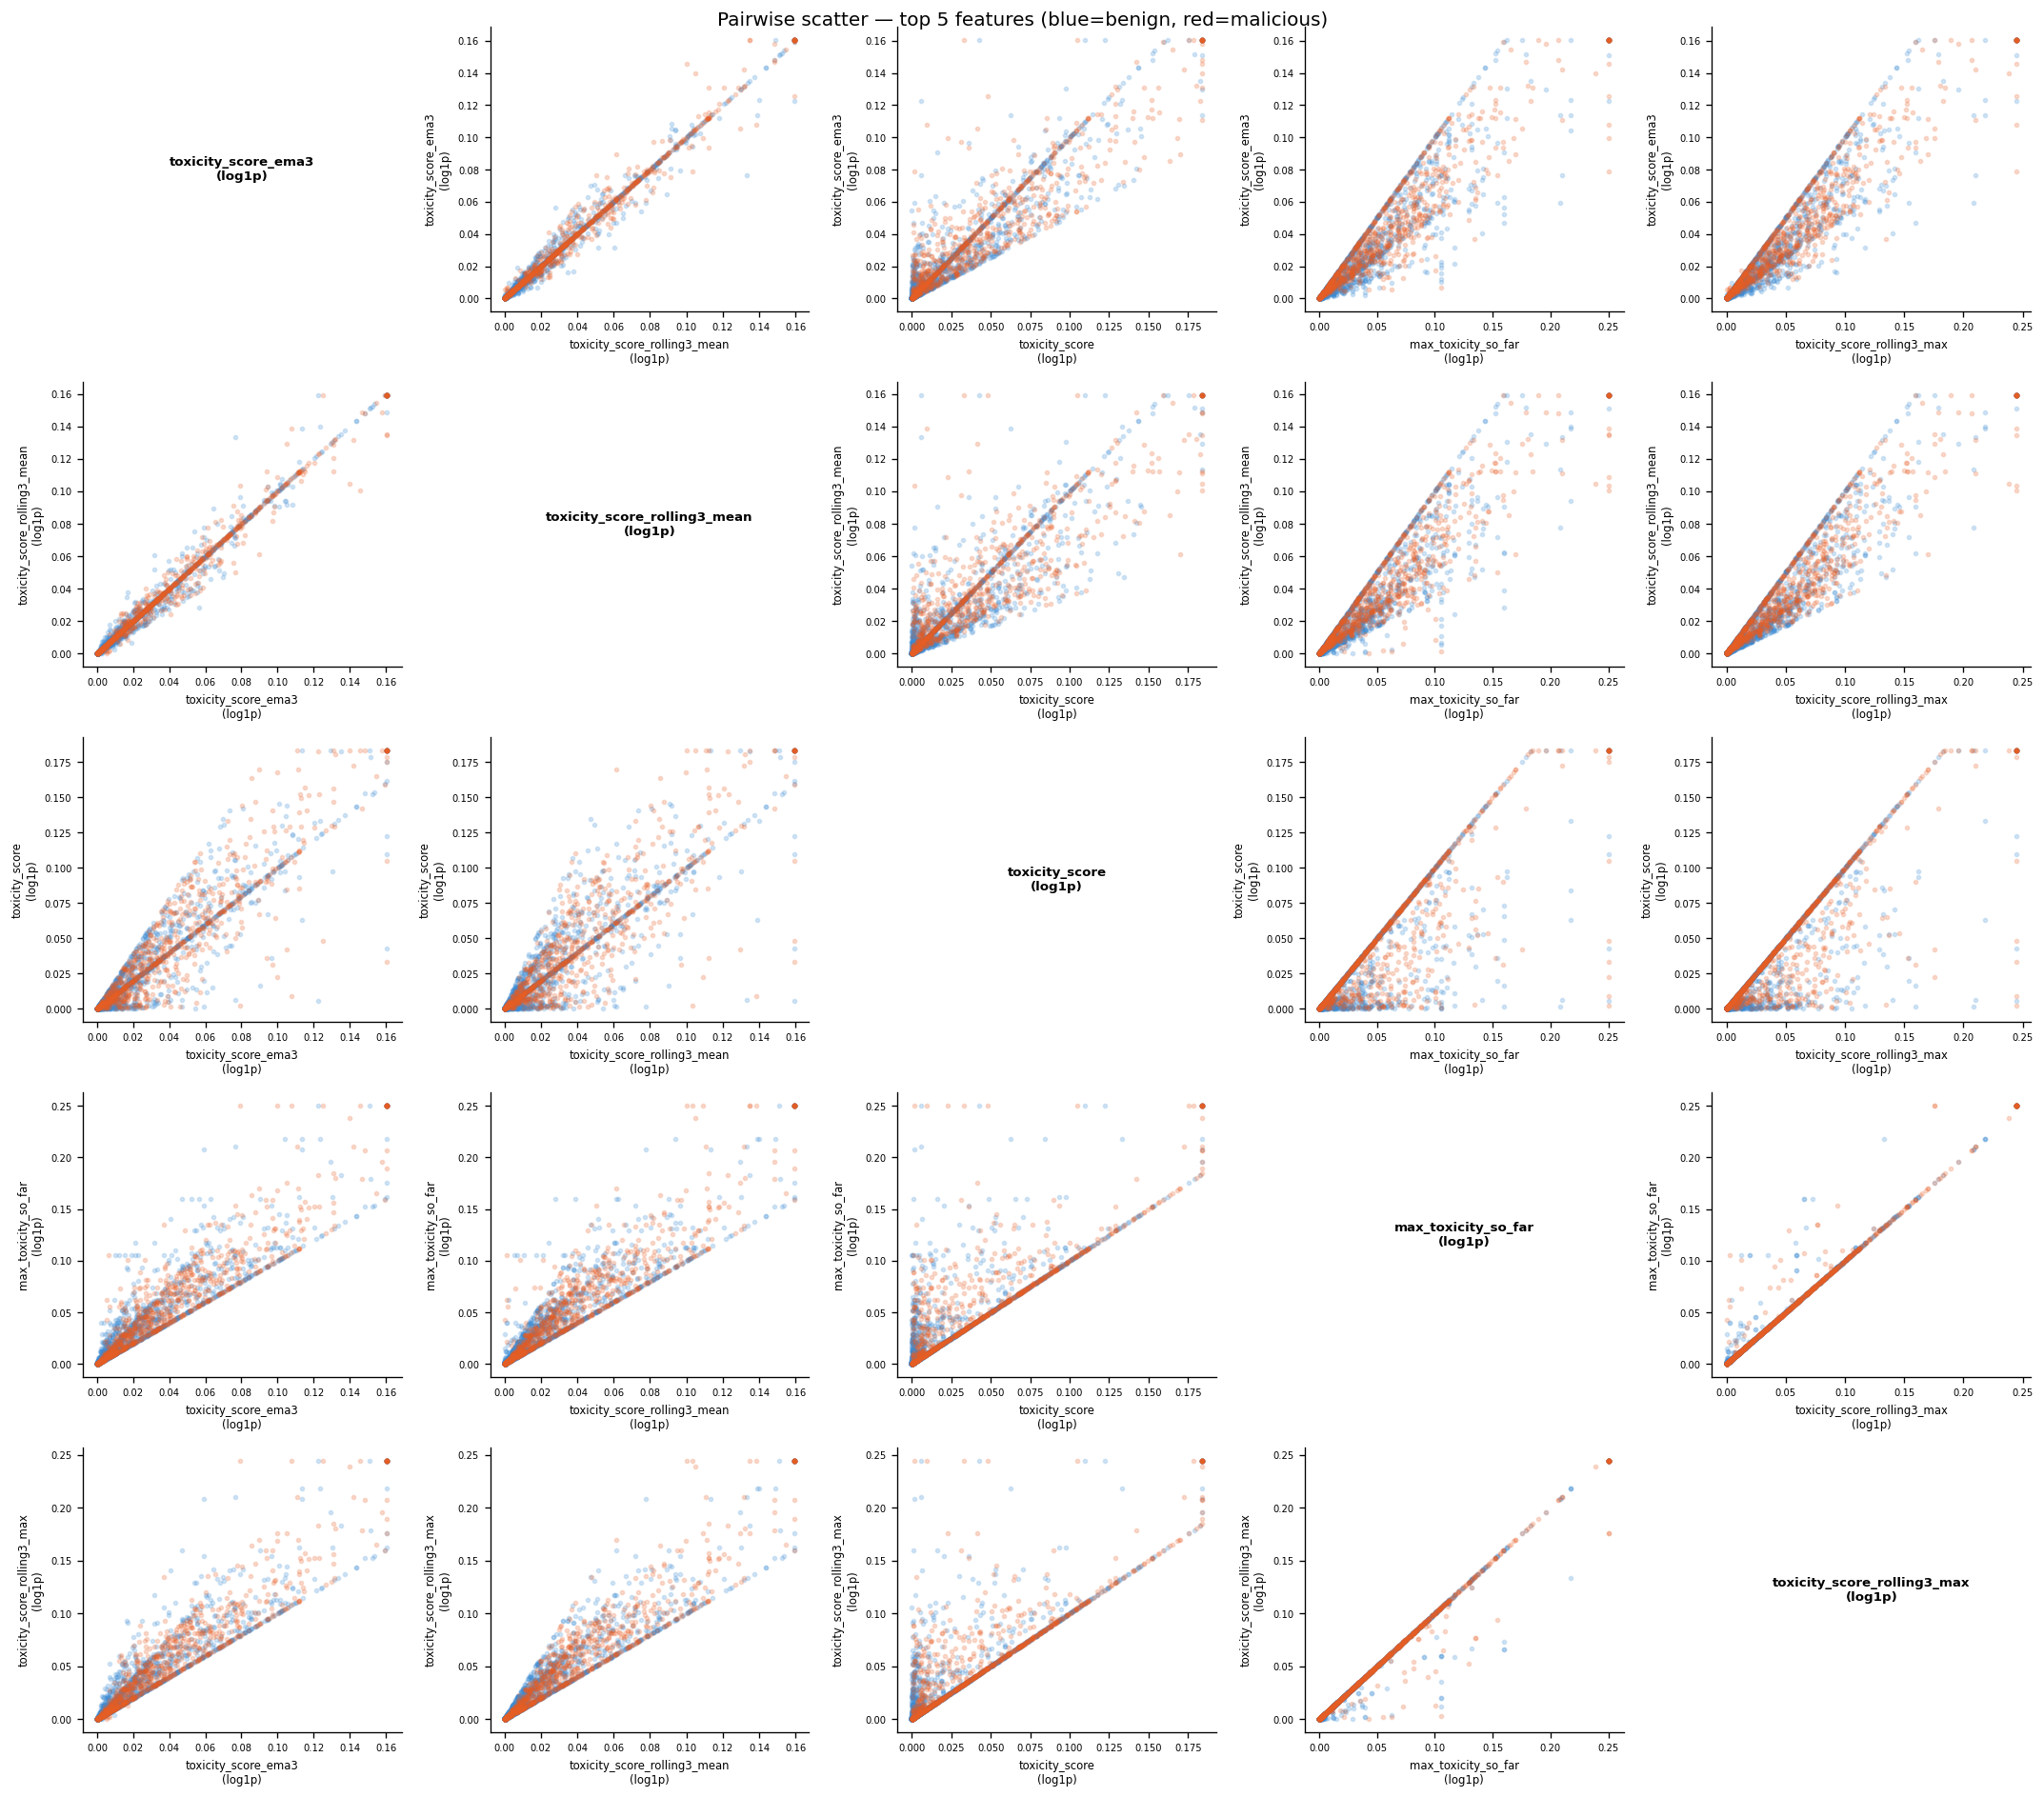

In [65]:
# Pick top-5 features by best AUC for pairwise scatter
top5 = sorted(insight_report.items(), key=lambda kv: kv[1]['best_auc'], reverse=True)[:5]
top5_cols = [k for k,_ in top5]

print('Top 5 features by best-transformed AUC:')
for col, info in top5:
    print(f'  {col:<25} AUC={info["best_auc"]:.4f}  transform={info["best_transform"]}')

# Apply best transforms
X_best = pd.DataFrame()
for col in top5_cols:
    raw  = X[col].values.astype(float)
    best_t = insight_report[col]['best_transform']
    X_best[f'{col}\n({best_t})'] = clip_outliers(TRANSFORMS[best_t](raw))

X_best['label'] = y

fig = plt.figure(figsize=(18, 16))
cols_plot = [c for c in X_best.columns if c != 'label']
n_c = len(cols_plot)
for i in range(n_c):
    for j in range(n_c):
        idx = i * n_c + j + 1
        ax = fig.add_subplot(n_c, n_c, idx)
        if i == j:
            ax.text(0.5, 0.5, cols_plot[i], ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, fontweight='bold')
            ax.set_axis_off()
        else:
            for label_val, c in [(0,'#3B8BD4'),(1,'#E85D24')]:
                mask = y == label_val
                ax.scatter(X_best[cols_plot[j]][mask], X_best[cols_plot[i]][mask],
                           alpha=0.2, s=6, c=c)
            ax.set_xlabel(cols_plot[j], fontsize=7)
            ax.set_ylabel(cols_plot[i], fontsize=7)
            ax.tick_params(labelsize=6)

fig.suptitle('Pairwise scatter — top 5 features (blue=benign, red=malicious)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pairwise_scatter_top5.png', bbox_inches='tight')
plt.show()

## 8. Summary Report

In [66]:
print('='*70)
print('  FEATURE INSIGHT SUMMARY')
print('='*70)
print(f'{"FEATURE":<22} {"RAW_AUC":>8} {"BEST_T":<15} {"BEST_AUC":>9} {"DELTA":>7} {"VERDICT"}')
print('-'*70)
for col, info in sorted(insight_report.items(), key=lambda kv: kv[1]['best_auc'], reverse=True):
    delta_str = f'+{info["auc_delta"]:.4f}' if info['auc_delta'] >= 0 else f'{info["auc_delta"]:.4f}'
    print(f'{col:<22} {info["raw_auc"]:>8.4f} {info["best_transform"]:<15} {info["best_auc"]:>9.4f} {delta_str:>7}  {info["verdict"]}')

print('='*70)
useful  = [k for k,v in insight_report.items() if v['verdict']=='USEFUL']
weak    = [k for k,v in insight_report.items() if v['verdict']=='WEAK']
noise   = [k for k,v in insight_report.items() if v['verdict']=='NOISE']
print(f'\n  USEFUL ({len(useful)}): {useful}')
print(f'  WEAK   ({len(weak)}): {weak}')
print(f'  NOISE  ({len(noise)}): {noise}')
print('='*70)

# Save report
report_path = '../reports/feature_insight_report.json'
os.makedirs(os.path.dirname(report_path), exist_ok=True)
with open(report_path, 'w') as f:
    json.dump({
        'features': insight_report,
        'useful': useful,
        'weak': weak,
        'noise': noise,
    }, f, indent=4)
print(f'\nReport saved → {report_path}')

  FEATURE INSIGHT SUMMARY
FEATURE                 RAW_AUC BEST_T           BEST_AUC   DELTA VERDICT
----------------------------------------------------------------------
toxicity_score_ema3      0.7490 log1p              0.7490 +0.0000  USEFUL
toxicity_score_rolling3_mean   0.7485 log1p              0.7485 +0.0000  USEFUL
toxicity_score           0.7420 log1p              0.7420 +0.0000  USEFUL
max_toxicity_so_far      0.7415 log1p              0.7415 +0.0000  USEFUL
toxicity_score_rolling3_max   0.7413 log1p              0.7413 +0.0000  USEFUL
threat_score             0.7224 log1p              0.7224 +0.0000  USEFUL
threat_score_ema3        0.7223 log1p              0.7223 +0.0000  USEFUL
threat_score_rolling3_mean   0.7206 log1p              0.7206 +0.0000  USEFUL
threat_score_rolling3_max   0.7158 log1p              0.7158 +0.0000  USEFUL
max_threat_so_far        0.7126 log1p              0.7126 +0.0000  USEFUL
toxicity_diff            0.5268 square             0.6344 +0.1076  USEF